In [1]:
import numpy as np
import pandas as pd
import uproot
from xgboost import XGBRegressor

# --- 1. 配置参数 ---
BASE_PATH = "/data/home/zzh/data/Dataset_Filted/CosmicRay"
FILES = {
    "proton": "QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root",
    "he":     "QF_He_addweight_rho_2.5e13_5.0e17_V3.root",
    "cno":    "QF_CNO_addweight_rho_2.5e13_5.0e17_V3.root",
    "fe":     "QF_Fe_addweight_rho_2.5e13_5.0e17_V3.root",
    "mgalsi": "QF_MgAlSi_addweight_rho_2.5e13_5.0e17_V3.root"
}

CUTS = (
    "rec_Eage > 0 and Redge > 0 and NuW3 > 0 and NpE3 > 250 "
    "and @theta_cut_low < rec_theta < @theta_cut_high"
)

# 阈值变量
r_cut_low, r_cut_high = 300, 450
theta_cut_low, theta_cut_high = np.deg2rad([0, 35])
log10TeV_low=3.7; log10TeV_high=4.3

# --- 2. 能量修正模型 ---
model = XGBRegressor();model._estimator_type = "regressor"
model.load_model("/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json")
import json
        
# 加载线性参数
with open("/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json", 'r') as f:
    lp = json.load(f)
intercept  = lp["intercept"]
coef_NuW3  = lp["coef"][0]
coef_theta = lp["coef"][1]

# --- 3. 核心处理函数 ---
def process_cosmic_ray(name, filename):
    with uproot.open(f"{BASE_PATH}/{filename}") as f:
        # 读取数据
        branches = ["E", "theta", "phi", "corex", "corey", "rec_x", "rec_y", 
                    "rec_theta", "rec_phi", "rec_Eage", "Redge","NpE1","NpE2", "NpE3", "NuM1", "NuW3", "weightGaisser", "weightHorandol"]
        df = f["Rec"].arrays(branches, library="pd")
        
        print(f"Processing {name}: Entries={len(df)}, Weights={df['weightGaisser'].sum():.2e}")

        # 1. 基础物理筛选
        df = df.query(CUTS).copy()
        
        # 2. 计算特征量
        df["R_ue"] = np.log10((1e-4 + df["NuM1"]) / (df["NpE3"]))
        df["r"] = np.hypot(df['rec_x'], df['rec_y']) # 比 sqrt(x^2+y^2) 更快
        
        # 3. 半径进一步筛选
        df = df[(df["r"] > r_cut_low) & (df["r"] < r_cut_high)]
        df['NuW3'] = np.log10(df['NuW3'])
        # 4. XGBoost 能量修正
        features = df[["NuW3", "rec_theta"]].values
        df["recE"] = model.predict(features) + intercept + coef_NuW3 * df['NuW3'] + coef_theta * df['rec_theta']
        
        print(f"     Finished {name}: Remaining Entries={len(df)}")
        return df[(df['recE']>log10TeV_low) & (df['recE']<log10TeV_high)]

# --- 4. 批量执行 ---
dfs = {name: process_cosmic_ray(name, path) for name, path in FILES.items()}
# 如果你需要解包到独立变量（虽然推荐直接用字典 dfs['proton']）
proton_df, he_df, cno_df, fe_df, mgalsi_df = dfs.values()
df_all_components = pd.concat(dfs.values(), ignore_index=True)
df_all_components['Eage'] = df_all_components['rec_Eage'] 


Processing proton: Entries=14217778, Weights=1.90e+02
     Finished proton: Remaining Entries=1698410
Processing he: Entries=14210418, Weights=2.03e+02
     Finished he: Remaining Entries=1166415
Processing cno: Entries=14218958, Weights=7.65e+01
     Finished cno: Remaining Entries=891738
Processing fe: Entries=14217887, Weights=7.40e+01
     Finished fe: Remaining Entries=736239
Processing mgalsi: Entries=14220016, Weights=3.57e+01
     Finished mgalsi: Remaining Entries=813815


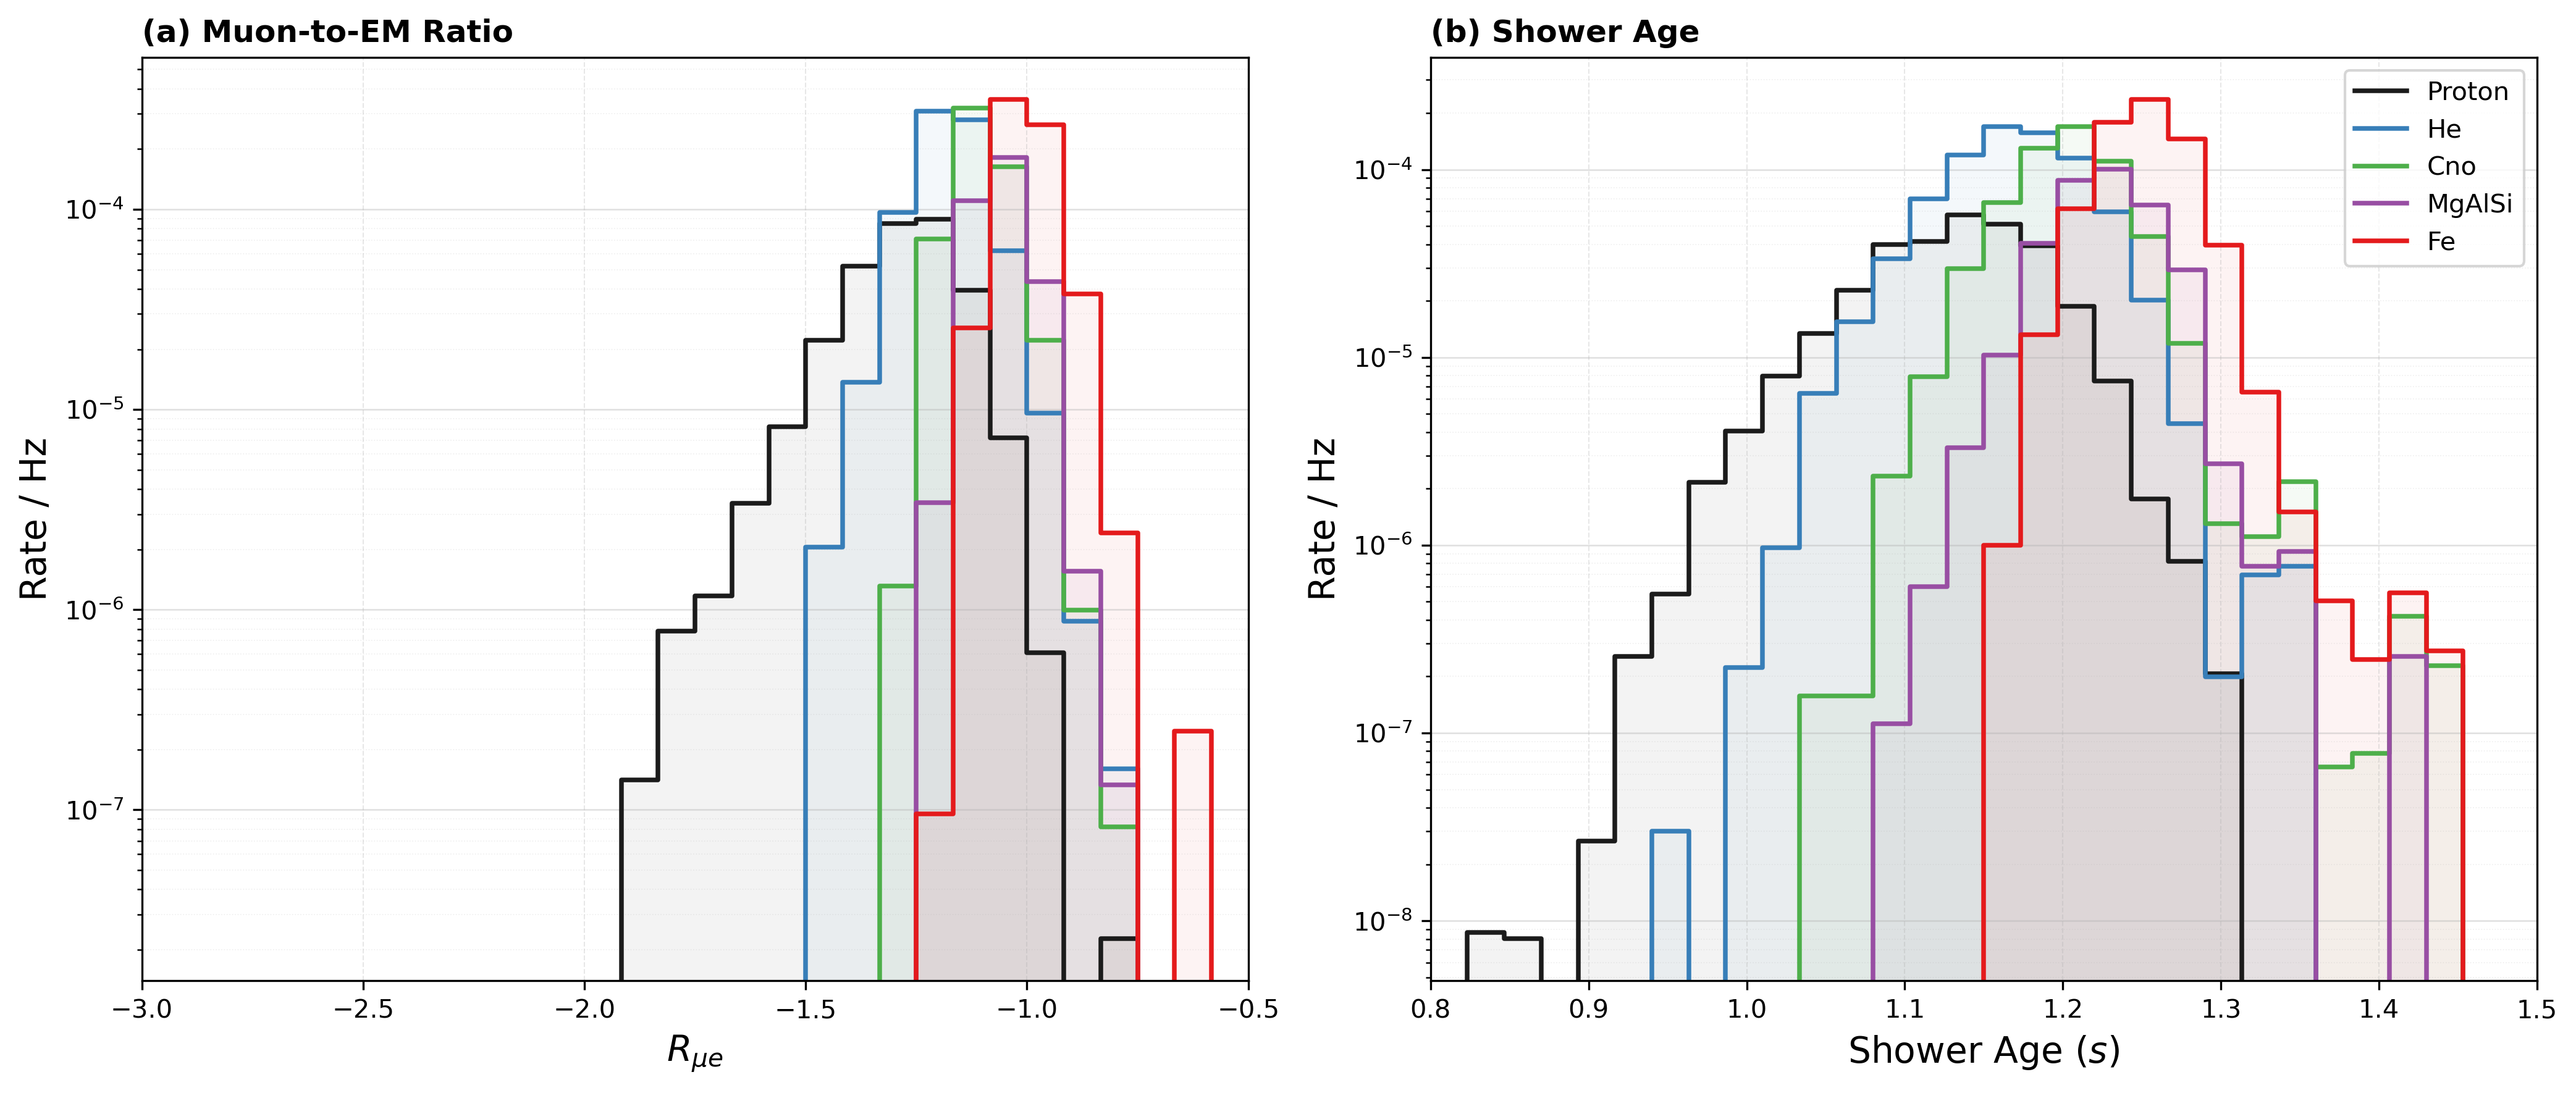

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import LogLocator, NullFormatter

def plot_composition_dual_panels(dfs, bins=30, figsize=(14, 6)):
    """
    绘制 R_ue 和 rec_Eage 的成分对比子图。
    要求：正式发表格式、加权统计、Y轴对数坐标及加密网格。
    """

    # 创建一个包含两个子图的图形对象，设置图形大小和分辨率
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, dpi=300)

    # 成分颜色映射
    # 方案 A：经典学术对比色
    color_map = {
    "proton": "#1B1B1B", # 黑色 (作为基准成分)
    "he":     "#377eb8", # 蓝色
    "cno":    "#4daf4a", # 绿色
    "mgalsi": "#984ea3", # 紫色
    "fe":     "#e41a1c"  # 红色
    }
    species_order = ["proton", "he", "cno", "mgalsi", "fe"]

    # 参数配置：(变量名, x范围, x轴标签)
    configs = [
        ("R_ue", (-3, -0.5), r"$R_{\mu e}$", ax1),
        ("rec_Eage", (0.8, 1.5), r"Shower Age ($s$)", ax2)
    ]

    for p_name, x_range, x_label, ax in configs:
        for name in species_order:
            if name not in dfs or p_name not in dfs[name].columns:
                continue
            
            df = dfs[name]
            # df=df[df['rec_Eage']<1.17]
            # 数据转换与权重提取
            vals = pd.to_numeric(df[p_name], errors='coerce').values
            weights = pd.to_numeric(df.get("weightGaisser", np.ones_like(vals)), errors='coerce').values
            
            # 过滤无效值
            mask = np.isfinite(vals) & np.isfinite(weights) & (vals >= x_range[0]) & (vals <= x_range[1])
            if not np.any(mask): continue

            # 计算加权直方图 (使用密度或计数，根据需求调整)
            counts, bin_edges = np.histogram(
                vals[mask], bins=bins, range=x_range, weights=weights[mask], 
            )
            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            
            # 绘图
            label_text = name.capitalize() if name != "mgalsi" else "MgAlSi"
            ax.step(bin_edges[:-1], counts, where='post', label=label_text, 
                    color=color_map[name], linewidth=1.8)
            ax.fill_between(bin_edges[:-1], counts, step='post', color=color_map[name], alpha=0.05)

        # 2. 坐标轴与密集网格美化
        ax.set_xlabel(x_label, fontsize=14)
        ax.set_ylabel("Rate / Hz", fontsize=14)
        ax.set_xlim(x_range)
        ax.set_yscale('log')
        # ax.set_ylim(1e-6, ) # 根据数据密度调整

        # 设置 Y 轴主次加密网格
        ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
        ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
        ax.yaxis.set_minor_formatter(NullFormatter())

        # 线条样式：主网格实线，次网格极细点线
        ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.6, alpha=0.4)
        ax.grid(True, which='minor', axis='y', linestyle=':', linewidth=0.4, alpha=0.2)
        ax.grid(True, which='major', axis='x', linestyle='--', linewidth=0.5, alpha=0.3)

    # 3. 标注与保存
    ax1.set_title(r"(a) Muon-to-EM Ratio", loc='left', fontweight='bold')
    ax2.set_title(r"(b) Shower Age", loc='left', fontweight='bold')
    ax2.legend(frameon=True, fontsize=10, loc='upper right', ncol=1,  shadow=False).get_frame().set_edgecolor('0.8')

    plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e12_Composition_Rue_Age_Comparison.pdf", bbox_inches='tight')
    plt.show()

# 调用
plot_composition_dual_panels(dfs)


--- PROTON ---
Fit Range: (-1.7, -1.3)
Slope: 11.3321
Extrapolated Sum (Range (-3.0, -2)): 4.3557e-08 Hz
--- HE ---
Fit Range: (-1.45, -1.25)
Slope: 25.4193
Extrapolated Sum (Range (-3.0, -2)): 6.2025e-13 Hz

====== FINAL RESULT ======
Proton / Helium Ratio (in (-3.0, -2)): 70225.0562


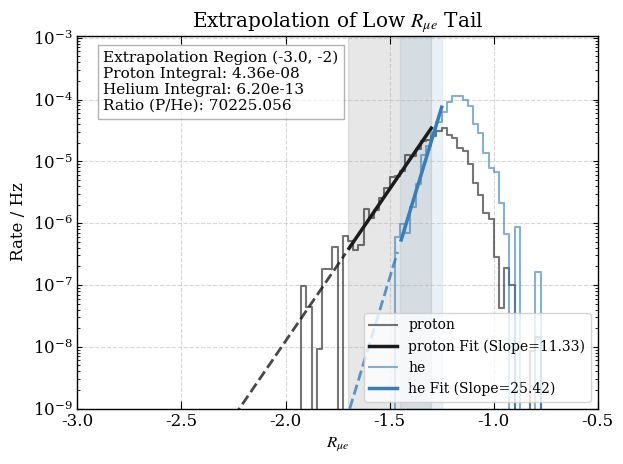

In [222]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def analyze_and_plot_extrapolation(dfs, bins=100):
    # --- 1. 基础设置与绘图准备 (保持你的风格) ---

    
    fig, ax = plt.subplots()
    
    # 定义参数
    var_name = "R_ue"
    plot_range = (-3, -0.5)
    target_range = (-3.0, -2) # 我们要积分的目标区域
    
    # 拟合配置: (成分名, 拟合区间, 颜色)
    fit_configs = {
        "proton": {"fit_range": (-1.7, -1.3), "color": "#1B1B1B"},
        "he":     {"fit_range": (-1.45, -1.25), "color": "#377eb8"}
    }
    
    results = {}

    # --- 2. 循环处理 Proton 和 He ---
    for name, config in fit_configs.items():
        if name not in dfs: continue
        
        df = dfs[name]
        # df=df[df['rec_Eage']<1.15]
        vals = pd.to_numeric(df[var_name], errors='coerce').values
        weights = pd.to_numeric(df.get("weightGaisser", np.ones_like(vals)), errors='coerce').values
        
        # 2.1 获取直方图数据 (与画图保持一致)
        # 注意：这里 range 必须和画图时完全一致，保证 bin_width 相同
        counts, bin_edges = np.histogram(vals, bins=bins, range=plot_range, weights=weights)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        bin_width = bin_edges[1] - bin_edges[0]
        
        # 2.2 筛选拟合区间的数据
        fit_min, fit_max = config['fit_range']
        # 筛选条件：在拟合区间内 且 计数大于0 (log不接受0)
        mask = (bin_centers >= fit_min) & (bin_centers <= fit_max) & (counts > 0)
        
        x_fit = bin_centers[mask]
        y_fit = counts[mask] # 这里是 Rate
        
        if len(x_fit) < 2:
            print(f"Warning: Not enough points to fit {name}")
            continue

        # 2.3 线性拟合: ln(y) = slope * x + intercept
        # 对应物理模型: y = exp(intercept) * exp(slope * x)
        slope, intercept = np.polyfit(x_fit, np.log(y_fit), 1)
        
        # 定义拟合函数 (用于绘图和计算)
        def fitted_func(x):
            return np.exp(slope * x + intercept)
        
        # 2.4 积分计算目标区间 (-3, -2) 的总 Rate
        # 积分公式: Integral(e^(mx+c)) = (1/m) * [e^(mx+c)] | upper_lower
        # 重要：因为直方图是离散的 bin，拟合函数得到的是 "每个bin的计数"。
        # 该区间内的总数 ≈ 积分 / bin_width
        
        t_min, t_max = target_range
        integral_val = (fitted_func(t_max) - fitted_func(t_min)) / slope
        total_rate_extrapolated = integral_val / bin_width
        
        results[name] = {
            "total_rate": total_rate_extrapolated,
            "slope": slope,
            "intercept": intercept,
            "func": fitted_func
        }
        
        print(f"--- {name.upper()} ---")
        print(f"Fit Range: {config['fit_range']}")
        print(f"Slope: {slope:.4f}")
        print(f"Extrapolated Sum (Range {target_range}): {total_rate_extrapolated:.4e} Hz")

        # --- 3. 绘图部分 ---
        # 3.1 画原始阶梯图
        ax.step(bin_centers, counts, where='mid', label=f"{name}", 
                color=config['color'], alpha=0.6, linewidth=1.5)
        
        # 3.2 画拟合线 (延伸到左侧边界)
        x_plot = np.linspace(plot_range[0], fit_max, 100)
        y_plot = fitted_func(x_plot)
        
        # 实线表示拟合区间，虚线表示外推区间
        # 画外推段
        ax.plot(x_plot[x_plot < fit_min], y_plot[x_plot < fit_min], 
                linestyle="--", color=config['color'], alpha=0.8, linewidth=2)
        # 画拟合段 (加粗显示拟合依据)
        ax.plot(x_plot[(x_plot >= fit_min)], y_plot[(x_plot >= fit_min)], 
                linestyle="-", color=config['color'], linewidth=2.5, 
                label=f"{name} Fit (Slope={slope:.2f})")
        
        # 标记拟合区间区域
        ax.axvspan(fit_min, fit_max, color=config['color'], alpha=0.1)

    # --- 4. 计算并展示最终比值 ---
    if "proton" in results and "he" in results:
        ratio = results["proton"]["total_rate"] / results["he"]["total_rate"]
        print(f"\n====== FINAL RESULT ======")
        print(f"Proton / Helium Ratio (in {target_range}): {ratio:.4f}")
        
        # 在图上标注结果
        ax.text(0.05, 0.8, 
                f"Extrapolation Region {target_range}\n" + 
                f"Proton Integral: {results['proton']['total_rate']:.2e}\n" +
                f"Helium Integral: {results['he']['total_rate']:.2e}\n" +
                f"Ratio (P/He): {ratio:.3f}", 
                transform=ax.transAxes, fontsize=11,
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray'))

    # 美化设置
    ax.set_yscale('log')
    ax.set_xlabel(r"$R_{\mu e}$")
    ax.set_ylabel("Rate / Hz")
    ax.set_title(r"Extrapolation of Low $R_{\mu e}$ Tail")
    ax.set_xlim(plot_range)
    # 自动调整ylim以显示外推线
    ax.set_ylim(bottom=1e-9) 
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(True, which="major", linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e12_Rue_Extrapolation_Proton_He.pdf", bbox_inches='tight')
    plt.show()

# --- 执行 ---
# 假设 dfs 已经在内存中 (如你代码块所示)
analyze_and_plot_extrapolation(dfs)


In [72]:

def load_allweight_model():
    
    r_low=300
    r_high=450
    theta_low=0
    theta_high=35 / 180.0 * np.pi

    Eage_low=0.8
    Eage_high=2.4
    # R_ue_high=-5.0
    log10TeV_low=3.7
    log10TeV_high=4.3

    def open_file(file_name):
        with uproot.open(file_name) as file:
            tree = file["Rec"]
            branches_to_read = ["E", "theta","phi","corex","corey","rec_x","rec_y","rec_theta","rec_phi","rec_Eage","Redge","NpE3","NuM1","NuM2","NuM3","NuW3","weightGaisser","weightHorandol"]
            df = tree.arrays(branches_to_read, library="pd")
            all_weights_gaisser = df['weightGaisser'].sum()
            all_weights_horandel = df['weightHorandol'].sum()
            print(file_name)
            print("     Entries:", tree.num_entries)
            print("     Total weights Gaisser:", all_weights_gaisser)
            print("     Total weights Horandel:", all_weights_horandel)

            rec_Eage=df['rec_Eage'].values
            rec_theta=df['rec_theta'].values
            NuW3=df['NuW3'].values
            rec_x=df['rec_x'].values
            rec_y=df['rec_y'].values
            r=np.sqrt(rec_x**2+rec_y**2)
            df['rec_r']=r
            cuts_indices = (rec_Eage > Eage_low) & (rec_Eage < Eage_high) & \
                            (r > r_low) & (r < r_high) & \
                            (rec_theta > theta_low) & (rec_theta < theta_high) & \
                            (NuW3 > 0)
            df_cut = df[cuts_indices].copy() 
            
            df_cut["R_ue"]=np.log10((1e-4+df_cut["NuM2"])/(df_cut["NpE3"]+1))
            print(f"     Entries after cut: {df_cut.shape[0]}")
            del df
            return df_cut
        

    def energy_correction(df: pd.DataFrame):
        import json
        
        # 加载线性参数
        with open("/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json", 'r') as f:
            lp = json.load(f)
        intercept  = lp["intercept"]
        coef_NuW3  = lp["coef"][0]
        coef_theta = lp["coef"][1]

        theta      = df["rec_theta"].values
        log10_NuW3 = np.log10(df["NuW3"].values)
        
        feature_data = np.column_stack((log10_NuW3, theta))
        
        # 线性基线 + XGBoost残差
        linear_pred  = intercept + coef_NuW3 * log10_NuW3 + coef_theta * theta
        xgb_residual = model.predict(feature_data)
        corrected_energy = linear_pred + xgb_residual  # log10(E/1e8)
        
        df["recE"] = corrected_energy
        
        df_new = df[(df["recE"] > log10TeV_low) & (df["recE"] < log10TeV_high)]
        print(f" cut weight Gaisser sum: {df_new['weightGaisser'].sum()}")
        print(f" cut weight Horandel sum: {df_new['weightHorandol'].sum()}")
        del df
        return df_new


    from xgboost import XGBRegressor
    model = XGBRegressor()
    model._estimator_type = "regressor"
    model.load_model("/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json")

    # proton_df_QF = open_file("/data/home/zzh/data/Dataset_Filted/CosmicRay/QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root")
    proton_df_QF = open_file("/data/home/zzh/data/Dataset_Filted/CosmicRay/Proton_1.0e14_1.0e17_RecTNtuple_Weights.root")
    proton_df_QF = energy_correction(proton_df_QF)
    QF_allweights_gaisser=proton_df_QF['weightGaisser'].sum()
    QF_allweights_horandel=proton_df_QF['weightHorandol'].sum()

   

    return QF_allweights_gaisser,QF_allweights_horandel, proton_df_QF

QF_allweights_gaisser, QF_allweights_horandel, proton_df_QF = load_allweight_model()

print(len(proton_df_QF))



/data/home/zzh/data/Dataset_Filted/CosmicRay/Proton_1.0e14_1.0e17_RecTNtuple_Weights.root
     Entries: 2219899
     Total weights Gaisser: 18.59205733311552
     Total weights Horandel: 14.958015698842956
     Entries after cut: 1043724
 cut weight Gaisser sum: 0.0006691349593753829
 cut weight Horandel sum: 0.00023496912476580833
7877


In [3]:
import pandas as pd
import numpy as np
import re
import uproot
from scipy.integrate import quad


r_low=300
r_high=450
theta_low=0
theta_high=35 / 180.0 * np.pi

Eage_low=0.8
Eage_high=2.4
# R_ue_high=-5.0
log10TeV_low=3.7
log10TeV_high=4.3


def load_allweight_model():
    
    r_low=300
    r_high=450
    theta_low=0
    theta_high=35 / 180.0 * np.pi

    Eage_low=0.8
    Eage_high=2.4
    # R_ue_high=-5.0
    log10TeV_low=3.7
    log10TeV_high=4.3

    def open_file(file_name):
        with uproot.open(file_name) as file:
            tree = file["Rec"]
            branches_to_read = ["E", "theta","phi","corex","corey","rec_x","rec_y","rec_theta","rec_phi","rec_Eage","Redge","NpE3","NuM1","NuM2","NuM3","NuW3",
                                "weightGaisser","weightHorandol","weightGSF"]
            df = tree.arrays(branches_to_read, library="pd")
            all_weights_gaisser = df['weightGaisser'].sum()
            all_weights_horandel = df['weightHorandol'].sum()
            all_weights_gsf = df['weightGSF'].sum()
            print(file_name)
            print("     Entries:", tree.num_entries)
            print("     Total weights Gaisser:", all_weights_gaisser)
            print("     Total weights Horandel:", all_weights_horandel)
            print("     Total weights GSF:", all_weights_gsf)

            rec_Eage=df['rec_Eage'].values
            rec_theta=df['rec_theta'].values
            NuW3=df['NuW3'].values
            rec_x=df['rec_x'].values
            rec_y=df['rec_y'].values
            r=np.sqrt(rec_x**2+rec_y**2)
            df['rec_r']=r
            cuts_indices = (rec_Eage > Eage_low) & (rec_Eage < Eage_high) & \
                            (r > r_low) & (r < r_high) & \
                            (rec_theta > theta_low) & (rec_theta < theta_high) & \
                            (NuW3 > 0)
            df_cut = df[cuts_indices].copy() 
            
            df_cut["R_ue"]=np.log10((1e-4+df_cut["NuM1"])/(df_cut["NpE3"]+1))
            print(f"     Entries after cut: {df_cut.shape[0]}")
            
            # plt.hist(np.log10(df_cut['E']), bins=50, range=(4, 8.5), weights=df_cut['weightGaisser'], histtype='step', label='Gaisser', color='blue')
            # plt.hist(np.log10(df_cut['E']), bins=50, range=(4, 8.5), weights=df_cut['weightHorandol'], histtype='step', label='Horandel', color='red')
            # plt.hist(np.log10(df_cut['E']), bins=50, range=(4, 8.5), weights=df_cut['weightGSF'], histtype='step', label='GSF', color='green')
            # plt.xlabel('log10(Energy/1e8 GeV)')
            # plt.ylabel('Weighted Counts')
            # plt.title('Energy Distribution after Cuts')
            # plt.legend()
            # plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures
            # plt.show()
            del df
            return df_cut
        

    def energy_correction(df: pd.DataFrame):
        import json
        
        # 加载线性参数
        with open("/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json", 'r') as f:
            lp = json.load(f)
        intercept  = lp["intercept"]
        coef_NuW3  = lp["coef"][0]
        coef_theta = lp["coef"][1]

        theta      = df["rec_theta"].values
        log10_NuW3 = np.log10(df["NuW3"].values)
        
        feature_data = np.column_stack((log10_NuW3, theta))
        
        # 线性基线 + XGBoost残差
        linear_pred  = intercept + coef_NuW3 * log10_NuW3 + coef_theta * theta
        xgb_residual = model.predict(feature_data)
        corrected_energy = linear_pred + xgb_residual  # log10(E/1e8)
        
        df["recE"] = corrected_energy
        
        df_new = df[(df["recE"] > log10TeV_low) & (df["recE"] < log10TeV_high)]
        print(f" cut weight Gaisser sum: {df_new['weightGaisser'].sum()}")
        print(f" cut weight Horandel sum: {df_new['weightHorandol'].sum()}")
        print(f" cut weight GSF sum: {df_new['weightGSF'].sum()}")
        del df
        return df_new


    from xgboost import XGBRegressor
    model = XGBRegressor()
    model._estimator_type = "regressor"
    model.load_model("/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json")

    proton_df_QF = open_file("/data/home/zzh/data/Dataset_Filted/CosmicRay/QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root")
    # proton_df_QF = open_file("/data/home/zzh/data/Dataset_Filted/CosmicRay/Proton_1.0e14_1.0e17_RecTNtuple_Weights.root")
    proton_df_QF = energy_correction(proton_df_QF)
    QF_allweights_gaisser=proton_df_QF['weightGaisser'].sum()
    QF_allweights_horandel=proton_df_QF['weightHorandol'].sum()
    

   

    return QF_allweights_gaisser,QF_allweights_horandel, proton_df_QF

QF_allweights_gaisser, QF_allweights_horandel, proton_df_QF = load_allweight_model()


def parse_sim_log(txt_filepath):
    """
    解析 .out.txt，提取每个能段实际处理的事例总数 N_bin
    返回格式: {(E_min_eV, E_max_eV): N_total}
    """
    bins_count = {}
    current_bin = None
    
    with open(txt_filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # 捕获能段: Processing: [2.5e15_4.0e15]
            m_bin = re.search(r'Processing:\s*\[([0-9\.e]+)_([0-9\.e]+)\]', line)
            if m_bin:
                current_bin = (float(m_bin.group(1)), float(m_bin.group(2)))
                bins_count[current_bin] = 0
                continue
            
            # 捕获处理数: RUN: run001 | Found: 1000 | Processing: 1000
            m_proc = re.search(r'Processing:\s*(\d+)', line)
            if m_proc and current_bin:
                bins_count[current_bin] += int(m_proc.group(1))
    
    
    # plt.bar([f"{e_min/1e9:.1e}-{e_max/1e9:.1e} GeV" for (e_min, e_max) in bins_count.keys()], bins_count.values())
    # plt.xlabel("Energy Bin (GeV)")
    # plt.ylabel("Total Processed Events")
    # plt.title("Total Processed Events per Energy Bin from Log File")
    # plt.xticks(rotation=45)
    # plt.tight_layout()
    # plt.show()
    return bins_count


def calculate_weights(df, log_filepath, root_filepath, dlogE=0.01):
    """
    完全参照 C++ 逻辑：
    在 (FineEnergyBin, ZenithBin) 的二维网格中，分别计算 EventTrue 和 EventSim 并相除
    """
    def gaisser_proton_flux_with_knee(E_TeV, z=0):
        """
        LHAASO 官方 Gaisser H3a 模型 (翻译自官方 C++)
        z (元素索引): 0=P, 1=He, 2=CNO, 3=MgAlSi, 4=Fe
        """
        energy_GeV = E_TeV * 1000.0
        
        # 参数矩阵 aij[3][5]
        aij = [
            [7860, 3550, 2200, 1430, 2120],
            [20,   20,   13.4, 13.4, 13.4],
            [1.7,  1.7,  1.14, 1.14, 1.14]
        ]
        # 积分谱指数矩阵 rij[3][5] (代码中参与计算为 -rij - 1)
        rij = [
            [1.66, 1.58, 1.63, 1.67, 1.63],
            [1.4,  1.4,  1.4,  1.4,  1.4],
            [1.4,  1.4,  1.4,  1.4,  1.4]
        ]
        # 截断刚度 rc (GeV)
        rc = [4e6, 30e6, 2e9] 
        # 电荷数 Z
        Ze = [1, 2, 7, 13, 26]
        
        flux_GeV = 0.0
        for ii in range(3):
            term1 = aij[ii][z]
            term2 = energy_GeV ** (-rij[ii][z] - 1.0)
            term3 = np.exp(-energy_GeV / (Ze[z] * rc[ii]))
            flux_GeV += term1 * term2 * term3
            
        # 将 GeV^-1 转为 TeV^-1 以适配主程序的积分逻辑
        flux_TeV = flux_GeV * 1000.0 
        return flux_TeV
        """
        计算带有膝区截断的保守 Gaisser 质子流强
        """
        # PHI_0 = 0.096
        # GAMMA_1 = 2.7     # 膝区前的能谱指数
        # GAMMA_2 = 3.3     # 膝区后的能谱指数 (你可以根据 LHAASO 内部的推荐值微调，通常在 3.1~3.4 之间)
        # E_C = 4000.0      # 质子膝区位置 (4000 TeV = 4 PeV)
        
        # # return PHI_0 * (E_TeV ** -GAMMA_1)
        
        
        # # --------------------------------------------------------
        # if E_TeV < E_C:
        #     return PHI_0 * (E_TeV ** -GAMMA_1)
        # else:
        #     # 为了保证在 E_C 处连续，需要乘上一个平滑系数 E_C^(GAMMA_2 - GAMMA_1)
        #     smooth_factor = E_C ** (GAMMA_2 - GAMMA_1)
        #     return PHI_0 * smooth_factor * (E_TeV ** -GAMMA_2)
        
        
        # --------------------------------------------------------
        # E_GeV = E_TeV * 1000.0
        # # Gaisser H4a 参数表: a_i 单位是 [m^-2 s^-1 sr^-1 GeV^-1]
        # # 族群 1: 超新星遗迹 (截断在 4 PeV)
        # a1, gamma1, R1 = 7860.0, 2.66, 4.0e6  
        # # 族群 2: 银河系高能源 (截断在 30 PeV)
        # a2, gamma2, R2 = 20.0,   2.40, 30.0e6 
        # # 族群 3: 河外源 (截断在 2 EeV)
        # a3, gamma3, R3 = 1.7,    2.40, 2.0e9  

        # # 累加三个族群的流强
        # flux_GeV = (
        #     a1 * (E_GeV ** -gamma1) * np.exp(-E_GeV / R1) +
        #     a2 * (E_GeV ** -gamma2) * np.exp(-E_GeV / R2) +
        #     a3 * (E_GeV ** -gamma3) * np.exp(-E_GeV / R3)
        # )

        # # 转换回 TeV^-1 (因为主程序计算截面用的是 TeV)
        # flux_TeV = flux_GeV * 1000.0
        # return flux_TeV
    
    sim_bins = parse_sim_log(log_filepath)
    
    with uproot.open(root_filepath) as f:
        h1 = f["h1"] 
        h2 = f["h2"] 
        zen_edges = h1.axis().edges()
        h1_vals = h1.values()
        h2_vals = h2.values()
        
    THETA_MAX_GEN = 35.0   
    R_MIN, R_MAX = 300.0, 450.0
    # R_MIN, R_MAX = 0.0, 280.0
    A_GEN = np.pi * (R_MAX**2 - R_MIN**2)
    T_DAY = 86400.0        
    SIM_INDEX = -2.0       
    
    valid_zen_mask = zen_edges[:-1] < THETA_MAX_GEN
    sum_h2_gen = np.sum(h2_vals[valid_zen_mask])
    # sum_h2_gen_total = np.sum(h2_vals)
    prob_theta_sim = np.zeros_like(h2_vals)
    prob_theta_sim[valid_zen_mask] = h2_vals[valid_zen_mask] / sum_h2_gen
    # prob_theta_sim_total = h2_vals / sum_h2_gen_total
    # prob_theta_sim[valid_zen_mask] = prob_theta_sim_total[valid_zen_mask]
    
    zen_centers = (zen_edges[:-1] + zen_edges[1:]) / 2.0
    cos_theta_centers = np.cos(np.radians(zen_centers))

    df['trueE'] = pd.to_numeric(df['trueE'], errors='coerce')  # 确保 trueE 是数值类型
    df['theta'] = pd.to_numeric(df['theta'], errors='coerce')
    trueE_GeV = df['trueE'].values
    trueE_TeV = trueE_GeV / 1000.0
    theta_vals = df['theta'].values * 180 / np.pi
    
    zen_indices = np.digitize(theta_vals, zen_edges) - 1
    zen_indices = np.clip(zen_indices, 0, len(h1_vals)-1)
    
    weights_rate = np.zeros(len(df))
    
    for (e_min_eV, e_max_eV), n_bin in sim_bins.items():
        if n_bin == 0: continue
            
        e_min_TeV = (e_min_eV / 1e9) / 1000.0
        e_max_TeV = (e_max_eV / 1e9) / 1000.0
        
        mask_chunk = (trueE_TeV >= e_min_TeV * 0.999) & (trueE_TeV <= e_max_TeV * 1.001)
        if not np.any(mask_chunk): continue
            
        logE_min, logE_max = np.log10(e_min_TeV), np.log10(e_max_TeV)
        sim_flux_integral_total = (e_max_TeV**(SIM_INDEX + 1.0) - e_min_TeV**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)

        num_fine_bins = int(np.ceil((logE_max - logE_min) / dlogE))
        fine_logE_edges = np.linspace(logE_min, logE_max, num_fine_bins + 1)
        
        logE_chunk = np.log10(trueE_TeV[mask_chunk])
        fine_E_indices = np.digitize(logE_chunk, fine_logE_edges) - 1
        fine_E_indices = np.clip(fine_E_indices, 0, num_fine_bins - 1)
        
        weight_matrix = np.zeros((num_fine_bins, len(h1_vals)))
        
        for j in range(num_fine_bins):
            E_low = 10.0**fine_logE_edges[j]
            E_up  = 10.0**fine_logE_edges[j+1]
            
            # 使用数值积分完美处理带截断的 Gaisser 公式
            flux_integral_true = quad(gaisser_proton_flux_with_knee, E_low, E_up)[0]
            flux_integral_sim_bin = (E_up**(SIM_INDEX + 1.0) - E_low**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)
            prob_energy_sim = flux_integral_sim_bin / sim_flux_integral_total
            
            for i in range(len(h1_vals)):
                obsTime_per_sec = h1_vals[i] / T_DAY
                EventTrue = flux_integral_true * A_GEN * cos_theta_centers[i] * obsTime_per_sec
                EventSim = n_bin * prob_energy_sim * prob_theta_sim[i]
                
                if EventSim > 0:
                    weight_matrix[j, i] = EventTrue / EventSim
                    
        zen_indices_chunk = zen_indices[mask_chunk]
        weights_rate[mask_chunk] = weight_matrix[fine_E_indices, zen_indices_chunk]
        
    df['gaisser_weight'] = weights_rate
    return df


def calculate_weights_horandel(df, log_filepath, root_filepath, dlogE=0.01):
    """
    使用 Hörandel 模型数值积分的 2D Grid 权重计算
    """
    
    def horandel_proton_flux(E_TeV, z=0):
        """
        计算 Hörandel 模型的质子微分流强
        单位: [m^-2 s^-1 sr^-1 TeV^-1]
        参数参考 Hörandel 2003 经典参数 (你可以替换为你 C++ 中的具体数值)
        """
        # PHI_0 = 0.0873         # 绝对流强归一化系数
        # GAMMA = 2.71           # 谱指数
        # E_C = 4490.0           # 截断能量 (Knee) 对于质子大概在 4.5 PeV = 4490 TeV
        # EPSILON = 1.9          # 平滑过渡参数
        # DELTA_GAMMA = 2.1      # 截断前后的谱指数差 (截断后变陡)
        
        # flux = PHI_0 * (E_TeV ** -GAMMA) * (1.0 + (E_TeV / E_C)**EPSILON)**(-DELTA_GAMMA / EPSILON)
        # return flux
        """
        LHAASO 官方 Hörandel 模型 (翻译自官方 C++)
        z (元素索引): 0=P, 1=He, 2=CNO, 3=MgAlSi, 4=Fe
        """
        energy_GeV = E_TeV * 1000.0
        
        # 1 GeV 处的归一化流强
        FluxGeV = [1.178e4, 4.749e3, 3.141e3, 2.011e3, 1.201e3]
        # Hörandel 谱指数
        Alpha = [-2.71, -2.64, -2.68, -2.69, -2.59]
        # 电荷数 Z
        Ze = [1, 2, 7, 13, 26]
        
        Ep = 4.49e6  # 质子膝区位置 (GeV)
        ec = 1.90    # 平滑度参数
        da = 2.1     # 截断后谱指数的变化量
        
        term1 = energy_GeV ** Alpha[z]
        term2 = (1.0 + (energy_GeV / (Ep * Ze[z])) ** ec) ** (-da / ec)
        
        flux_GeV = term1 * term2 * FluxGeV[z]
        
        # 将 GeV^-1 转为 TeV^-1 以适配主程序的积分逻辑
        flux_TeV = flux_GeV * 1000.0
        return flux_TeV
    
    
    
    sim_bins = parse_sim_log(log_filepath)
    
    with uproot.open(root_filepath) as f:
        h1 = f["h1"] 
        h2 = f["h2"] 
        zen_edges = h1.axis().edges()
        h1_vals = h1.values()
        h2_vals = h2.values()
        
    # ====== 核心物理参数 ======
    THETA_MAX_GEN = 30.0   
    R_MIN, R_MAX = 300.0, 450.0
    A_GEN = np.pi * (R_MAX**2 - R_MIN**2) # S_EFF
    T_DAY = 86400.0        
    SIM_INDEX = -2.0       # CORSIKA 生成谱指数
    
    # ====== 预处理：Zenith 维度的概率与中心值 ======
    valid_zen_mask = zen_edges[:-1] < THETA_MAX_GEN
    sum_h2_gen = np.sum(h2_vals[valid_zen_mask])
    prob_theta_sim = np.zeros_like(h2_vals)
    prob_theta_sim[valid_zen_mask] = h2_vals[valid_zen_mask] / sum_h2_gen
    
    # 算 cos(theta) 需要用弧度制的 bin center
    zen_centers = (zen_edges[:-1] + zen_edges[1:]) / 2.0
    cos_theta_centers = np.cos(np.radians(zen_centers))

    # ====== 准备 DataFrame 映射 ======
    df['trueE'] = pd.to_numeric(df['trueE'], errors='coerce')  # 确保 trueE 是数值类型
    df['theta'] = pd.to_numeric(df['theta'], errors='coerce')  # 确保 theta 是数值类型
    trueE_GeV = df['trueE'].values
    trueE_TeV = trueE_GeV / 1000.0
    theta_vals = df['theta'].values * 180 / np.pi 
    
    zen_indices = np.digitize(theta_vals, zen_edges) - 1
    zen_indices = np.clip(zen_indices, 0, len(h1_vals)-1)
    
    weights_rate = np.zeros(len(df))
    
    for (e_min_eV, e_max_eV), n_bin in sim_bins.items():
        if n_bin == 0: continue
            
        e_min_TeV = (e_min_eV / 1e9) / 1000.0
        e_max_TeV = (e_max_eV / 1e9) / 1000.0
        
        mask_chunk = (trueE_TeV >= e_min_TeV * 0.999) & (trueE_TeV <= e_max_TeV * 1.001)
        if not np.any(mask_chunk): continue
            
        logE_min, logE_max = np.log10(e_min_TeV), np.log10(e_max_TeV)
        
        # 预计算：模拟能谱 (E^-2) 的大能段总积分
        sim_flux_integral_total = (e_max_TeV**(SIM_INDEX + 1.0) - e_min_TeV**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)

        num_fine_bins = int(np.ceil((logE_max - logE_min) / dlogE))
        fine_logE_edges = np.linspace(logE_min, logE_max, num_fine_bins + 1)
        
        logE_chunk = np.log10(trueE_TeV[mask_chunk])
        fine_E_indices = np.digitize(logE_chunk, fine_logE_edges) - 1
        fine_E_indices = np.clip(fine_E_indices, 0, num_fine_bins - 1)
        
        weight_matrix = np.zeros((num_fine_bins, len(h1_vals)))
        
        # -------------------------------------------------------------
        # 二维网格循环 
        # -------------------------------------------------------------
        for j in range(num_fine_bins):
            E_low = 10.0**fine_logE_edges[j]
            E_up  = 10.0**fine_logE_edges[j+1]
            
            # A. 计算该能段内的物理流强积分 (Hörandel 模型的数值积分)
            # 完美替代 C++ 中的 IntegrateHorandel(E_low, E_up)
            # quad 返回两个值：积分结果 和 误差估计，我们取第一个 [0]
            flux_integral_true = quad(horandel_proton_flux, E_low, E_up)[0]
            
            # B. 计算该能段内的模拟流强积分并求概率 P(E)
            flux_integral_sim_bin = (E_up**(SIM_INDEX + 1.0) - E_low**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)
            prob_energy_sim = flux_integral_sim_bin / sim_flux_integral_total
            
            for i in range(len(h1_vals)):
                obsTime_per_sec = h1_vals[i] / T_DAY
                
                # --- 1. 计算 True Events (Hörandel 预期 Hz) ---
                EventTrue = flux_integral_true * A_GEN * cos_theta_centers[i] * obsTime_per_sec
                
                # --- 2. 计算 Sim Events (模拟预期事件数) ---
                EventSim = n_bin * prob_energy_sim * prob_theta_sim[i]
                
                # --- 3. 计算权重 ---
                if EventSim > 0:
                    weight_matrix[j, i] = EventTrue / EventSim
                    
        zen_indices_chunk = zen_indices[mask_chunk]
        weights_rate[mask_chunk] = weight_matrix[fine_E_indices, zen_indices_chunk]
        
    df['horandel_weight'] = weights_rate
    return df


from xgboost import XGBRegressor
import xgboost as xgb
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
class EnergyReconstructor:
    def __init__(self, model_path=None, linear_params_path=None):
        self.params = {
            'n_estimators': 1000,
            'learning_rate': 0.03,
            'max_depth': 8,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'n_jobs': -1,
            'random_state': 42
        }
        self.model = xgb.XGBRegressor(**self.params)
        self.model._estimator_type = "regressor"
        self.linear_model = LinearRegression()
        
        if model_path:
            self.model.load_model(model_path)
        if linear_params_path:
            with open(linear_params_path, 'r') as f:
                p = json.load(f)
            self.linear_model.coef_     = np.array(p['coef'])
            self.linear_model.intercept_ = p['intercept']

    def load_and_preprocess(self, filepath):
        data = np.load(filepath, allow_pickle=True)
        df = pd.DataFrame(data['params'], columns=data['param_names'])
        
        cols_to_numeric = ['NuW3', 'rec_theta', 'dr', 'trueE']
        for col in cols_to_numeric:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
        df = df[df['NuW3'] > 0].copy()
        df['log_NuW3'] = np.log10(df['NuW3'])
        
        threshold = 3.16e9
        df_low  = df[df['trueE'] <  threshold].sample(frac=0.2, random_state=42)
        df_high = df[df['trueE'] >= threshold]
        df_balanced = pd.concat([df_low, df_high], ignore_index=True)
        
        mask = (df_balanced['dr'] > 0) & \
               (df_balanced['rec_theta'] > 0) & \
               (df_balanced['rec_theta'] <= np.deg2rad(70))
        clean_df = df_balanced[mask].copy()
        
        X = clean_df[['log_NuW3', 'rec_theta']].values
        y = np.log10(clean_df['trueE'] / 1e8)
        
        return X, y, clean_df['trueE']

    def train(self, X, y,
              model_save_path   = "/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json",
              linear_save_path  = "/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json"):
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=99)
        
        # ── Step 1: 线性模型拟合全局趋势 ──────────────────────────
        print("Fitting linear baseline model...")
        self.linear_model.fit(X_train, y_train)
        
        y_linear_train = self.linear_model.predict(X_train)
        y_linear_test  = self.linear_model.predict(X_test)
        
        print(f"  Linear model coef  : log_NuW3={self.linear_model.coef_[0]:.6f}, "
              f"rec_theta={self.linear_model.coef_[1]:.6f}")
        print(f"  Linear model intercept: {self.linear_model.intercept_:.6f}")
        
        # ── Step 2: XGBoost 仅拟合残差 ────────────────────────────
        y_residual_train = y_train - y_linear_train
        
        print("Training XGBoost residual model...")
        self.model.fit(X_train, y_residual_train)
        
        # ── Step 3: 组合预测与评估 ────────────────────────────────
        y_residual_pred = self.model.predict(X_test)
        y_pred = y_linear_test + y_residual_pred        # ← 最终预测
        
        mae = mean_absolute_error(y_test, y_pred)
        r2  = r2_score(y_test, y_pred)
        
        # 与纯线性对比
        mae_lin = mean_absolute_error(y_test, y_linear_test)
        r2_lin  = r2_score(y_test, y_linear_test)
        
        print(f"\n[Pure Linear]   MAE: {mae_lin:.4f},  R²: {r2_lin:.4f}")
        print(f"[Linear + XGB]  MAE: {mae:.4f},  R²: {r2:.4f}  ← final model")
        
        # ── Step 4: 保存 ──────────────────────────────────────────
        self.model.save_model(model_save_path)
        
        linear_params = {
            "coef":      self.linear_model.coef_.tolist(),   # [coef_log_NuW3, coef_rec_theta]
            "intercept": float(self.linear_model.intercept_),
            "feature_order": ["log_NuW3", "rec_theta"]       # 备忘顺序，C++对照
        }
        with open(linear_save_path, 'w') as f:
            json.dump(linear_params, f, indent=2)
        
        print(f"\nXGBoost model  saved → {model_save_path}")
        print(f"Linear params  saved → {linear_save_path}")
        
        return X_test, y_test, y_pred

    def predict(self, X):
        """组合预测：线性外推 + XGBoost残差"""
        return self.linear_model.predict(X) + self.model.predict(X)


# --- 使用示例 ---
agent = EnergyReconstructor(model_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json", 
                          linear_params_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json")


def filter_dataset_optimized(npz_file, output_file=None, mc=True, R_mean_cut=True, is_csv=False, radius_cut=True):
    print("--------------------------------------------------")
    if radius_cut is False:
        dr_low=0
        theta_low=0
        theta_high=70 / 180.0 * np.pi
    elif radius_cut is True:
        r_low=300
        r_high=450  
        theta_low=0
        theta_high=35 / 180.0 * np.pi
    

    if not is_csv:
        data = np.load(npz_file, allow_pickle=True)
        param_names = data["param_names"]
        print(len(param_names))
        if len(param_names) % 30 == 0:
            params_df = pd.DataFrame(data["params"], columns=data["param_names"][:30])
        elif len(param_names) % 32 == 0:
            params_df = pd.DataFrame(data["params"], columns=data["param_names"][:32])
        else:
            raise ValueError(f"Unexpected number of parameters: {len(param_names)}. Expected 30 or 32.")
        
        
    else:
        params_df = pd.read_csv(npz_file)
    for col in params_df.columns:
        params_df[col] = pd.to_numeric(params_df[col], errors='coerce')    
    params_df['log_NuW3'] = np.log10(pd.to_numeric(params_df['NuW3'], errors='coerce'))
    params_df['recE'] = agent.predict(params_df[['log_NuW3', 'rec_theta']].values)
    initial_count = len(params_df)
    current_mask = np.ones(initial_count, dtype=bool)
    
    # asarray re ensure float dtype for calculations
    recE = np.asarray(params_df["recE"].values, dtype=float)
    R_ue = np.asarray(params_df["R_ue"].values, dtype=float)
    R_mean = np.asarray(params_df["R_mean"].values, dtype=float)
    Eage = np.asarray(params_df["Eage"].values, dtype=float)
    rec_theta = np.asarray(params_df["rec_theta"].values, dtype=float)
    rec_phi = np.asarray(params_df["rec_phi"].values, dtype=float)
    rec_x = np.asarray(params_df["rec_x"].values, dtype=float)
    rec_y = np.asarray(params_df["rec_y"].values, dtype=float)
    r = np.sqrt(rec_x**2 + rec_y**2)    
    dr = np.asarray(params_df["dr"].values, dtype=float)
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    # 顺序筛选与打印比例
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    print(f"--- 原始数据量: {initial_count} ---")
    

    # 1. 筛选 r (r_low < r < r_high)
    if radius_cut is False:
        r_mask = (dr > dr_low)
        # r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut dr: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    elif radius_cut is True:
        r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut r: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 2. 筛选 theta (theta_low < theta < theta_high)
    theta_mask = (rec_theta > theta_low) & (rec_theta < theta_high)
    n_last = current_mask.sum()
    current_mask = current_mask & theta_mask
    n_after = current_mask.sum()
    print(f"    2. Cut theta: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 0. 筛选 log10TeV (log10TeV_low < recE < log10TeV_high)
    log10TeV_mask = (recE > log10TeV_low) & (recE < log10TeV_high)
    n_last = current_mask.sum()
    current_mask = current_mask & log10TeV_mask
    n_after = current_mask.sum()
    print(f"    0. Cut log10TeV: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    # 2. 筛选 Eage (Eage_low < Eage < Eage_high)
    Eage_mask = (Eage > Eage_low) & (Eage < Eage_high)
    n_last = current_mask.sum()
    current_mask = current_mask & Eage_mask
    n_after = current_mask.sum()
    print(f"    3. Cut Eage: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    # 打印最终统计信息
    final_count = current_mask.sum()
    print(f"    --- 筛选结果 ---")
    print(f"    原始数据量: {initial_count}")
    print(f"    筛选后数据量: {final_count}")
    print(f"    总通过比例: {final_count/initial_count:.2%}")
    print("--------------------------------------------------")

    
    
    return params_df[current_mask].copy(), params_df


def give_sig_weights(monopole_df):
    file = uproot.open("/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root")
    h1 = file["h1"]
    h2 = file["h2"]
    # 获取直方图的所有数据
    values = h1.values()        # bin内容（纵坐标）
    h2_values = h2.values()        # bin内容（纵坐标）
    edges = h1.axis().edges()   # bin边界（横坐标）
    h2_edges = h2.axis().edges()   # bin边界（横坐标）
    centers = h1.axis().centers()  # bin中心
    h2_centers = h2.axis().centers()  # bin中心

    values = np.array(h1.values())
    edges = np.array(h1.axis().edges())
    centers = np.array(h1.axis().centers())
    S=np.pi * 650**2
    parker=1e-15 * 1e4 
    nums=[]
    for i, theta in enumerate(centers):
        cosine_theta = np.cos(np.deg2rad(theta))
        area = S * cosine_theta
        exposure = values[i] * area
        num_i = exposure * parker
        nums.append(num_i)

    weights=[num_i/5400/h2_values[i]/86400 for i, num_i in enumerate(nums)]
    theta_degrees = monopole_df["theta"] * 180 / np.pi
    monopole_weights = []
    for theta in theta_degrees:
        if theta > max(centers) or theta < 0:
            weight = weights[-1] if theta > max(centers) else 0
        else:
            bin_id = np.digitize(theta, edges) - 1
            weight = weights[bin_id]
        monopole_weights.append(weight)
  
    monopole_df["weight"] = np.asarray(monopole_weights)
    # print(f"======> Total expected monopole events after weighting: {monopole_df['weight'].sum()} ======")
    return monopole_df


def give_bkg_mc_weights_gaisser(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight_Gaisser"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    
    pr_df['gaisser_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['gaisser_weight']=pr_df['gaisser_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['gaisser_weight'].sum()} ======")
    return pr_df

def give_bkg_mc_weights_horandel(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight_Horandel"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    
    pr_df['horandel_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['horandel_weight']=pr_df['horandel_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['horandel_weight'].sum()} ======")
    return pr_df


def give_bkg_mc_weights_GSF(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight_GSF"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    pr_df['GSF_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['GSF_weight']=pr_df['GSF_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['GSF_weight'].sum()} ======")
    return pr_df




def parse_sim_log(txt_filepath):
    """
    解析 .out.txt，提取每个能段实际处理的事例总数 N_bin
    返回格式: {(E_min_eV, E_max_eV): N_total}
    """
    bins_count = {}
    current_bin = None
    
    with open(txt_filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # 捕获能段: Processing: [2.5e15_4.0e15]
            m_bin = re.search(r'Processing:\s*\[([0-9\.e]+)_([0-9\.e]+)\]', line)
            if m_bin:
                current_bin = (float(m_bin.group(1)), float(m_bin.group(2)))
                bins_count[current_bin] = 0
                continue
            
            # 捕获处理数: RUN: run001 | Found: 1000 | Processing: 1000
            m_proc = re.search(r'Processing:\s*(\d+)', line)
            if m_proc and current_bin:
                bins_count[current_bin] += int(m_proc.group(1))
    
    
    # plt.bar([f"{e_min/1e9:.1e}-{e_max/1e9:.1e} GeV" for (e_min, e_max) in bins_count.keys()], bins_count.values())
    # plt.xlabel("Energy Bin (GeV)")
    # plt.ylabel("Total Processed Events")
    # plt.title("Total Processed Events per Energy Bin from Log File")
    # plt.xticks(rotation=45)
    # plt.tight_layout()
    # plt.show()
    return bins_count


def calculate_weights(df, log_filepath, root_filepath, dlogE=0.01):
    """
    完全参照 C++ 逻辑：
    在 (FineEnergyBin, ZenithBin) 的二维网格中，分别计算 EventTrue 和 EventSim 并相除
    """
    def gaisser_proton_flux_with_knee(E_TeV, z=0):
        """
        LHAASO 官方 Gaisser H3a 模型 (翻译自官方 C++)
        z (元素索引): 0=P, 1=He, 2=CNO, 3=MgAlSi, 4=Fe
        """
        energy_GeV = E_TeV * 1000.0
        
        # 参数矩阵 aij[3][5]
        aij = [
            [7860, 3550, 2200, 1430, 2120],
            [20,   20,   13.4, 13.4, 13.4],
            [1.7,  1.7,  1.14, 1.14, 1.14]
        ]
        # 积分谱指数矩阵 rij[3][5] (代码中参与计算为 -rij - 1)
        rij = [
            [1.66, 1.58, 1.63, 1.67, 1.63],
            [1.4,  1.4,  1.4,  1.4,  1.4],
            [1.4,  1.4,  1.4,  1.4,  1.4]
        ]
        # 截断刚度 rc (GeV)
        rc = [4e6, 30e6, 2e9] 
        # 电荷数 Z
        Ze = [1, 2, 7, 13, 26]
        
        flux_GeV = 0.0
        for ii in range(3):
            term1 = aij[ii][z]
            term2 = energy_GeV ** (-rij[ii][z] - 1.0)
            term3 = np.exp(-energy_GeV / (Ze[z] * rc[ii]))
            flux_GeV += term1 * term2 * term3
            
        # 将 GeV^-1 转为 TeV^-1 以适配主程序的积分逻辑
        flux_TeV = flux_GeV * 1000.0 
        return flux_TeV
       
    
    sim_bins = parse_sim_log(log_filepath)
    print(sim_bins)
    with uproot.open(root_filepath) as f:
        h1 = f["h1"] 
        h2 = f["h2"] 
        zen_edges = h1.axis().edges()
        h1_vals = h1.values()
        h2_vals = h2.values()
        
    THETA_MAX_GEN = 40.5   
    R_MIN, R_MAX = 260, 480.0
    # R_MIN, R_MAX = 0.0, 280.0
    A_GEN = np.pi * (R_MAX**2 - R_MIN**2)
    T_DAY = 86400.0        
    SIM_INDEX = -2.0       
    
    valid_zen_mask = zen_edges[:-1] < THETA_MAX_GEN
    sum_h2_gen = np.sum(h2_vals[valid_zen_mask])
    # sum_h2_gen_total = np.sum(h2_vals)
    prob_theta_sim = np.zeros_like(h2_vals)
    prob_theta_sim[valid_zen_mask] = h2_vals[valid_zen_mask] / sum_h2_gen
    # prob_theta_sim_total = h2_vals / sum_h2_gen_total
    # prob_theta_sim[valid_zen_mask] = prob_theta_sim_total[valid_zen_mask]
    
    zen_centers = (zen_edges[:-1] + zen_edges[1:]) / 2.0
    cos_theta_centers = np.cos(np.radians(zen_centers))

    df['trueE'] = pd.to_numeric(df['trueE'], errors='coerce')  # 确保 trueE 是数值类型
    df['theta'] = pd.to_numeric(df['theta'], errors='coerce')
    trueE_GeV = df['trueE'].values
    trueE_TeV = trueE_GeV / 1000.0
    theta_vals = df['theta'].values * 180 / np.pi
    
    zen_indices = np.digitize(theta_vals, zen_edges) - 1
    zen_indices = np.clip(zen_indices, 0, len(h1_vals)-1)
    
    weights_rate = np.zeros(len(df))
    
    for (e_min_eV, e_max_eV), n_bin in sim_bins.items():
        if n_bin == 0: continue
            
        e_min_TeV = (e_min_eV / 1e9) / 1000.0
        e_max_TeV = (e_max_eV / 1e9) / 1000.0
        
        mask_chunk = (trueE_TeV >= e_min_TeV * 0.999) & (trueE_TeV <= e_max_TeV * 1.001)
        if not np.any(mask_chunk): continue
            
        logE_min, logE_max = np.log10(e_min_TeV), np.log10(e_max_TeV)
        sim_flux_integral_total = (e_max_TeV**(SIM_INDEX + 1.0) - e_min_TeV**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)

        num_fine_bins = int(np.ceil((logE_max - logE_min) / dlogE))
        fine_logE_edges = np.linspace(logE_min, logE_max, num_fine_bins + 1)
        
        logE_chunk = np.log10(trueE_TeV[mask_chunk])
        fine_E_indices = np.digitize(logE_chunk, fine_logE_edges) - 1
        fine_E_indices = np.clip(fine_E_indices, 0, num_fine_bins - 1)
        
        weight_matrix = np.zeros((num_fine_bins, len(h1_vals)))
        
        for j in range(num_fine_bins):
            E_low = 10.0**fine_logE_edges[j]
            E_up  = 10.0**fine_logE_edges[j+1]
            
            # 使用数值积分完美处理带截断的 Gaisser 公式
            flux_integral_true = quad(gaisser_proton_flux_with_knee, E_low, E_up)[0]
            flux_integral_sim_bin = (E_up**(SIM_INDEX + 1.0) - E_low**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)
            prob_energy_sim = flux_integral_sim_bin / sim_flux_integral_total
            
            for i in range(len(h1_vals)):
                obsTime_per_sec = h1_vals[i] / T_DAY
                EventTrue = flux_integral_true * A_GEN * cos_theta_centers[i] * obsTime_per_sec
                EventSim = n_bin * prob_energy_sim * prob_theta_sim[i]
                
                if EventSim > 0:
                    weight_matrix[j, i] = EventTrue / EventSim
                    
        zen_indices_chunk = zen_indices[mask_chunk]
        weights_rate[mask_chunk] = weight_matrix[fine_E_indices, zen_indices_chunk]
        
    df['gaisser_weight'] = weights_rate
    return df


def calculate_weights_horandel(df, log_filepath, root_filepath, dlogE=0.01):
    """
    使用 Hörandel 模型数值积分的 2D Grid 权重计算
    """
    
    def horandel_proton_flux(E_TeV, z=0):
        """
        计算 Hörandel 模型的质子微分流强
        单位: [m^-2 s^-1 sr^-1 TeV^-1]
        参数参考 Hörandel 2003 经典参数 (你可以替换为你 C++ 中的具体数值)
        """
        # PHI_0 = 0.0873         # 绝对流强归一化系数
        # GAMMA = 2.71           # 谱指数
        # E_C = 4490.0           # 截断能量 (Knee) 对于质子大概在 4.5 PeV = 4490 TeV
        # EPSILON = 1.9          # 平滑过渡参数
        # DELTA_GAMMA = 2.1      # 截断前后的谱指数差 (截断后变陡)
        
        # flux = PHI_0 * (E_TeV ** -GAMMA) * (1.0 + (E_TeV / E_C)**EPSILON)**(-DELTA_GAMMA / EPSILON)
        # return flux
        """
        LHAASO 官方 Hörandel 模型 (翻译自官方 C++)
        z (元素索引): 0=P, 1=He, 2=CNO, 3=MgAlSi, 4=Fe
        """
        energy_GeV = E_TeV * 1000.0
        
        # 1 GeV 处的归一化流强
        FluxGeV = [1.178e4, 4.749e3, 3.141e3, 2.011e3, 1.201e3]
        # Hörandel 谱指数
        Alpha = [-2.71, -2.64, -2.68, -2.69, -2.59]
        # 电荷数 Z
        Ze = [1, 2, 7, 13, 26]
        
        Ep = 4.49e6  # 质子膝区位置 (GeV)
        ec = 1.90    # 平滑度参数
        da = 2.1     # 截断后谱指数的变化量
        
        term1 = energy_GeV ** Alpha[z]
        term2 = (1.0 + (energy_GeV / (Ep * Ze[z])) ** ec) ** (-da / ec)
        
        flux_GeV = term1 * term2 * FluxGeV[z]
        
        # 将 GeV^-1 转为 TeV^-1 以适配主程序的积分逻辑
        flux_TeV = flux_GeV * 1000.0
        return flux_TeV
    
    
    
    sim_bins = parse_sim_log(log_filepath)
    
    with uproot.open(root_filepath) as f:
        h1 = f["h1"] 
        h2 = f["h2"] 
        zen_edges = h1.axis().edges()
        h1_vals = h1.values()
        h2_vals = h2.values()
        
    # ====== 核心物理参数 ======
    THETA_MAX_GEN = 40.5
    R_MIN, R_MAX = 260, 480.0
    A_GEN = np.pi * (R_MAX**2 - R_MIN**2) # S_EFF
    T_DAY = 86400.0        
    SIM_INDEX = -2.0       # CORSIKA 生成谱指数
    
    # ====== 预处理：Zenith 维度的概率与中心值 ======
    valid_zen_mask = zen_edges[:-1] < THETA_MAX_GEN
    sum_h2_gen = np.sum(h2_vals[valid_zen_mask])
    prob_theta_sim = np.zeros_like(h2_vals)
    prob_theta_sim[valid_zen_mask] = h2_vals[valid_zen_mask] / sum_h2_gen
    
    # 算 cos(theta) 需要用弧度制的 bin center
    zen_centers = (zen_edges[:-1] + zen_edges[1:]) / 2.0
    cos_theta_centers = np.cos(np.radians(zen_centers))

    # ====== 准备 DataFrame 映射 ======
    df['trueE'] = pd.to_numeric(df['trueE'], errors='coerce')  # 确保 trueE 是数值类型
    df['theta'] = pd.to_numeric(df['theta'], errors='coerce')  # 确保 theta 是数值类型
    trueE_GeV = df['trueE'].values
    trueE_TeV = trueE_GeV / 1000.0
    theta_vals = df['theta'].values * 180 / np.pi 
    
    zen_indices = np.digitize(theta_vals, zen_edges) - 1
    zen_indices = np.clip(zen_indices, 0, len(h1_vals)-1)
    
    weights_rate = np.zeros(len(df))
    
    for (e_min_eV, e_max_eV), n_bin in sim_bins.items():
        if n_bin == 0: continue
            
        e_min_TeV = (e_min_eV / 1e9) / 1000.0
        e_max_TeV = (e_max_eV / 1e9) / 1000.0
        
        mask_chunk = (trueE_TeV >= e_min_TeV * 0.999) & (trueE_TeV <= e_max_TeV * 1.001)
        if not np.any(mask_chunk): continue
            
        logE_min, logE_max = np.log10(e_min_TeV), np.log10(e_max_TeV)
        
        # 预计算：模拟能谱 (E^-2) 的大能段总积分
        sim_flux_integral_total = (e_max_TeV**(SIM_INDEX + 1.0) - e_min_TeV**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)

        num_fine_bins = int(np.ceil((logE_max - logE_min) / dlogE))
        fine_logE_edges = np.linspace(logE_min, logE_max, num_fine_bins + 1)
        
        logE_chunk = np.log10(trueE_TeV[mask_chunk])
        fine_E_indices = np.digitize(logE_chunk, fine_logE_edges) - 1
        fine_E_indices = np.clip(fine_E_indices, 0, num_fine_bins - 1)
        
        weight_matrix = np.zeros((num_fine_bins, len(h1_vals)))
        
        # -------------------------------------------------------------
        # 二维网格循环 
        # -------------------------------------------------------------
        for j in range(num_fine_bins):
            E_low = 10.0**fine_logE_edges[j]
            E_up  = 10.0**fine_logE_edges[j+1]
            
            # A. 计算该能段内的物理流强积分 (Hörandel 模型的数值积分)
            # 完美替代 C++ 中的 IntegrateHorandel(E_low, E_up)
            # quad 返回两个值：积分结果 和 误差估计，我们取第一个 [0]
            flux_integral_true = quad(horandel_proton_flux, E_low, E_up)[0]
            
            # B. 计算该能段内的模拟流强积分并求概率 P(E)
            flux_integral_sim_bin = (E_up**(SIM_INDEX + 1.0) - E_low**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)
            prob_energy_sim = flux_integral_sim_bin / sim_flux_integral_total
            
            for i in range(len(h1_vals)):
                obsTime_per_sec = h1_vals[i] / T_DAY
                
                # --- 1. 计算 True Events (Hörandel 预期 Hz) ---
                EventTrue = flux_integral_true * A_GEN * cos_theta_centers[i] * obsTime_per_sec
                
                # --- 2. 计算 Sim Events (模拟预期事件数) ---
                EventSim = n_bin * prob_energy_sim * prob_theta_sim[i]
                
                # --- 3. 计算权重 ---
                if EventSim > 0:
                    weight_matrix[j, i] = EventTrue / EventSim
                    
        zen_indices_chunk = zen_indices[mask_chunk]
        weights_rate[mask_chunk] = weight_matrix[fine_E_indices, zen_indices_chunk]
        
    df['horandel_weight'] = weights_rate
    return df


def calculate_weights_gsf(df, log_filepath, root_filepath, dlogE=0.01):
    """
    参照 C++ 逻辑：
    在二维网格中，使用 GSF 数据驱动模型计算 EventTrue 并相除得到权重
    """
    
    # ==========================================
    # 1. 预加载 GSF 数据表 (仅执行一次)
    # ==========================================
    gsf_table_path = "/data/home/zzh/data/Dataset_Filted/Simulation/gsf_data_table.txt"
    try:
        # loadtxt 会直接生成一个 29 x 1000 的 numpy 2D 数组
        gsf_data = np.loadtxt(gsf_table_path).T
    except Exception as e:
        raise RuntimeError(f"[ERROR] 无法读取 GSF 数据表 {gsf_table_path}: {e}")

    def gsf_flux_interp(E_TeV, z=0):
        """
        GSF 模型流强插值函数
        z (元素索引): 0=P, 1=He, 2=CNO, 3=MgAlSi, 4=Fe
        """
        energy_GeV = E_TeV * 1000.0
        energy_nodes = gsf_data[0] # 第 0 行是能量网格
        
        # 能量超限保护
        if energy_GeV < energy_nodes[0] or energy_GeV > energy_nodes[-1]:
            return 0.0
            
        # 根据 Z 提取对应的流量行 (与 C++ 逻辑严格对齐)
        if z == 0:
            y_nodes = gsf_data[1]
        elif z == 1:
            y_nodes = gsf_data[2]
        elif z == 2:   # CNO
            y_nodes = gsf_data[6] + gsf_data[7] + gsf_data[8]
        elif z == 3:   # MgAlSi
            y_nodes = gsf_data[12] + gsf_data[13] + gsf_data[14]
        elif z == 4:   # Fe
            y_nodes = gsf_data[26]
        else:
            return 0.0
            
        # 核心：使用 numpy 原生的一维线性插值，速度极快
        flux_GeV = np.interp(energy_GeV, energy_nodes, y_nodes)
        
        # 将 GeV^-1 转为 TeV^-1 以适配外层的定积分
        return flux_GeV * 1000.0
       
    # ==========================================
    # 2. 准备常规的日志与 ROOT 解析
    # ==========================================
    sim_bins = parse_sim_log(log_filepath)
    # print(sim_bins)
    
    with uproot.open(root_filepath) as f:
        h1 = f["h1"] 
        h2 = f["h2"] 
        zen_edges = h1.axis().edges()
        h1_vals = h1.values()
        h2_vals = h2.values()
        
    THETA_MAX_GEN = 40.5   
    R_MIN, R_MAX = 260.0, 480.0
    A_GEN = np.pi * (R_MAX**2 - R_MIN**2)
    T_DAY = 86400.0        
    SIM_INDEX = -2.0       
    
   
    valid_zen_mask = zen_edges[:-1] < THETA_MAX_GEN
    sum_h2_gen = np.sum(h2_vals[valid_zen_mask])
    prob_theta_sim = np.zeros_like(h2_vals)
    prob_theta_sim[valid_zen_mask] = h2_vals[valid_zen_mask] / sum_h2_gen
    
    zen_centers = (zen_edges[:-1] + zen_edges[1:]) / 2.0
    cos_theta_centers = np.cos(np.radians(zen_centers))

    df['trueE'] = pd.to_numeric(df['trueE'], errors='coerce')  
    df['theta'] = pd.to_numeric(df['theta'], errors='coerce')
    trueE_GeV = df['trueE'].values
    trueE_TeV = trueE_GeV / 1000.0
    theta_vals = df['theta'].values * 180.0 / np.pi
    
    zen_indices = np.digitize(theta_vals, zen_edges) - 1
    zen_indices = np.clip(zen_indices, 0, len(h1_vals)-1)
    
    weights_rate = np.zeros(len(df))
    
    # ==========================================
    # 3. 2D 网格权重核心计算
    # ==========================================
    for (e_min_eV, e_max_eV), n_bin in sim_bins.items():
        if n_bin == 0: continue
            
        e_min_TeV = (e_min_eV / 1e9) / 1000.0
        e_max_TeV = (e_max_eV / 1e9) / 1000.0
        
        mask_chunk = (trueE_TeV >= e_min_TeV * 0.999) & (trueE_TeV <= e_max_TeV * 1.001)
        if not np.any(mask_chunk): continue
            
        logE_min, logE_max = np.log10(e_min_TeV), np.log10(e_max_TeV)
        sim_flux_integral_total = (e_max_TeV**(SIM_INDEX + 1.0) - e_min_TeV**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)

        num_fine_bins = int(np.ceil((logE_max - logE_min) / dlogE))
        fine_logE_edges = np.linspace(logE_min, logE_max, num_fine_bins + 1)
        
        logE_chunk = np.log10(trueE_TeV[mask_chunk])
        fine_E_indices = np.digitize(logE_chunk, fine_logE_edges) - 1
        fine_E_indices = np.clip(fine_E_indices, 0, num_fine_bins - 1)
        
        weight_matrix = np.zeros((num_fine_bins, len(h1_vals)))
        
        for j in range(num_fine_bins):
            E_low = 10.0**fine_logE_edges[j]
            E_up  = 10.0**fine_logE_edges[j+1]
            
            # 使用 quad 函数对 GSF 插值谱进行数值积分，默认计算质子(z=0)
            flux_integral_true = quad(gsf_flux_interp, E_low, E_up, args=(0,))[0]
            
            flux_integral_sim_bin = (E_up**(SIM_INDEX + 1.0) - E_low**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)
            prob_energy_sim = flux_integral_sim_bin / sim_flux_integral_total
            
            for i in range(len(h1_vals)):
                obsTime_per_sec = h1_vals[i] / T_DAY
                EventTrue = flux_integral_true * A_GEN * cos_theta_centers[i] * obsTime_per_sec
                EventSim = n_bin * prob_energy_sim * prob_theta_sim[i]
                
                if EventSim > 0:
                    weight_matrix[j, i] = EventTrue / EventSim
                    
        zen_indices_chunk = zen_indices[mask_chunk]
        weights_rate[mask_chunk] = weight_matrix[fine_E_indices, zen_indices_chunk]
        
    df['GSF_weight'] = weights_rate
    return df

def compensate_multiple_weights(df: pd.DataFrame, weight_cols=['gaisser_weight', 'horandel_weight']):
    """
    仅针对特定角度范围内的重复事例进行去重和权重补偿。
    """
    theta_min=10 * np.pi / 180
    theta_max=15 * np.pi / 180
    # 1. 定义角度范围掩码
    range_mask = (df['theta'] >= theta_min) & (df['theta'] <= theta_max)
    
    # 2. 在指定范围内识别重复行 (theta 和 trueE 都相同)
    # 范围外的行全部标记为 False（即不作为重复项处理）
    is_duplicated = df.duplicated(subset=['theta', 'trueE'], keep='first') & range_mask
    
    # 如果范围内没有重复，直接返回
    if not is_duplicated.any():
        print(f"No duplicates found in range [{theta_min}, {theta_max}].")
        return df

    # 3. 计算补偿系数 (仅针对该范围内的权重守恒)
    factors = {}
    for col in weight_cols:
        # 该范围内原始总权重
        total_weight_in_range = df.loc[range_mask, col].sum()
        # 该范围内去重后（保留行）的权重和
        remain_weight_in_range = df.loc[range_mask & ~is_duplicated, col].sum()
        
        if remain_weight_in_range > 0:
            factors[col] = total_weight_in_range / remain_weight_in_range
        else:
            factors[col] = 1.0
            
    # 4. 执行去重（删除范围内重复的行）
    df_cleaned = df.loc[~is_duplicated].copy()
    
    # 5. 应用补偿系数 (仅应用到该范围内剩下的行)
    # 重新计算清洗后数据中的范围掩码
    new_range_mask = (df_cleaned['theta'] >= theta_min) & (df_cleaned['theta'] <= theta_max)
    
    for col, factor in factors.items():
        # 只有在指定范围内的行才乘以 factor
        df_cleaned.loc[new_range_mask, col] = df_cleaned.loc[new_range_mask, col] * factor
        print(f"Column [{col}]: Factor {factor:.6f} applied to range [{theta_min}, {theta_max}]")

    print(f"Size before: {len(df)}, Size after: {len(df_cleaned)} (Removed {len(df) - len(df_cleaned)} rows)")
    return df_cleaned


# Exposure Root File
exposure_root_file ="/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"


# Index(['label', 'weight', 'R_ue', 'R_mean', 'Eage', 'compactness', 'pincness',
#        'rho40', 'recE', 'rec_x', 'rec_y', 'rec_theta', 'rec_phi', 'NpE3',
#        'NuM1', 'NuM2', 'NuM3', 'NuM4', 'NuM5', 'trueE', 'core_x', 'core_y',
#        'theta', 'phi', 'dr', 'NuW3', 'NuW2', 'mjd', 'tlong', 'tlat',
#        'gaisser_weight', 'horandel_weight'],
#       dtype='object')
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print("Monopole Data Processing...")
mn_npz_file =  "/data/home/zzh/data/Dataset_Filted/Monopole/1e12/filted_1e12_650_70_5400_merged_dataset_fastcode.npz"
mn_df, mn_df_all = filter_dataset_optimized(mn_npz_file, mc=True)
mn_df = give_sig_weights(mn_df); mn_df_all = give_sig_weights(mn_df_all)

mn_df_large, mn_df_all_large = filter_dataset_optimized(mn_npz_file, mc=True, radius_cut=False)
mn_df_large = give_sig_weights(mn_df_large)

# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print("\nProton Data Processing...")
pr_npz_file = "/data/home/zzh/data/Dataset_Filted/Simulation/1e12_V04/Proton_1e12_V04_1e14-5e17_dataset_fastcode.npz"
pr_df, pr_df_all = filter_dataset_optimized(pr_npz_file, mc=True)
pr_df = give_bkg_mc_weights_gaisser(pr_df)
pr_df = give_bkg_mc_weights_horandel(pr_df)
pr_df = give_bkg_mc_weights_GSF(pr_df)

pr_df_large, pr_df_all_large = filter_dataset_optimized(pr_npz_file, mc=True, radius_cut=False)
pr_df_large = give_bkg_mc_weights_gaisser(pr_df_large)
pr_df_large = give_bkg_mc_weights_horandel(pr_df_large)
pr_df_large = give_bkg_mc_weights_GSF(pr_df_large)


# 使用方法：
pr_df = compensate_multiple_weights(pr_df, ['gaisser_weight', 'horandel_weight', 'GSF_weight'])
pr_df_large = compensate_multiple_weights(pr_df_large, ['gaisser_weight', 'horandel_weight', 'GSF_weight'])
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
# EF
ef_log_file = "/data/home/zzh/data/Dataset_Filted/CosmicRay/1e12_V04/logs/Diff_model_EPOS_1e12.sh.out.txt"
ef_npz_file ="/data/home/zzh/data/Dataset_Filted/CosmicRay/1e12_V04/filted_EF_Proton_2.5e15_5.0e17_dataset_fastcode.npz"
pr_ef_data = np.load(ef_npz_file, allow_pickle=True)
pr_ef_df = pd.DataFrame(pr_ef_data["params"], columns=pr_ef_data["param_names"])
# QF
qf_log_file = "/data/home/zzh/data/Dataset_Filted/CosmicRay/1e12_V04/logs/Diff_model_QGSJET_1e12.sh.out.txt"
qf_npz_file ="/data/home/zzh/data/Dataset_Filted/CosmicRay/1e12_V04/filted_QF_Proton_2.5e15_5.0e17_dataset_fastcode.npz"
pr_qf_data = np.load(qf_npz_file, allow_pickle=True)
pr_qf_df = pd.DataFrame(pr_qf_data["params"], columns=pr_qf_data["param_names"])

pr_ef_df = calculate_weights(pr_ef_df, ef_log_file, exposure_root_file)
pr_ef_df = calculate_weights_horandel(pr_ef_df, ef_log_file, exposure_root_file)
pr_ef_df = calculate_weights_gsf(pr_ef_df, ef_log_file, exposure_root_file)
pr_qf_df = calculate_weights(pr_qf_df, qf_log_file, exposure_root_file)
pr_qf_df = calculate_weights_horandel(pr_qf_df, qf_log_file, exposure_root_file)
pr_qf_df = calculate_weights_gsf(pr_qf_df, qf_log_file, exposure_root_file)

# Plot
import matplotlib.pyplot as plt

def filter_small_models(df):
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['r'] = np.sqrt(df['core_x']**2 + df['core_x']**2)
    df['rec_r'] = np.sqrt(df['rec_x']**2 + df['rec_y']**2)
    df['log_NuW3'] = np.log10(df['NuW3'])
    df['recE'] = agent.predict(df[['log_NuW3', 'rec_theta']].values)
    df['R_ue2'] = np.log10((1e-4+df["NuM1"])/(df["NpE2"]))
    mask = ((df["Eage"] >= 0.6) & (df["Eage"] <= 2.4) & (df["rec_r"] > r_low) & (df["rec_r"] < r_high) 
            & (df["rec_theta"] < theta_high) & (df["rec_theta"] >theta_low)
            &  (df['recE']> log10TeV_low) & (df['recE']< log10TeV_high))
    
    return df[mask]


pr_ef_df = filter_small_models(pr_ef_df)
pr_qf_df = filter_small_models(pr_qf_df)
pr_df = filter_small_models(pr_df_large)

# for df in [pr_ef_df, pr_qf_df]:
    # df['gaisser_weight'] = df['gaisser_weight'] * (QF_allweights_gaisser / df['gaisser_weight'].sum())
    # df['horandel_weight'] = df['horandel_weight'] * (QF_allweights_horandel / df['horandel_weight'].sum())
    # df['GSF_weight'] = df['GSF_weight'] * proton_df_QF['weightGSF'].sum() / df['GSF_weight'].sum()
# # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
# Exp Rue2_2
print("\nExperimental Rue1_1.9 Data Processing...")
exp_muon_Rue_npz_file = "/data/home/zzh/data/Dataset_Filted/Experiment/1e12_V04/1e12_V04_3years_MERGED.npz"
exp_muon_Rue_df, exp_muon_Rue_df_all = filter_dataset_optimized(exp_muon_Rue_npz_file, mc=True, )
exp_muon_Rue_df_large, exp_muon_Rue_df_all_large = filter_dataset_optimized(exp_muon_Rue_npz_file, mc=False, radius_cut=False, )
exp_muon_Rue_df_large['R_ue2'] = np.log10((1e-4+exp_muon_Rue_df_large["NuM1"])/(exp_muon_Rue_df_large["NpE2"]))
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print(f"Monopole ={mn_df['weight'].sum()}")
print(f"Proton Gaisser={pr_df['gaisser_weight'].sum()}, Horandel={pr_df['horandel_weight'].sum()}, GSF={pr_df['GSF_weight'].sum()}")
print(f"Proton EPOS_FLUKA Gaisser={pr_ef_df['gaisser_weight'].sum()}, Horandel={pr_ef_df['horandel_weight'].sum()}, GSF={pr_ef_df['GSF_weight'].sum()}")
print(f"Proton QGSJETII_FLUKA Gaisser={pr_qf_df['gaisser_weight'].sum()}, Horandel={pr_qf_df['horandel_weight'].sum()}, GSF={pr_qf_df['GSF_weight'].sum()}")
print(f"Experimental Rue ={exp_muon_Rue_df['weight'].sum()}")

print("\nLarge Radius Cut:")
print(f"Monopole ={mn_df_large['weight'].sum()}, one year={mn_df_large['weight'].sum()*365*86400}")
print(f"Proton Gaisser={pr_df_large['gaisser_weight'].sum()}, Horandel={pr_df_large['horandel_weight'].sum()}, GSF={pr_df_large['GSF_weight'].sum()}")
print(f"Experimental Rue1_19 ={exp_muon_Rue_df_large['weight'].sum()},")



/data/home/zzh/data/Dataset_Filted/CosmicRay/QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root
     Entries: 14217778
     Total weights Gaisser: 189.58057618423743
     Total weights Horandel: 161.1763523137651
     Total weights GSF: 183.4107323356349
     Entries after cut: 6638733
 cut weight Gaisser sum: 0.0006691577252265647
 cut weight Horandel sum: 0.0002349694148593808
 cut weight GSF sum: 0.0013936354814351364
Monopole Data Processing...
--------------------------------------------------
32
--- 原始数据量: 5029 ---
    1. Cut r: 1366 / 5029 (Left Ratio: 27.16%)
    2. Cut theta: 524 / 1366 (Left Ratio: 38.36%)
    0. Cut log10TeV: 518 / 524 (Left Ratio: 98.85%)
    3. Cut Eage: 518 / 518 (Left Ratio: 100.00%)
    --- 筛选结果 ---
    原始数据量: 5029
    筛选后数据量: 518
    总通过比例: 10.30%
--------------------------------------------------
--------------------------------------------------
32
--- 原始数据量: 5029 ---
    1. Cut dr: 4178 / 5029 (Left Ratio: 83.08%)
    2. Cut theta: 4177 / 4178 (Left Rati

In [63]:
def load_allweight_model():
    
    r_low=300
    r_high=450
    theta_low=0
    theta_high=35 / 180.0 * np.pi

    Eage_low=0.8
    Eage_high=2.4
    # R_ue_high=-5.0
    log10TeV_low=3.7
    log10TeV_high=4.3

    def open_file(file_name):
        with uproot.open(file_name) as file:
            tree = file["Rec"]
            branches_to_read = ["E", "theta","phi","corex","corey","rec_x","rec_y","rec_theta","rec_phi","rec_Eage","Redge","NpE3","NuM1","NuM2","NuM3","NuW3",
                                "weightGaisser","weightHorandol","weightGSF"]
            df = tree.arrays(branches_to_read, library="pd")
            all_weights_gaisser = df['weightGaisser'].sum()
            all_weights_horandel = df['weightHorandol'].sum()
            all_weights_gsf = df['weightGSF'].sum()
            print(file_name)
            print("     Entries:", tree.num_entries)
            print("     Total weights Gaisser:", all_weights_gaisser)
            print("     Total weights Horandel:", all_weights_horandel)
            print("     Total weights GSF:", all_weights_gsf)

            rec_Eage=df['rec_Eage'].values
            rec_theta=df['rec_theta'].values
            NuW3=df['NuW3'].values
            rec_x=df['rec_x'].values
            rec_y=df['rec_y'].values
            r=np.sqrt(rec_x**2+rec_y**2)
            df['rec_r']=r
            cuts_indices = (rec_Eage > Eage_low) & (rec_Eage < Eage_high) & \
                            (r > r_low) & (r < r_high) & \
                            (rec_theta > theta_low) & (rec_theta < theta_high) & \
                            (NuW3 > 0)
            df_cut = df[cuts_indices].copy() 
            
            df_cut["R_ue"]=np.log10((1e-4+df_cut["NuM1"])/(df_cut["NpE3"]+1))
            print(f"     Entries after cut: {df_cut.shape[0]}")
            
            
            del df
            for col in df_cut.columns:
                df_cut[col] = pd.to_numeric(df_cut[col], errors='coerce')
            return df_cut
        

    def energy_correction(df: pd.DataFrame):
        import json
        
        # 加载线性参数
        with open("/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json", 'r') as f:
            lp = json.load(f)
        intercept  = lp["intercept"]
        coef_NuW3  = lp["coef"][0]
        coef_theta = lp["coef"][1]

        theta      = df["rec_theta"].values
        log10_NuW3 = np.log10(df["NuW3"].values)
        
        feature_data = np.column_stack((log10_NuW3, theta))
        
        # 线性基线 + XGBoost残差
        linear_pred  = intercept + coef_NuW3 * log10_NuW3 + coef_theta * theta
        xgb_residual = model.predict(feature_data)
        corrected_energy = linear_pred + xgb_residual  # log10(E/1e8)
        
        df["recE"] = corrected_energy
        
        df_new = df[(df["recE"] > log10TeV_low) & (df["recE"] < log10TeV_high)]
        print(f" cut weight Gaisser sum: {df_new['weightGaisser'].sum()}")
        print(f" cut weight Horandel sum: {df_new['weightHorandol'].sum()}")
        print(f" cut weight GSF sum: {df_new['weightGSF'].sum()}")
        del df
        return df_new


    from xgboost import XGBRegressor
    model = XGBRegressor()
    model._estimator_type = "regressor"
    model.load_model("/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json")

    proton_df_QF_all = open_file("/data/home/zzh/data/Dataset_Filted/CosmicRay/QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root")
    # proton_df_QF = open_file("/data/home/zzh/data/Dataset_Filted/CosmicRay/Proton_1.0e14_1.0e17_RecTNtuple_Weights.root")
    proton_df_QF = energy_correction(proton_df_QF_all)
    QF_allweights_gaisser=proton_df_QF['weightGaisser'].sum()
    QF_allweights_horandel=proton_df_QF['weightHorandol'].sum()
    

   

    return QF_allweights_gaisser,QF_allweights_horandel, proton_df_QF, proton_df_QF_all

QF_allweights_gaisser, QF_allweights_horandel, proton_df_QF, df_cut = load_allweight_model()



/data/home/zzh/data/Dataset_Filted/CosmicRay/QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root
     Entries: 14217778
     Total weights Gaisser: 189.58057618423743
     Total weights Horandel: 161.1763523137651
     Total weights GSF: 183.4107323356349
     Entries after cut: 6638733
 cut weight Gaisser sum: 0.0006691577252265647
 cut weight Horandel sum: 0.0002349694148593808
 cut weight GSF sum: 0.0013936354814351364


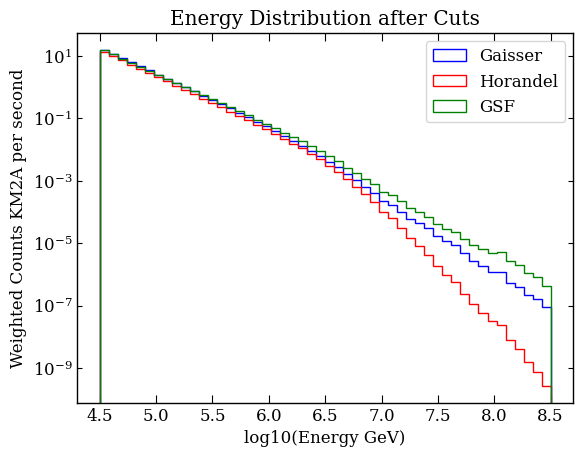

In [70]:

plt.hist(np.log10(df_cut['E']), bins=50, range=(4.5, 8.5), weights=df_cut['weightGaisser'], histtype='step', label='Gaisser', color='blue')
plt.hist(np.log10(df_cut['E']), bins=50, range=(4.5, 8.5), weights=df_cut['weightHorandol'], histtype='step', label='Horandel', color='red')
plt.hist(np.log10(df_cut['E']), bins=50, range=(4.5, 8.5), weights=df_cut['weightGSF'], histtype='step', label='GSF', color='green')
plt.xlabel('log10(Energy GeV)')
plt.ylabel('Weighted Counts KM2A per second')
plt.title('Energy Distribution after Cuts')
plt.yscale('log')
plt.legend()
# plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures
plt.show()

In [26]:
# 检查天顶角与核心位置分布的影响
pr_df_large['core_r'] = np.hypot(pr_df_large['core_x'], pr_df_large['core_y'])
pr_df_large_outer = pr_df_large[pr_df_large['theta'] > 66* np.pi/180]
print(f"Number of events with theta > 66°: {len(pr_df_large_outer)}")
pr_df_large_outer = pr_df_large[pr_df_large['core_r'] > 650]
print(f"Number of events with core radius > 650 m: {len(pr_df_large_outer)}")
len(pr_df_large)

Number of events with theta > 66°: 0
Number of events with core radius > 650 m: 0


6259

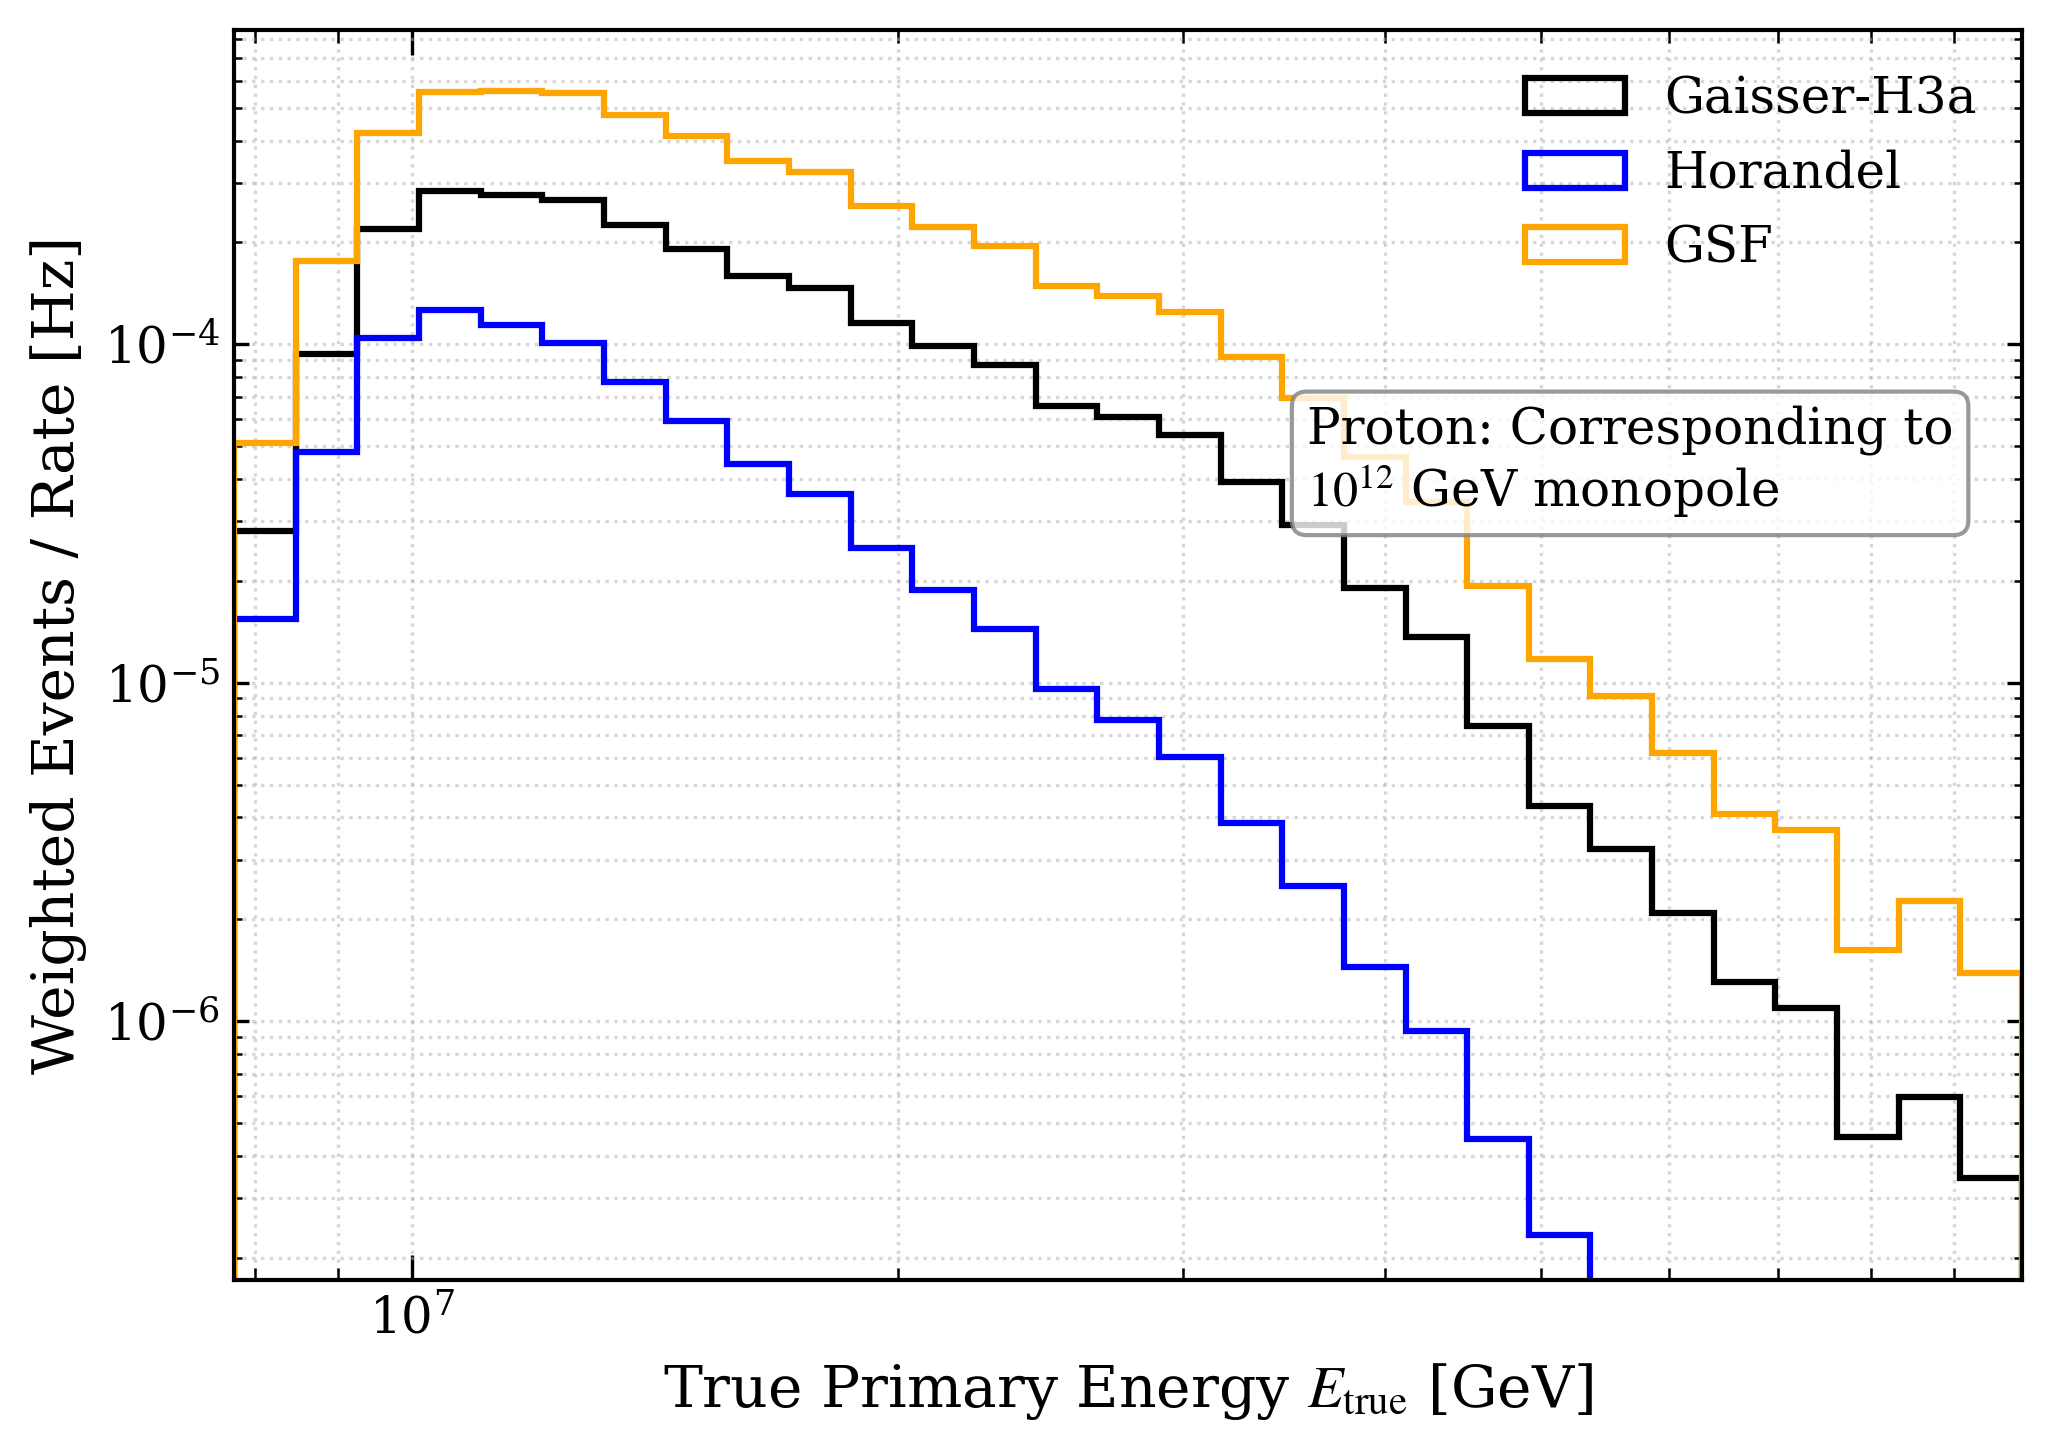

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. 学术风格设置 ---

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Liberation Serif", "serif"],
    "font.size": 12,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "mathtext.fontset": "stix"
})

def plot_background_spectrum(df):
    # --- 2. 数据准备 ---
    # 提取真能量和权重
    true_e = df['trueE'].values
    weights = df['gaisser_weight'].values
    weights_horandel = df['horandel_weight'].values
    weights_gsf = df['GSF_weight'].values
    
    # --- 关键步骤：设置对数 Binning ---
    # 宇宙线能谱通常跨越多个数量级，线性 Bin (bins=100) 会导致低能堆积，高能看不见
    # 我们根据数据的最大最小值生成对数均匀的 Bin
    min_e = np.min(true_e[true_e > 0]) # 防止 log(0)
    max_e = np.max(true_e)
    # 生成 60 个对数均匀的 bin
    log_bins = np.logspace(np.log10(min_e), np.log10(max_e), 30)
    
    # --- 3. 绘图 ---
    fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
    
    # 绘制加权直方图
    # 使用 'step' 风格，颜色使用标准的深灰色或黑色，符合学术习惯
    counts, edges, _ = ax.hist(true_e, bins=log_bins, weights=weights,
                               histtype='step', color='black', lw=1.5, label='Gaisser-H3a')
    ax.hist(true_e, bins=log_bins, weights=weights_horandel,
                histtype='step', color='blue', lw=1.5, label='Horandel')
    ax.hist(true_e, bins=log_bins, weights=weights_gsf,
            histtype='step', color='orange', lw=1.5, label='GSF')
    
    # 填充颜色 (可选，增加美观度)
#     ax.hist(true_e, bins=log_bins, weights=weights_gsf,
#             histtype='step', color='orange', alpha=1, label='GSF')

#     ax.hist(true_e, bins=log_bins, weights=weights,
#             histtype='step', color='gray', alpha=1, label='Gaisser-H3a')
#     ax.hist(true_e, bins=log_bins, weights=weights_horandel,
#             histtype='step', color='blue', alpha=1, label='Horandel')
    
    # --- 4. 坐标轴设置 ---
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # 标签 (假设单位是 GeV，如果不是请修改)
    ax.set_xlabel(r"True Primary Energy $E_{\mathrm{true}}$ [GeV]", fontsize=14)
    ax.set_ylabel("Weighted Events / Rate [Hz]", fontsize=14)
    
    # 范围微调
    ax.set_xlim(min_e, max_e)
    # y轴下限设为非零的最小值，防止 log 轴显示问题
    if np.max(counts) > 0:
        ax.set_ylim(bottom=np.min(counts[counts > 0]) * 0.5, top=np.max(counts) * 3)

    # 图例与网格
    ax.legend(frameon=False, fontsize=12)
    ax.grid(True, which="both", ls=":", alpha=0.5)
    
    # 添加说明文本 (可选)
    ax.text(0.6, 0.70, "Proton: Corresponding to\n$10^{12}$ GeV monopole", 
            transform=ax.transAxes, va='top', fontsize=12,
            bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

    plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e12_MC_Proton_Spectrum.pdf", bbox_inches='tight')
    plt.show()

# 执行绘图
plot_background_spectrum(pr_df_large)

# (pr_df_large[pr_df_large['trueE']<9e6]['gaisser_weight'].sum())/(pr_df_large['gaisser_weight'].sum())


EXP in SR: Total weight: 1.00, One year: 0.33
MN in SR: Total weight: 3081.11

=== Using weight column: gaisser_weight ===
[EF] Auto-clipping 2%-98%: base range (-1.54, -1.07)
Learned shift for EF in R_ue: 0.022 (Other mean: -1.251, Base mean: -1.274)
[QF] Auto-clipping 2%-98%: base range (-1.54, -1.07)
Learned shift for QF in R_ue: -0.031 (Other mean: -1.304, Base mean: -1.274)
Using weight column: gaisser_weight, Num =[0.79325511 1.34066141 3.30996609]
Mean Rate: 1.8146;
Max Rate: mean * (1+ 0.8240)= 1.8240;
Min Rate: mean * (1- 0.5629)= 0.4371;

=== Using weight column: GSF_weight ===
[EF] Auto-clipping 2%-98%: base range (-1.54, -1.07)
Learned shift for EF in R_ue: 0.022 (Other mean: -1.251, Base mean: -1.273)
[QF] Auto-clipping 2%-98%: base range (-1.54, -1.07)
Learned shift for QF in R_ue: -0.030 (Other mean: -1.303, Base mean: -1.273)
Using weight column: GSF_weight, Num =[1.78914798 4.57422873 7.38613873]
Mean Rate: 4.5832;
Max Rate: mean * (1+ 0.6116)= 1.6116;
Min Rate: mean *

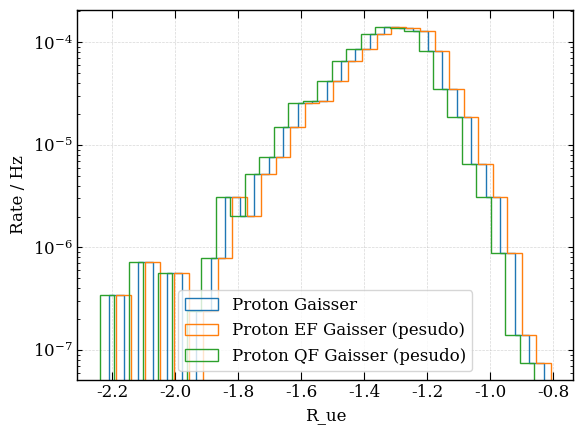

: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad

def extrapolate_and_integrate_rue(df, param_name="R_ue", 
                                  fit_range=(-2.25, -1.5), 
                                  extrap_range=(-3.0, -2.25),
                                  bins=40, hist_range=(-3.5, -0.5),  weight_col='gaisser_weight',
                                  plot_check=True):
    """
    对指定的变量在对数坐标下进行线性拟合外推，并计算外推区间的积分事例率。
    
    参数:
    - df: 包含数据的 DataFrame (如 Proton Background)
    - param_name: 变量名，默认 "R_ue"
    - fit_range: 拟合区间 (tuple)
    - extrap_range: 外推积分区间 (tuple)
    - bins: 直方图的 bin 数量，需与原图保持一致以保证 bin width 一致
    - hist_range: 直方图的整体范围
    - plot_check: 是否绘制拟合和外推结果图检查
    """
    
    # 1. 数据与权重提取 (复用你的鲁棒代码)
    data_series = pd.to_numeric(df[param_name], errors='coerce')
    data = data_series.values
    
    if 'gaisser_weight' in df.columns:
        weights = pd.to_numeric(df[weight_col], errors='coerce').values
    elif 'weight' in df.columns:
        weights = pd.to_numeric(df['weight'], errors='coerce').values
    else:
        weights = np.ones_like(data)

    mask = ~np.isnan(data) & ~np.isnan(weights)
    clean_data = data[mask]
    clean_weights = weights[mask]
    
    # 2. 生成直方图，获取 bin counts 和 bin centers
    counts, bin_edges = np.histogram(clean_data, bins=bins, range=hist_range, weights=clean_weights)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]
    
    # 3. 筛选拟合区间内的数据 (并且 Rate > 0，避免 log10 报错)
    fit_mask = (bin_centers >= fit_range[0]) & (bin_centers <= fit_range[1]) & (counts > 0)
    x_fit = bin_centers[fit_mask]
    y_fit = np.log10(counts[fit_mask])
    
    if len(x_fit) < 2:
        raise ValueError("拟合区间内有效数据点不足，请检查 fit_range 或增加 bins。")

    # 4. 线性拟合: log10(y) = k * x + b
    k, b = np.polyfit(x_fit, y_fit, 1)
    # print(f"拟合结果: log10(Rate) = {k:.4f} * R_ue + {b:.4f}")
    
    # 定义还原后的指数函数 y = 10^(k*x + b)
    def extrap_func(x):
        return 10**(k * x + b)
    
    # 5. 在外推区间进行积分
    # 注意：直方图的 y 轴是 Rate/bin，因此连续积分后需要除以 bin_width 才能得到总 Rate
    integral_val, error = quad(extrap_func, extrap_range[0], extrap_range[1])
    estimated_rate = integral_val / bin_width
    # print(f"外推区间 [{extrap_range[0]}, {extrap_range[1]}] 的预期总 Rate 为: {estimated_rate*TIME_EXP:.4f} Hz")
    
    # 6. 可视化检查 (强烈建议开启以确认拟合质量)
    if plot_check:
        plt.figure(figsize=(8, 6), dpi=150)
        
        # 绘制原始直方图 (Step)
        plt.hist(bin_centers, bins=bin_edges, weights=counts, histtype='step',
                 label='Original Background', color='#d62728', linewidth=1.5, linestyle='--')
        
        # 绘制用于拟合的数据点
        plt.scatter(x_fit, counts[fit_mask], color='black', zorder=5, label='Data used for Fit')
        
        # 绘制拟合线
        x_line_fit = np.linspace(fit_range[0], fit_range[1], 100)
        y_line_fit = extrap_func(x_line_fit)
        plt.plot(x_line_fit, y_line_fit, color='blue', linewidth=2, label='Linear Fit')
        
        # 绘制外推线
        x_line_extrap = np.linspace(extrap_range[0], extrap_range[1], 100)
        y_line_extrap = extrap_func(x_line_extrap)
        plt.plot(x_line_extrap, y_line_extrap, color='green', linewidth=2, linestyle='-.', label='Extrapolation')
        
        # 填充外推积分区域
        plt.fill_between(x_line_extrap, y_line_extrap, 1e-11, color='green', alpha=0.2, label='Integrated Area')

        plt.yscale('log')
        plt.xlim(hist_range)
        plt.ylim(bottom=1e-11) # 与原图保持一致
        plt.xlabel(r"$R_{\mu e}$", fontsize=14)
        plt.ylabel("Rate / Hz", fontsize=14)
        plt.title("Background Extrapolation Check", fontweight='bold')
        plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()
        
    return estimated_rate, (k, b)

# ========== 使用方法 ==========
TIME_EXP=365*86400 * 3 
scale_factor = 5/3
SR_Emin = 3.85
SR_Emax = 4.15
SR_Ruelimit = -2.4
SR_Ruelimit_low = -5

def report_sr_counts(df, label):
    df = df[(df['recE'] > SR_Emin) & (df['recE'] < SR_Emax) & (df['R_ue'] < SR_Ruelimit)]
    if "gaisser_weight" in df.columns:
        weight_sr = df['gaisser_weight'].sum()
    elif "weight" in df.columns:
        weight_sr = df['weight'].sum()
    if label =="EXP":    
        print(f"{label} in SR: Total weight: {weight_sr:.2f}, One year: {weight_sr/3:.2f}")
    else:
        weight_sr = weight_sr * TIME_EXP * scale_factor
        print(f"{label} in SR: Total weight: {weight_sr:.2f}")
        
    return weight_sr   

exp_num=report_sr_counts(exp_muon_Rue_df_large, "EXP")     
mn_num=report_sr_counts(mn_df_large, "MN")

pr_df_large_recE_SR = pr_df_large[(pr_df_large['recE']>SR_Emin) & (pr_df_large['recE']<SR_Emax)]

#  learn shift in SR within different models
def learn_shift(df_base, df_other, var_col, weight_col="gaisser_weight", recE_SR=True, val_range=None, label=""):
    # 1. 基础的能量区间过滤 (保持原逻辑)
    if recE_SR:
        df_base = df_base[(df_base['recE'] > SR_Emin) & (df_base['recE'] < SR_Emax)].copy()
        df_other = df_other[(df_other['recE'] > SR_Emin) & (df_other['recE'] < SR_Emax)].copy()
    else:
        df_base = df_base.copy()
        df_other = df_other.copy()

    # 2. 处理参数区间过滤 (val_range)
    if val_range is None:
        # 如果为 None，去掉两端 2% 的数据 (保留 2% 到 98% 之间)
        lower_q = df_base[var_col].quantile(0.02)
        upper_q = df_base[var_col].quantile(0.98)
        df_base = df_base[(df_base[var_col] >= lower_q) & (df_base[var_col] <= upper_q)]
        
        # 建议 df_other 也使用相同的分位数基准，或者根据自身计算
        lower_q_other = df_other[var_col].quantile(0.02)
        upper_q_other = df_other[var_col].quantile(0.98)
        df_other = df_other[(df_other[var_col] >= lower_q_other) & (df_other[var_col] <= upper_q_other)]
        
        print(f"[{label}] Auto-clipping 2%-98%: base range ({lower_q:.2f}, {upper_q:.2f})")
    else:
        # 如果指定了区间，如 (min, max)
        v_min, v_max = val_range
        df_base = df_base[(df_base[var_col] >= v_min) & (df_base[var_col] <= v_max)]
        df_other = df_other[(df_other[var_col] >= v_min) & (df_other[var_col] <= v_max)]
        print(f"[{label}] Using specified range: {val_range}")

    # 3. 计算加权平均值
    # 注意：过滤后可能导致 df 为空，增加一个保护判断
    if len(df_base) == 0 or len(df_other) == 0:
        print(f"Warning: No data left after filtering for {label}")
        return 0.0

    base_var_mean = np.average(df_base[var_col], weights=df_base[weight_col])
    other_var_mean = np.average(df_other[var_col], weights=df_other[weight_col])
    
    shift = other_var_mean - base_var_mean
    
    print(f"Learned shift for {label} in {var_col}: {shift:.3f} (Other mean: {other_var_mean:.3f}, Base mean: {base_var_mean:.3f})")
    return shift
def generate_pseudo_df(df, shift, var_col,):
    df_pseudo = df.copy()
    df_pseudo[var_col] = df_pseudo[var_col] + shift
    return df_pseudo


# 'horandel_weight',
fit_range = (-2.05, -1.4)
spec_num= []
for weight_col in ['gaisser_weight',  'GSF_weight']:
    print(f"\n=== Using weight column: {weight_col} ===")
    ef_Rue_shift = learn_shift(pr_df, pr_ef_df, 'R_ue', weight_col=weight_col, label="EF")
    qf_Rue_shift = learn_shift(pr_df, pr_qf_df, 'R_ue', weight_col=weight_col, label="QF")

    pseudo_ef_df_recE_SR = generate_pseudo_df(pr_df_large_recE_SR, ef_Rue_shift, 'R_ue')
    pseudo_qf_df_recE_SR = generate_pseudo_df(pr_df_large_recE_SR, qf_Rue_shift, 'R_ue')
    
    estimated_num = np.array([])
    estimated_bg, fit_params = extrapolate_and_integrate_rue(
        df = pr_df_large_recE_SR, 
        param_name="R_ue",
        fit_range=fit_range, 
        extrap_range=(SR_Ruelimit_low, SR_Ruelimit),
        bins=40,              # 必须与你原图中画 R_ue 用的 bins 数量一致
        hist_range=(-3.5, -0.5), # 必须与你原图中画 R_ue 用的 x_range 一致
        weight_col=weight_col,
        plot_check=False
    )


    estimated_bg_ef, fit_params = extrapolate_and_integrate_rue(
        df = pseudo_ef_df_recE_SR, 
        param_name="R_ue",
        fit_range=fit_range, 
        extrap_range=(SR_Ruelimit_low, SR_Ruelimit),
        bins=40,              # 必须与你原图中画 R_ue 用的 bins 数量一致
        hist_range=(-3.5, -0.5), # 必须与你原图中画 R_ue 用的 x_range 一致
        weight_col=weight_col,
        plot_check=False
    )


    estimated_bg_qf, fit_params = extrapolate_and_integrate_rue(
        df = pseudo_qf_df_recE_SR, 
        param_name="R_ue",
        fit_range=fit_range, 
        extrap_range=(SR_Ruelimit_low, SR_Ruelimit),
        bins=40,              # 必须与你原图中画 R_ue 用的 bins 数量一致
        hist_range=(-3.5, -0.5), # 必须与你原图中画 R_ue 用的 x_range 一致
        weight_col=weight_col,
        plot_check=False
    )
    
    
    estimated_num = np.append(estimated_num, [estimated_bg, estimated_bg_ef, estimated_bg_qf])
    estimated_num = estimated_num * TIME_EXP * scale_factor   
    spec_num.append(estimated_num.mean())
    print(f"Using weight column: {weight_col}, Num ={estimated_num}")
    print(f"Mean Rate: {np.mean(estimated_num):.4f};")
    print(f"Max Rate: mean * (1+ {(np.max(estimated_num)-np.mean(estimated_num))/np.mean(estimated_num):.4f})= {(1 + ((np.max(estimated_num)-np.mean(estimated_num))/np.mean(estimated_num))):.4f};")
    print(f"Min Rate: mean * (1- {(np.mean(estimated_num)-np.min(estimated_num))/np.mean(estimated_num):.4f})= {(1 - ((np.mean(estimated_num)-np.min(estimated_num))/np.mean(estimated_num))):.4f};")

print(f"\nMean Spec: {np.mean(spec_num):.4f};")
print(f"Max Spec: mean * (1 + {((np.max(spec_num)-np.mean(spec_num))/np.mean(spec_num)):.4f})= {(1 + ((np.max(spec_num)-np.mean(spec_num))/np.mean(spec_num))):.4f}; ")
print(f"Min Spec: mean * (1 - {((np.mean(spec_num)-np.min(spec_num))/np.mean(spec_num)):.4f})= {(1 - ((np.mean(spec_num)-np.min(spec_num))/np.mean(spec_num))):.4f};")


print(f"{np.asarray(spec_num)}, Mean 5 years={np.mean(spec_num):.4f}")
print(f"S/sqrt(B) = {mn_num/np.sqrt(np.mean(spec_num)):.4f} for 5 years")



bins=30
plt.hist(pr_df_large_recE_SR['R_ue'], bins=bins, weights=pr_df_large_recE_SR['gaisser_weight'], histtype='step', label='Proton Gaisser')
plt.hist(pseudo_ef_df_recE_SR['R_ue'], bins=bins, weights=pseudo_ef_df_recE_SR['gaisser_weight'], histtype='step', label='Proton EF Gaisser (pesudo)')
plt.hist(pseudo_qf_df_recE_SR['R_ue'], bins=bins, weights=pseudo_qf_df_recE_SR['gaisser_weight'], histtype='step', label='Proton QF Gaisser (pesudo)')
plt.legend()
plt.xlabel("R_ue")
plt.ylabel("Rate / Hz")
plt.yscale('log')
plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)
plt.show()



In [ ]:
a=np.array([3.6182,1.6577])
std_a=np.std(a)
print(std_a/np.mean(a))

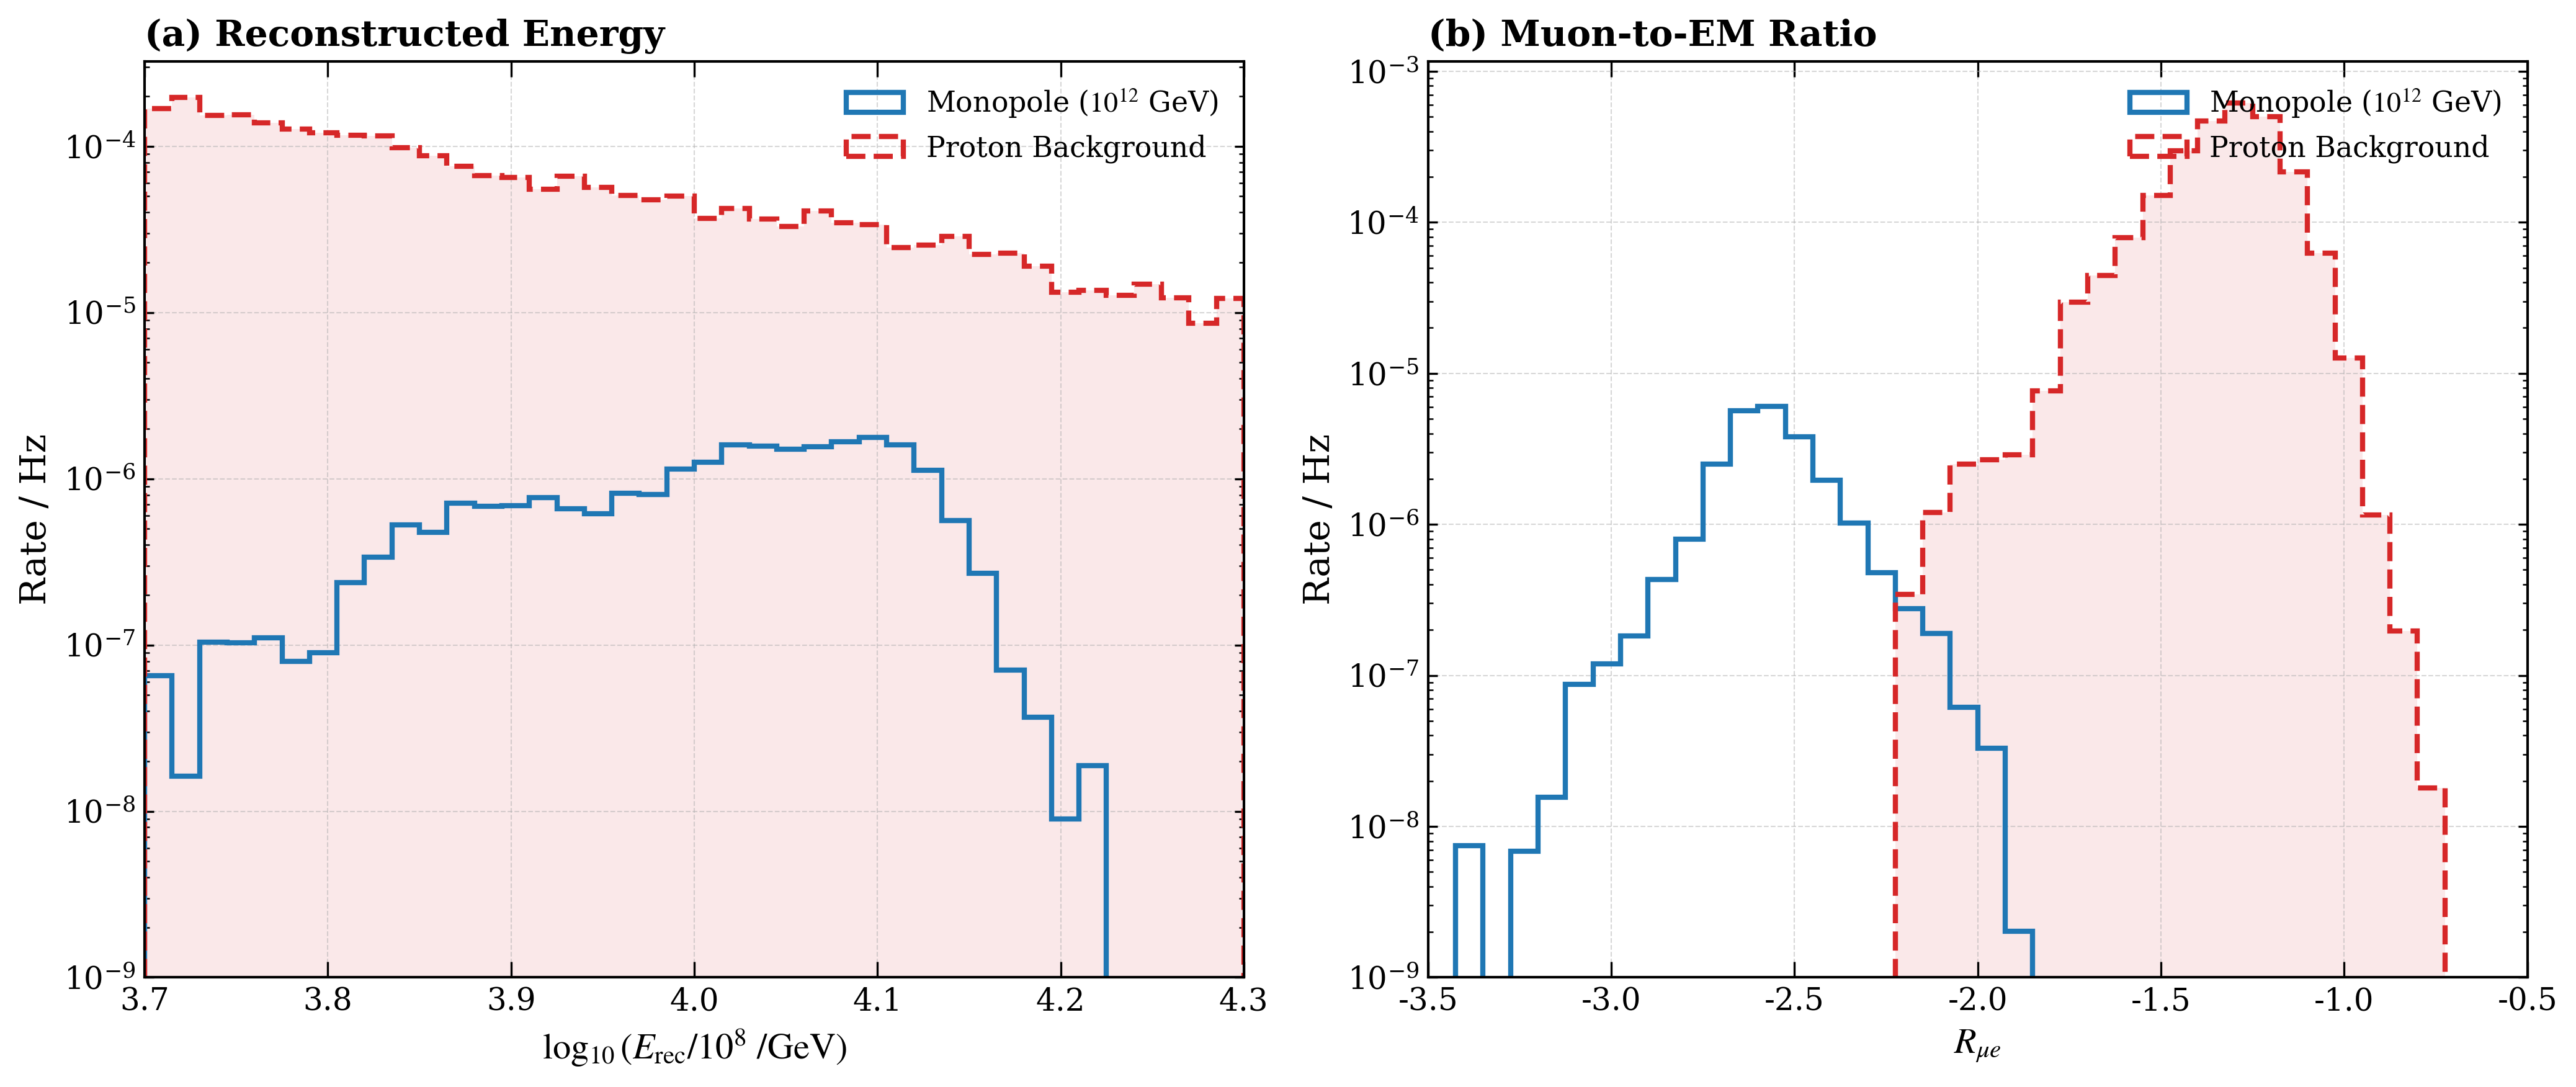

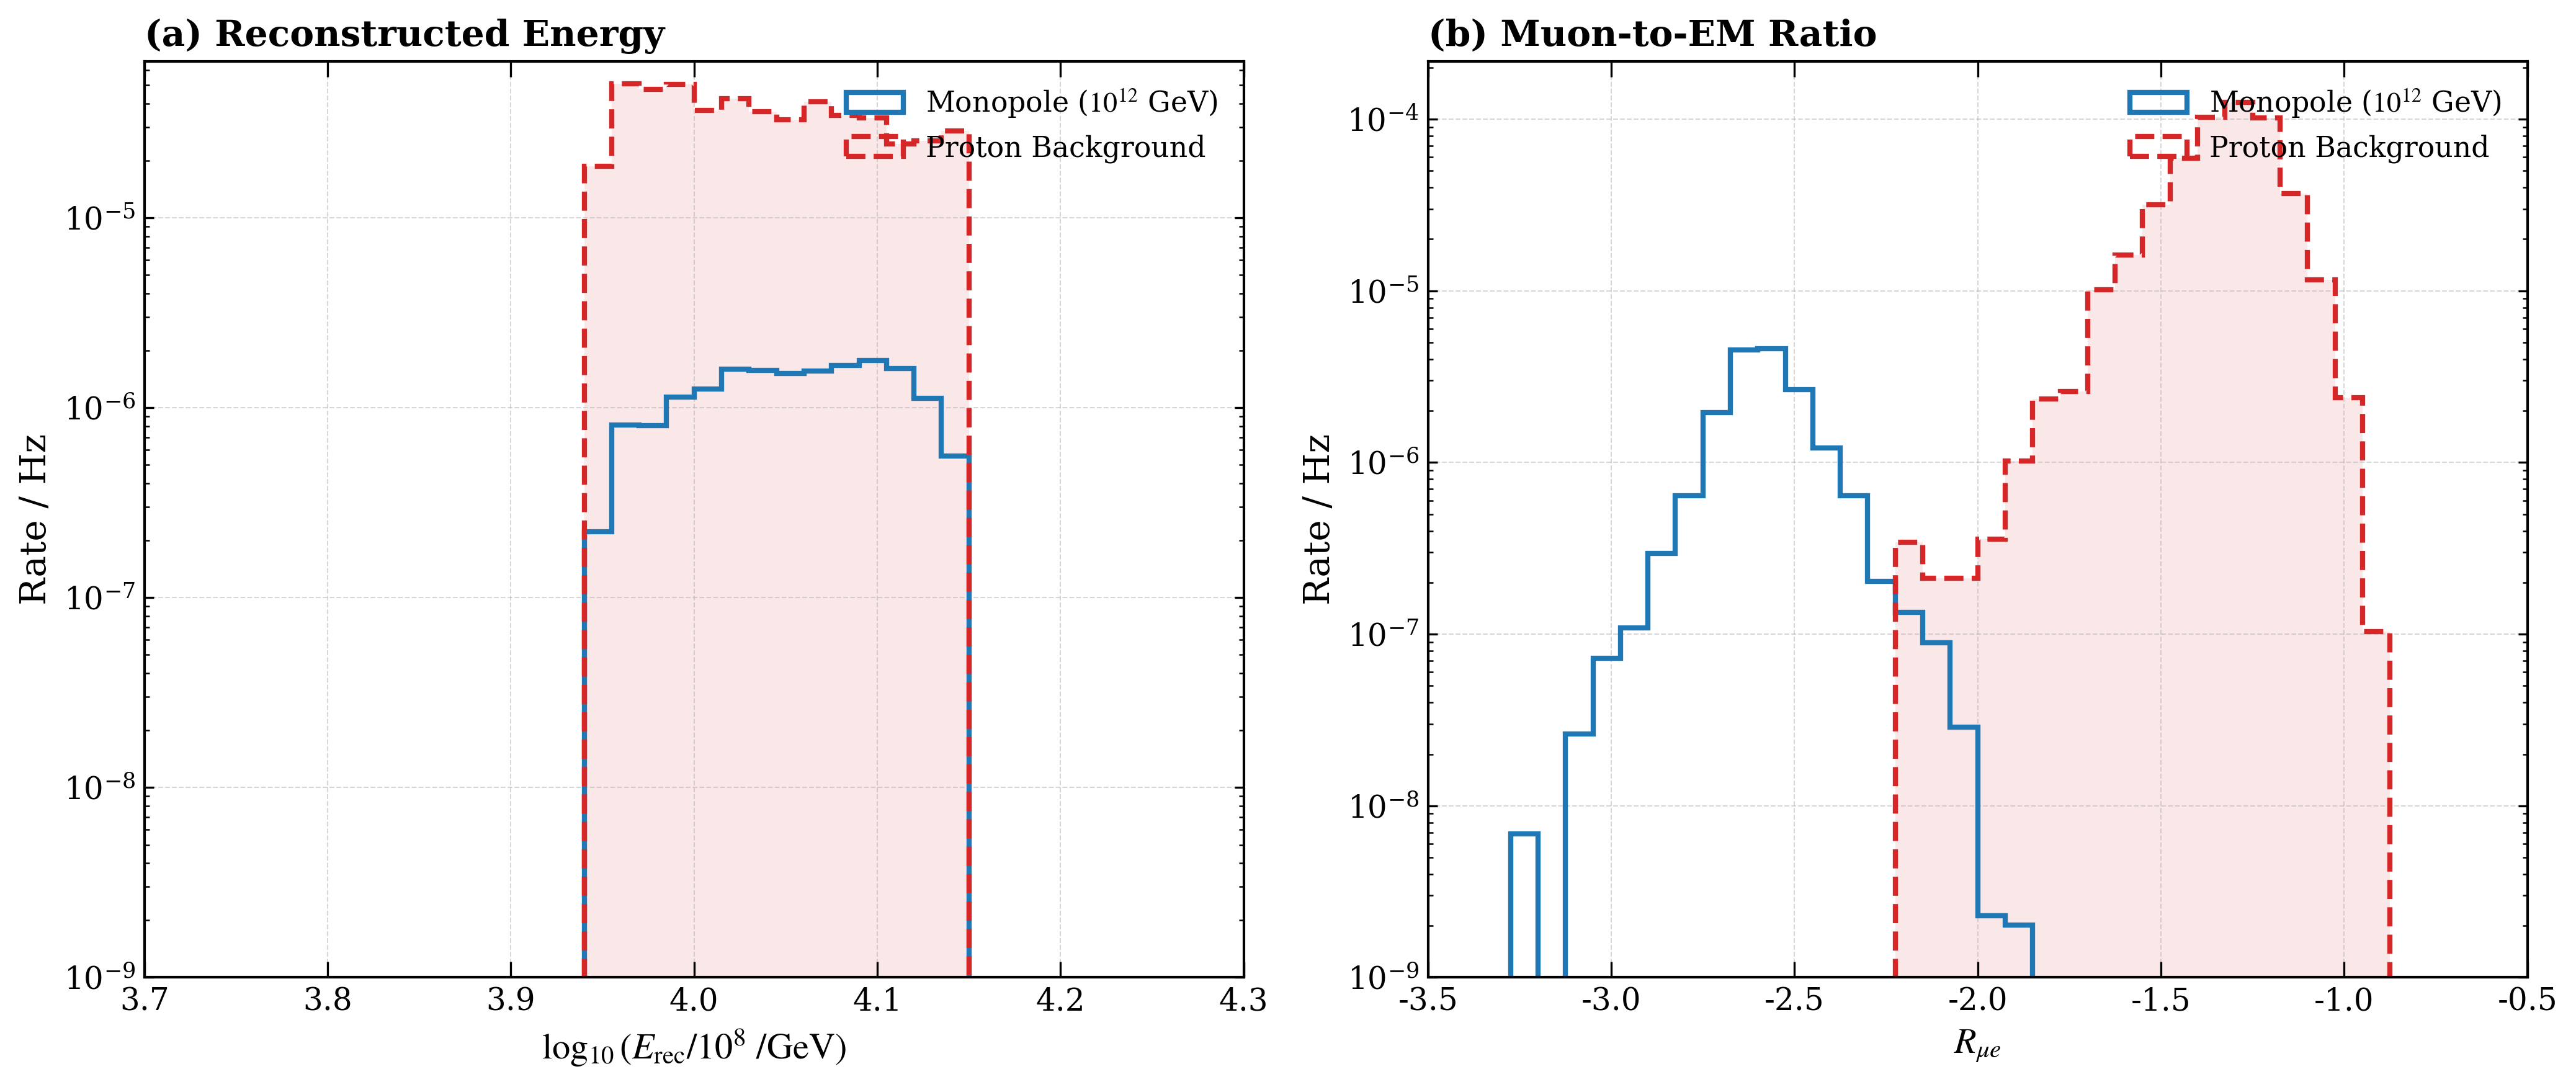

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_formal_recE_Rue(df_list: dict, bins=60, figsize=(14, 6)):
    """
    专门绘制 recE 和 R_ue 的正式对比图，支持权重。
    包含数据类型强制转换和鲁棒的字体设置。
    """
    # 1. 设置学术风格 (兼容 Linux 环境)
    # 如果找不到 Times New Roman，Matplotlib 会回退到 DejaVu Serif，这同样是符合学术标准的衬线体
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "font.size": 12,
        "axes.unicode_minus": False,
        "axes.linewidth": 1.0,
        "xtick.major.size": 6,
        "xtick.minor.size": 3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True
    })

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, dpi=300)
    
    # 定义配色方案
    colors = ['#1f77b4', '#d62728', 'black', '#2ca02c'] 
    linestyles = ['-', '--', '-.', ':']

    # --- 绘图核心函数 ---
    def plot_variable(ax, param_name, x_range, log_y=False, x_label="", y_label=""):
        for idx, (label, df) in enumerate(df_list.items()):
            # 检查列是否存在
            if param_name not in df.columns:
                print(f"Warning: '{param_name}' not found in dataset '{label}'")
                continue
                
            # --- [修复核心] 强制转换为数值类型 ---
            # errors='coerce' 会将无法转换的字符串变成 NaN，避免 TypeError
            data_series = pd.to_numeric(df[param_name], errors='coerce')
            data = data_series.values
            
            # --- 权重处理 ---
            if 'gaisser_weight' in df.columns:
                w_series = pd.to_numeric(df['gaisser_weight'], errors='coerce')
                weights = w_series.values
            elif 'weight' in df.columns:
                w_series = pd.to_numeric(df['weight'], errors='coerce')
                weights = w_series.values
            else:
                weights = np.ones_like(data)

            # --- 数据清洗 (去 NaN) ---
            # 现在的 data 和 weights 都是 float 类型，np.isnan 可以正常工作了
            mask = ~np.isnan(data) & ~np.isnan(weights)
            
            # 额外过滤：只保留在 x_range 范围内的数据（可选，但推荐，防止极值破坏密度计算）
            if x_range:
                mask &= (data >= x_range[0]) & (data <= x_range[1])

            clean_data = data[mask]
            clean_weights = weights[mask]

            # 防止空数据报错
            if len(clean_data) == 0:
                print(f"Warning: No valid data for '{label}' in range {x_range}")
                continue

            # 计算加权直方图
            if param_name == "recE":
                counts, bin_edges = np.histogram(
                    clean_data, bins=bins, range=x_range, weights=clean_weights, density=False
                )
            elif param_name == "R_ue":
                counts, bin_edges = np.histogram(
                    clean_data, bins=bins, range=x_range, weights=clean_weights,
                )
            
            # 构造阶梯图数据
            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            
            c = colors[idx % len(colors)]
            ls = linestyles[idx % len(linestyles)]
            
            # 绘制 Step 线
            ax.hist(bin_centers, bins=bin_edges, weights=counts, histtype='step',
                    label=label, color=c, linewidth=2, linestyle=ls)
            
            # 填充效果
            if 'exp' in label.lower() or 'background' in label.lower():
                 ax.hist(bin_centers, bins=bin_edges, weights=counts, histtype='stepfilled',
                    color=c, alpha=0.1)

        # 轴修饰
        ax.set_xlabel(x_label, fontsize=14)
        ax.set_ylabel(y_label, fontsize=14)
        
        if x_range:
            ax.set_xlim(x_range)
        
        if log_y:
            ax.set_yscale('log')
            ax.set_ylim(bottom=1e-9) 
            
        ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.legend(frameon=False, fontsize=11, loc='upper right')

    # --- 2. 绘制 recE (重建能量) ---
    plot_variable(
        ax1, 
        param_name="recE", 
        x_range=(3.7, 4.3), 
        log_y=True, 
        x_label=r"$\log_{10}(E_{\mathrm{rec}}{/10^{8}} ~/ \mathrm{GeV})$",
        y_label="Rate / Hz"
    )
    ax1.set_title("(a) Reconstructed Energy", loc='left', fontweight='bold', fontsize=14)

    # --- 3. 绘制 R_ue (μ/e 比率) ---
    plot_variable(
        ax2, 
        param_name="R_ue", 
        x_range=(-3.5, -0.5), 
        log_y=True, 
        x_label=r"$R_{\mu e}$",
        y_label="Rate / Hz"
    )
    ax2.set_title("(b) Muon-to-EM Ratio", loc='left', fontweight='bold', fontsize=14)

    plt.tight_layout()
    # plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e12_energy_rue_KeyParams_cut.pdf", bbox_inches='tight')
    plt.show()

# 这里的 df_list 需要你传入你的变量
# plot_formal_recE_Rue(df_list, bins=50)

# --- 使用示例 ---
# 假设你的 DataFrame 已经准备好
# exp_full_rue_df = pd.concat([exp_muon_Rue_df_large, exp_no_muon_cut_df[exp_no_muon_cut_df['R_ue'] > -1.9]], ignore_index=True)
SR_Emin = 3.95
SR_Emax = 4.15

df_list = {
    "Monopole ($10^{12}$ GeV)": mn_df_large,
    "Proton Background": pr_df_large,
    # "Experimental Data": exp_full_rue_df,
}

plot_formal_recE_Rue(df_list, bins=40)


mn_df_large_recE_SR = mn_df_large[(mn_df_large['recE']>SR_Emin) & (mn_df_large['recE']<SR_Emax)]
pr_df_large_recE_SR = pr_df_large[(pr_df_large['recE']>SR_Emin) & (pr_df_large['recE']<SR_Emax)]
df_list = {
    "Monopole ($10^{12}$ GeV)": mn_df_large_recE_SR,
    "Proton Background": pr_df_large_recE_SR,
    # "Experimental Data": exp_full_rue_df,
}
plot_formal_recE_Rue(df_list, bins=40)





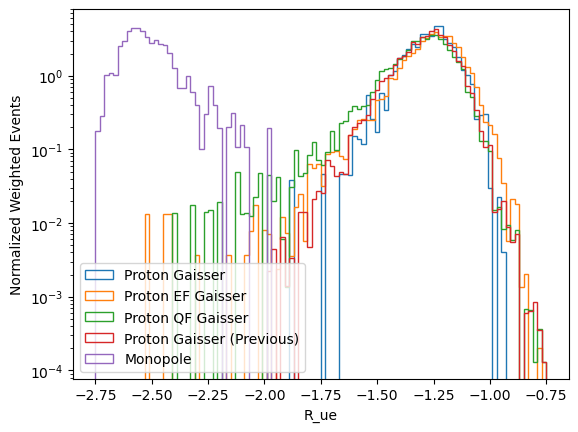

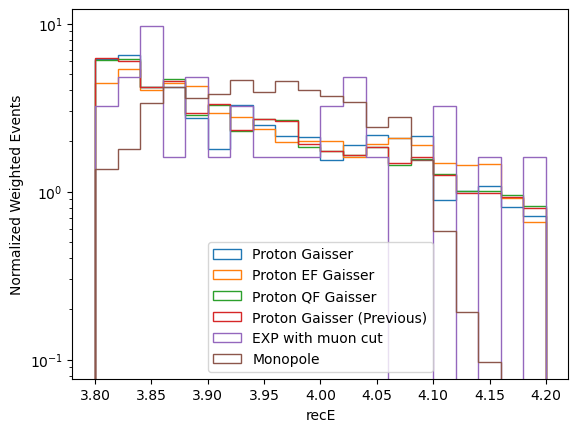

In [6]:
bins=100
plt.hist(pr_df['R_ue'], bins=bins, weights=pr_df['gaisser_weight'], histtype='step', density=True, label='Proton Gaisser', range=[-2.75, -0.75])
plt.hist(pr_ef_df['R_ue'], bins=bins, weights=pr_ef_df['gaisser_weight'], histtype='step', density=True, label='Proton EF Gaisser', range=[-2.75, -0.75])
plt.hist(pr_qf_df['R_ue'], bins=bins, weights=pr_qf_df['gaisser_weight'], histtype='step', density=True, label='Proton QF Gaisser', range=[-2.75, -0.75])
plt.hist(proton_df_QF['R_ue'], bins=bins, weights=proton_df_QF['weightGaisser'], histtype='step', density=True, label='Proton Gaisser (Previous)', range=[-2.75, -0.75])
plt.hist(mn_df['R_ue'], bins=bins, weights=mn_df['weight'], histtype='step', density=True, label='Monopole', range=[-2.75, -0.75])
plt.xlabel("R_ue")
plt.ylabel("Normalized Weighted Events")
plt.legend()
plt.yscale('log')
plt.show()

bins=20
plt.hist(pr_df['recE'], bins=bins, weights=pr_df['gaisser_weight'], histtype='step', density=True, label='Proton Gaisser', range=[3.8, 4.2])
plt.hist(pr_ef_df['recE'], bins=bins, weights=pr_ef_df['gaisser_weight'], histtype='step', density=True, label='Proton EF Gaisser', range=[3.8, 4.2])
plt.hist(pr_qf_df['recE'], bins=bins, weights=pr_qf_df['gaisser_weight'], histtype='step', density=True, label='Proton QF Gaisser', range=[3.8, 4.2])
plt.hist(proton_df_QF['recE'], bins=bins, weights=proton_df_QF['weightGaisser'], histtype='step', density=True, label='Proton Gaisser (Previous)', range=[3.8, 4.2])
plt.hist(exp_muon_Rue_df['recE'], bins=bins, weights=exp_muon_Rue_df['weight'], histtype='step', density=True, label='EXP with muon cut', range=[3.8, 4.2])
plt.hist(mn_df['recE'], bins=bins, weights=mn_df['weight'], histtype='step', density=True, label='Monopole', range=[3.8, 4.2])
plt.xlabel("recE")
plt.ylabel("Normalized Weighted Events")
plt.legend()
plt.yscale('log')
plt.show()


In [ ]:
# r_low=300
# r_high=450
# theta_low=0
# theta_high=35 / 180.0 * np.pi

# Eage_low=0.8
# Eage_high=2.4
# # R_ue_high=-5.0
# log10TeV_low=3.7
# log10TeV_high=4.3


# def load_allweight_model():
    
#     r_low=300
#     r_high=450
#     theta_low=0
#     theta_high=35 / 180.0 * np.pi

#     Eage_low=0.8
#     Eage_high=2.4
#     # R_ue_high=-5.0
#     log10TeV_low=3.7
#     log10TeV_high=4.3

#     def open_file(file_name):
#         with uproot.open(file_name) as file:
#             tree = file["Rec"]
#             branches_to_read = ["E", "theta","phi","corex","corey","rec_x","rec_y","rec_theta","rec_phi","rec_Eage","Redge","NpE3","NpE2","NpE1","NuM1","NuM2","NuM3","NuW3","weightGaisser","weightHorandol"]
#             df = tree.arrays(branches_to_read, library="pd")
#             all_weights_gaisser = df['weightGaisser'].sum()
#             all_weights_horandel = df['weightHorandol'].sum()
#             print(file_name)
#             print("     Entries:", tree.num_entries)
#             print("     Total weights Gaisser:", all_weights_gaisser)
#             print("     Total weights Horandel:", all_weights_horandel)

#             rec_Eage=df['rec_Eage'].values
#             rec_theta=df['rec_theta'].values
#             NuW3=df['NuW3'].values
#             rec_x=df['rec_x'].values
#             rec_y=df['rec_y'].values
#             r=np.sqrt(rec_x**2+rec_y**2)
#             df['rec_r']=r
#             cuts_indices = (rec_Eage > Eage_low) & (rec_Eage < Eage_high) & \
#                             (r > r_low) & (r < r_high) & \
#                             (rec_theta > theta_low) & (rec_theta < theta_high) & \
#                             (NuW3 > 0)
#             df_cut = df[cuts_indices].copy() 
            
#             df_cut["R_ue"]=np.log10((1e-4+df_cut["NuM1"])/(df_cut["NpE3"]+1))
#             print(f"     Entries after cut: {df_cut.shape[0]}")
#             del df
#             return df_cut
        

#     def energy_correction(df: pd.DataFrame):
#         import json
        
#         # 加载线性参数
#         with open("/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json", 'r') as f:
#             lp = json.load(f)
#         intercept  = lp["intercept"]
#         coef_NuW3  = lp["coef"][0]
#         coef_theta = lp["coef"][1]

#         theta      = df["rec_theta"].values
#         log10_NuW3 = np.log10(df["NuW3"].values)
        
#         feature_data = np.column_stack((log10_NuW3, theta))
        
#         # 线性基线 + XGBoost残差
#         linear_pred  = intercept + coef_NuW3 * log10_NuW3 + coef_theta * theta
#         xgb_residual = model.predict(feature_data)
#         corrected_energy = linear_pred + xgb_residual  # log10(E/1e8)
        
#         df["recE"] = corrected_energy
        
#         df_new = df[(df["recE"] > log10TeV_low) & (df["recE"] < log10TeV_high)]
#         print(f" cut weight Gaisser sum: {df_new['weightGaisser'].sum()}")
#         print(f" cut weight Horandel sum: {df_new['weightHorandol'].sum()}")
#         del df
#         return df_new


#     from xgboost import XGBRegressor
#     model = XGBRegressor()
#     model._estimator_type = "regressor"
#     model.load_model("/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json")

#     # proton_df_QF = open_file("/data/home/zzh/data/Dataset_Filted/CosmicRay/QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root")
#     proton_df_QF = open_file("/data/home/zzh/data/Dataset_Filted/CosmicRay/1e12_V04/Proton_reweighted_new_1e12.root")
#     proton_df_QF = energy_correction(proton_df_QF)
#     QF_allweights_gaisser=proton_df_QF['weightGaisser'].sum()
#     QF_allweights_horandel=proton_df_QF['weightHorandol'].sum()

   

#     return QF_allweights_gaisser,QF_allweights_horandel, proton_df_QF

# QF_allweights_gaisser, QF_allweights_horandel, proton_df_QF = load_allweight_model()


# for col in proton_df_QF.columns:
#     proton_df_QF[col] = pd.to_numeric(proton_df_QF[col], errors='coerce')
# len(proton_df_QF)

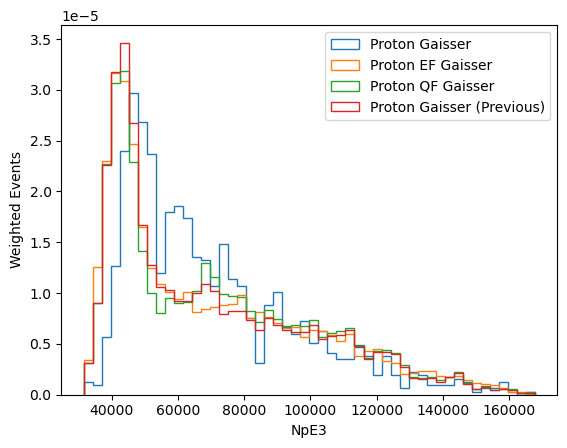

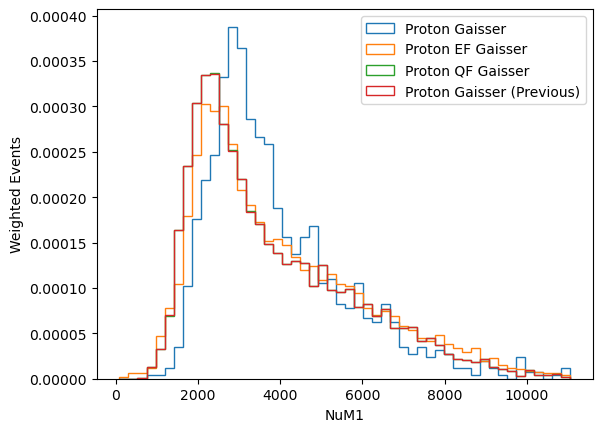

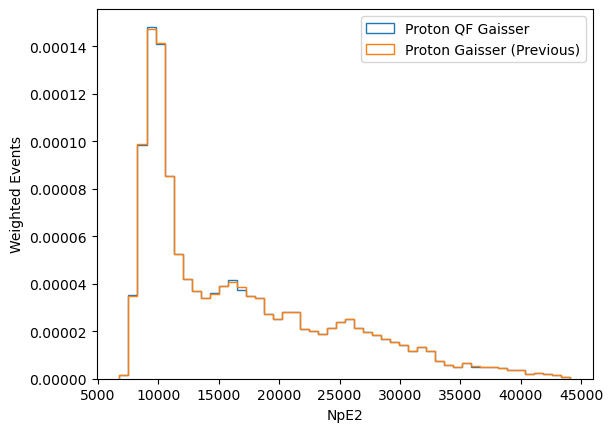

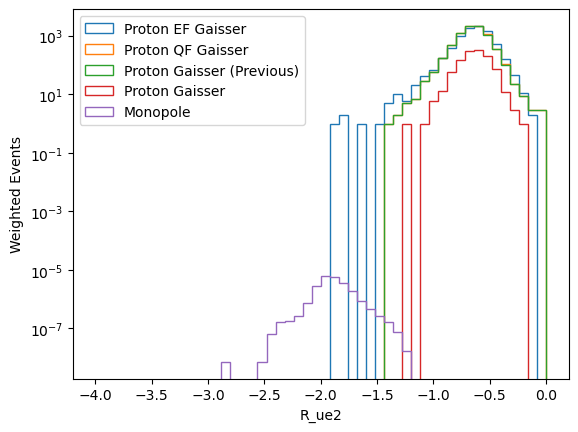

In [21]:
# pr_df = filter_small_models(pr_df_large)
# bins=100
# plt.hist(pr_df['R_ue'], bins=bins, weights=pr_df['gaisser_weight'], histtype='step', density=True, label='Proton Gaisser', range=[-2.75, -0.75])
# plt.hist(pr_ef_df['R_ue'], bins=bins, weights=pr_ef_df['gaisser_weight'], histtype='step', density=True, label='Proton EF Gaisser', range=[-2.75, -0.75])
# plt.hist(pr_qf_df['R_ue'], bins=bins, weights=pr_qf_df['gaisser_weight'], histtype='step', density=True, label='Proton QF Gaisser', range=[-2.75, -0.75])
# plt.hist(proton_df_QF['R_ue'], bins=bins, weights=proton_df_QF['weightGaisser'], histtype='step', density=True, label='Proton Gaisser (Previous)', range=[-2.75, -0.75])
# plt.hist(mn_df['R_ue'], bins=bins, weights=mn_df['weight'], histtype='step', density=True, label='Monopole', range=[-2.75, -0.75])
# plt.xlabel("R_ue")
# plt.ylabel("Normalized Weighted Events")
# plt.legend()
# plt.yscale('log')
# plt.show()

# pr_average_R_ue = np.average(pr_df['R_ue'], weights=pr_df['gaisser_weight'])
# pr_ef_average_R_ue = np.average(pr_ef_df['R_ue'], weights=pr_ef_df['gaisser_weight'])
# pr_qf_average_R_ue = np.average(pr_qf_df['R_ue'], weights=pr_qf_df['gaisser_weight'])
# pr_previous_average_R_ue = np.average(proton_df_QF['R_ue'], weights=proton_df_QF['weightGaisser'])
# # mn_average_R_ue = np.average(mn_df['R_ue'], weights=mn_df['weight'])


# print(f"pr: {pr_average_R_ue}, pr_ef: {pr_ef_average_R_ue}, pr_qf: {pr_qf_average_R_ue}, pr_previous: {pr_previous_average_R_ue}")



# # hist recE range 3.7-4.3
# bins=50
# plt.hist(pr_df['recE'], bins=bins, weights=pr_df['gaisser_weight'], histtype='step', density=True, label='Proton Gaisser', range=[3.7, 4.3])
# plt.hist(pr_ef_df['recE'], bins=bins, weights=pr_ef_df['gaisser_weight'], histtype='step', density=True, label='Proton EF Gaisser', range=[3.7, 4.3])
# plt.hist(pr_qf_df['recE'], bins=bins, weights=pr_qf_df['gaisser_weight'], histtype='step', density=True, label='Proton QF Gaisser', range=[3.7, 4.3])
# plt.hist(proton_df_QF['recE'], bins=bins, weights=proton_df_QF['weightGaisser'], histtype='step', density=True, label='Proton Gaisser (Previous)', range=[3.7, 4.3])
# # plt.hist(mn_df['recE'], bins=bins, weights=mn_df['weight'], histtype='step', density=True, label='Monopole', range=[3.7, 4.3])
# plt.xlabel("recE")
# plt.ylabel("Normalized Weighted Events")
# plt.legend()
# # plt.yscale('log')
# plt.show()


# # trueE no weight bins=50, range=[1e6, 1e8]
# plt.hist(pr_df['trueE'], bins=50, histtype='step',   label='Proton Gaisser', range=[1e6, 1e8])
# plt.hist(pr_ef_df['trueE'], bins=50, histtype='step',   label='Proton EF Gaisser', range=[1e6, 1e8])
# plt.hist(pr_qf_df['trueE'], bins=50, histtype='step', label='Proton QF Gaisser', range=[1e6, 1e8])
# plt.hist(proton_df_QF['E'], bins=50, histtype='step',   label='Proton Gaisser (Previous)', range=[1e6, 1e8])
# # plt.hist(mn_df['trueE'], bins=50, histtype='step', label='Monopole', range=[1e6, 1e8])
# plt.xlabel("trueE")
# plt.ylabel("Weighted Events")
# plt.legend()
# plt.yscale('log')
# # plt.xscale('log')

# plt.show()


# bins=50
# range_NpE3=[pr_df['NpE3'].min(), pr_df['NpE3'].max()]
# plt.hist(pr_df['NpE3'], bins=bins, histtype='step',  density=True,   label='Proton Gaisser', range=range_NpE3)
# plt.hist(pr_ef_df['NpE3'], bins=bins, histtype='step',  density=True,   label='Proton EF Gaisser', range=range_NpE3)
# plt.hist(pr_qf_df['NpE3'], bins=bins, histtype='step', density=True, label='Proton QF Gaisser', range=range_NpE3)
# plt.hist(proton_df_QF['NpE3'], bins=bins, histtype='step',   density=True,  label='Proton Gaisser (Previous)', range=range_NpE3)
# # plt.hist(proton_df_QF['NpE2'], bins=bins, histtype='step',   density=True,  label='Proton Gaisser (Previous)', range=range_NpE3)
# # plt.hist(mn_df['NpE3'], bins=bins, histtype='step', weights=mn_df['weight'], label='Monopole', range=range_NpE3)
# plt.xlabel("NpE3")
# plt.ylabel("Weighted Events")
# plt.legend()
# # plt.yscale('log')
# plt.show()

# # NuM1
# range_NuM1=[pr_df['NuM1'].min()/10, pr_df['NuM1'].max()]
# plt.hist(pr_df['NuM1'], bins=bins, histtype='step',  density=True,   label='Proton Gaisser', range=range_NuM1)
# plt.hist(pr_ef_df['NuM1'], bins=bins, histtype='step',  density=True,   label='Proton EF Gaisser', range=range_NuM1)
# plt.hist(pr_qf_df['NuM1'], bins=bins, histtype='step', density=True, label='Proton QF Gaisser', range=range_NuM1)
# plt.hist(proton_df_QF['NuM1'], bins=bins, histtype='step',   density=True,  label='Proton Gaisser (Previous)', range=range_NuM1)
# # plt.hist(mn_df['NuM1'], bins=bins, histtype='step', weights=mn_df['weight'], label='Monopole', range=range_NuM1,)
# plt.xlabel("NuM1")
# plt.ylabel("Weighted Events")
# plt.legend()
# # plt.yscale('log')
# plt.show()

# # NpE2
# range_NpE2=[pr_qf_df['NpE2'].min(), pr_qf_df['NpE2'].max()]
# plt.hist(pr_qf_df['NpE2'], bins=bins, histtype='step', density=True, label='Proton QF Gaisser', range=range_NpE2)
# plt.hist(proton_df_QF['NpE2'], bins=bins, histtype='step',   density=True,  label='Proton Gaisser (Previous)', range=range_NpE2)
# plt.xlabel("NpE2")
# plt.ylabel("Weighted Events")
# plt.legend()
# # plt.yscale('log')
# plt.show()


# pr_ef_df['R_ue2'] = np.log10((1e-4+pr_ef_df["NuM1"])/(pr_ef_df["NpE2"]+1))
# pr_qf_df['R_ue2'] = np.log10((1e-4+pr_qf_df["NuM1"])/(pr_qf_df["NpE2"]+1))
# proton_df_QF['R_ue2'] = np.log10((1e-4+proton_df_QF["NuM1"])/(proton_df_QF["NpE2"]+1))
# pr_df = pr_df.copy()
# pr_df['R_ue2'] = np.log10((1e-4+pr_df["NuM1"])/(pr_df["NpE2"]+1))
# range_R_ue2=[-4,0 ]

# plt.hist(pr_ef_df['R_ue2'], bins=bins, histtype='step',   label='Proton EF Gaisser', range=range_R_ue2)
# plt.hist(pr_qf_df['R_ue2'], bins=bins, histtype='step',    label='Proton QF Gaisser', range=range_R_ue2)
# plt.hist(proton_df_QF['R_ue2'], bins=bins, histtype='step',    label='Proton Gaisser (Previous)', range=range_R_ue2)
# plt.hist(pr_df['R_ue2'], bins=bins, histtype='step',    label='Proton Gaisser', range=range_R_ue2)
# plt.hist(mn_df_large['R_ue2'], bins=bins, histtype='step',  weights=mn_df_large['weight'], label='Monopole', range=range_R_ue2)
# # plt.hist(exp_muon_Rue_df_large['R_ue2'], bins=bins, histtype='step',  weights=exp_muon_Rue_df_large['weight'], label='Experimental Rue1_19', range=range_R_ue2)
# # plt.hist(one_day_df['R_ue2'], bins=bins, histtype='step',  weights=one_day_df['weight'], label='One Day Data', range=range_R_ue2)
# plt.xlabel("R_ue2")
# plt.ylabel("Weighted Events")
# plt.legend()
# plt.yscale('log')
# plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

def event_plot_npz(index, hitsE_all, hitsM_all, df_params, flag=7, figpath=None):
    
    
    def load_pos(flag:int):
        ED_pos_file = None
        MD_pos_file = None
        script_dir = "/data/home/zzh/data/Dataset_Filted/config"
        if flag==7:
            ED_pos_file=f'{script_dir}/ED_pos_all_MC.txt'
            MD_pos_file=f'{script_dir}/MD_pos_all_MC.txt'
        else:
            MD_pos_file=f'{script_dir}/MD_pos_1188.txt'
            if flag>20191224 and flag<20201201:
                ED_pos_file=f'{script_dir}/ED_pos_half.txt'
            elif flag>20201130 and flag<20210720:
                ED_pos_file=f'{script_dir}/ED_pos_3978.txt'
            elif flag>20210719 and flag<20210807:
                ED_pos_file=f'{script_dir}/ED_pos_5216up_20210720.txt'
            elif flag>20210806 and flag<20210818:
                ED_pos_file=f'{script_dir}/ED_pos_5216up_20210807.txt'
            elif flag>20210817 and flag<20220525:
                ED_pos_file=f'{script_dir}/ED_pos_5216up_20210818.txt'
            elif flag>20220525 and flag<20220601:
                ED_pos_file=f'{script_dir}/ED_pos_5216up_20220520.txt'
            elif flag>20220531 and flag<20220705:
                ED_pos_file=f'{script_dir}/ED_pos_5216up_20220601.txt'
            elif flag>20220704:
                ED_pos_file=f'{script_dir}/ED_pos_5216up_20220705.txt'
        
        if ED_pos_file is not None:
            if os.path.exists(ED_pos_file) and os.path.exists(MD_pos_file):
                ED_pos=pd.read_csv(ED_pos_file,  sep=r'\s+',   skiprows=1,header=None, names=["id","x","y","z"])
                MD_pos=pd.read_csv(MD_pos_file,  sep=r'\s+',   skiprows=1,header=None, names=["id","x","y","z"])
                return ED_pos,MD_pos
        else:

            raise ValueError("wrong flag")
        


    # ED_pos, MD_pos = load_pos(7); print("MD_pos",MD_pos.shape,"ED_pos",ED_pos.shape)
    
    # 配置学术字体
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["mathtext.fontset"] = "stix"
    
    # 1. 加载阵列位置
    ED_pos, MD_pos = load_pos(flag)

    # 2. 提取数据
    hE = hitsE_all[index]
    hM = hitsM_all[index]
    row = df_params.iloc[index]
    core = [row['rec_x'], row['rec_y']]
    theta, phi = row['rec_theta'], row['rec_phi']

    # 3. 计算指向箭头 (转换坐标系或方向)
    # 这里的 dx, dy 逻辑保持原样，但增加 arrow_width 的美化
    arrow_len = 220
    dx = -np.sin(theta) * np.sin(phi) * arrow_len
    dy = np.sin(theta) * np.cos(phi) * arrow_len

    # 4. 开始绘图
    # 使用 constrained_layout 替代 tight_layout，能更好地处理 colorbar 间距
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True, dpi=300)
    
    # 公用的绘图参数
    scatter_kwargs = {
        'cmap': 'magma', # 更有科研质感的渐变色
        'vmin': 0, 
        'vmax': 4,       # 固定 log10(PE) 范围，方便左右对比
        'edgecolors': 'none'
    }

    # --- 左图：ED Hits ---
    ax1.scatter(ED_pos['x'], ED_pos['y'], c='#E0E0E0', s=3, alpha=0.5, label='Array', zorder=1)
    sc1 = ax1.scatter(hE[:, 0], hE[:, 1], c=np.log10(hE[:, 3] + 1), 
                      s=3, zorder=3, **scatter_kwargs)
    
    # 核心位置与箭头
    ax1.scatter(core[0], core[1], c='#00FF00', s=40, marker='x', label='Reconstructed Core', zorder=10, alpha=0.5)
    ax1.arrow(core[0], core[1], dx, dy, color='#00FF00', width=5, head_width=15, alpha=0.5 ,
              length_includes_head=True, zorder=11)
    
    ax1.set_title('(a) ED Array Response', fontsize=14, loc='left', fontweight='bold')

    # --- 右图：MD Hits ---
    ax2.scatter(MD_pos['x'], MD_pos['y'], c='#E0E0E0', s=10, alpha=0.5, zorder=1)
    sc2 = ax2.scatter(hM[:, 0], hM[:, 1], c=np.log10(hM[:, 3] + 1), 
                      s=10, zorder=3, **scatter_kwargs)
    
    ax2.scatter(core[0], core[1], c='#00FF00', s=80, marker='x', zorder=10)
    
    ax2.set_title('(b) MD Array Response', fontsize=14, loc='left', fontweight='bold')

    # 设置统一的 Colorbar
    cbar = fig.colorbar(sc2, ax=[ax1, ax2], location='right', aspect=30, shrink=0.8)
    cbar.set_label(r'$\log_{10}(\text{PE} + 1)$', fontsize=12)

    # 坐标轴细节优化
    for i, ax in enumerate([ax1, ax2]):
        ax.set_aspect('equal')
        ax.set_xlabel('$x$ [m]', fontsize=12)
        ax.set_ylabel('$y$ [m]', fontsize=12)
        ax.set_xlim(-650, 650)
        ax.set_ylim(-650, 650)
        ax.tick_params(direction='in', top=True, right=True)
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
        if i == 0: ax.legend(loc='lower left', fontsize=9, framealpha=0.8)

    # 如果需要保存
    if figpath:
        plt.savefig(figpath, bbox_inches='tight', dpi=300)
    plt.show()

# 调用
# event_plot_npz_formal(0, hitsE, hitsM, mn_df, flag=7, figpath="event_display.pdf")
mn_file="/data/home/zzh/data/Dataset_Filted/Simulation/1e12_V04/Proton_1e12_V04_1e14-5e17_dataset_fastcode.npz"
mn_data = np.load(mn_file, allow_pickle=True)
hitsE = mn_data['hitsE']; hitsM = mn_data['hitsM']; mn_df = pd.DataFrame(mn_data['params'], columns=mn_data['param_names'])
n=14014
print(mn_df[['recE', 'R_ue', 'rec_theta', 'dr']].iloc[n])
event_plot_npz(n, hitsE, hitsM, mn_df, flag=7,)


EXP in SR: Total weight: 1.00, One year: 0.33
PR in SR: Total weight: 0.00
MN in SR: Total weight: 1684.93


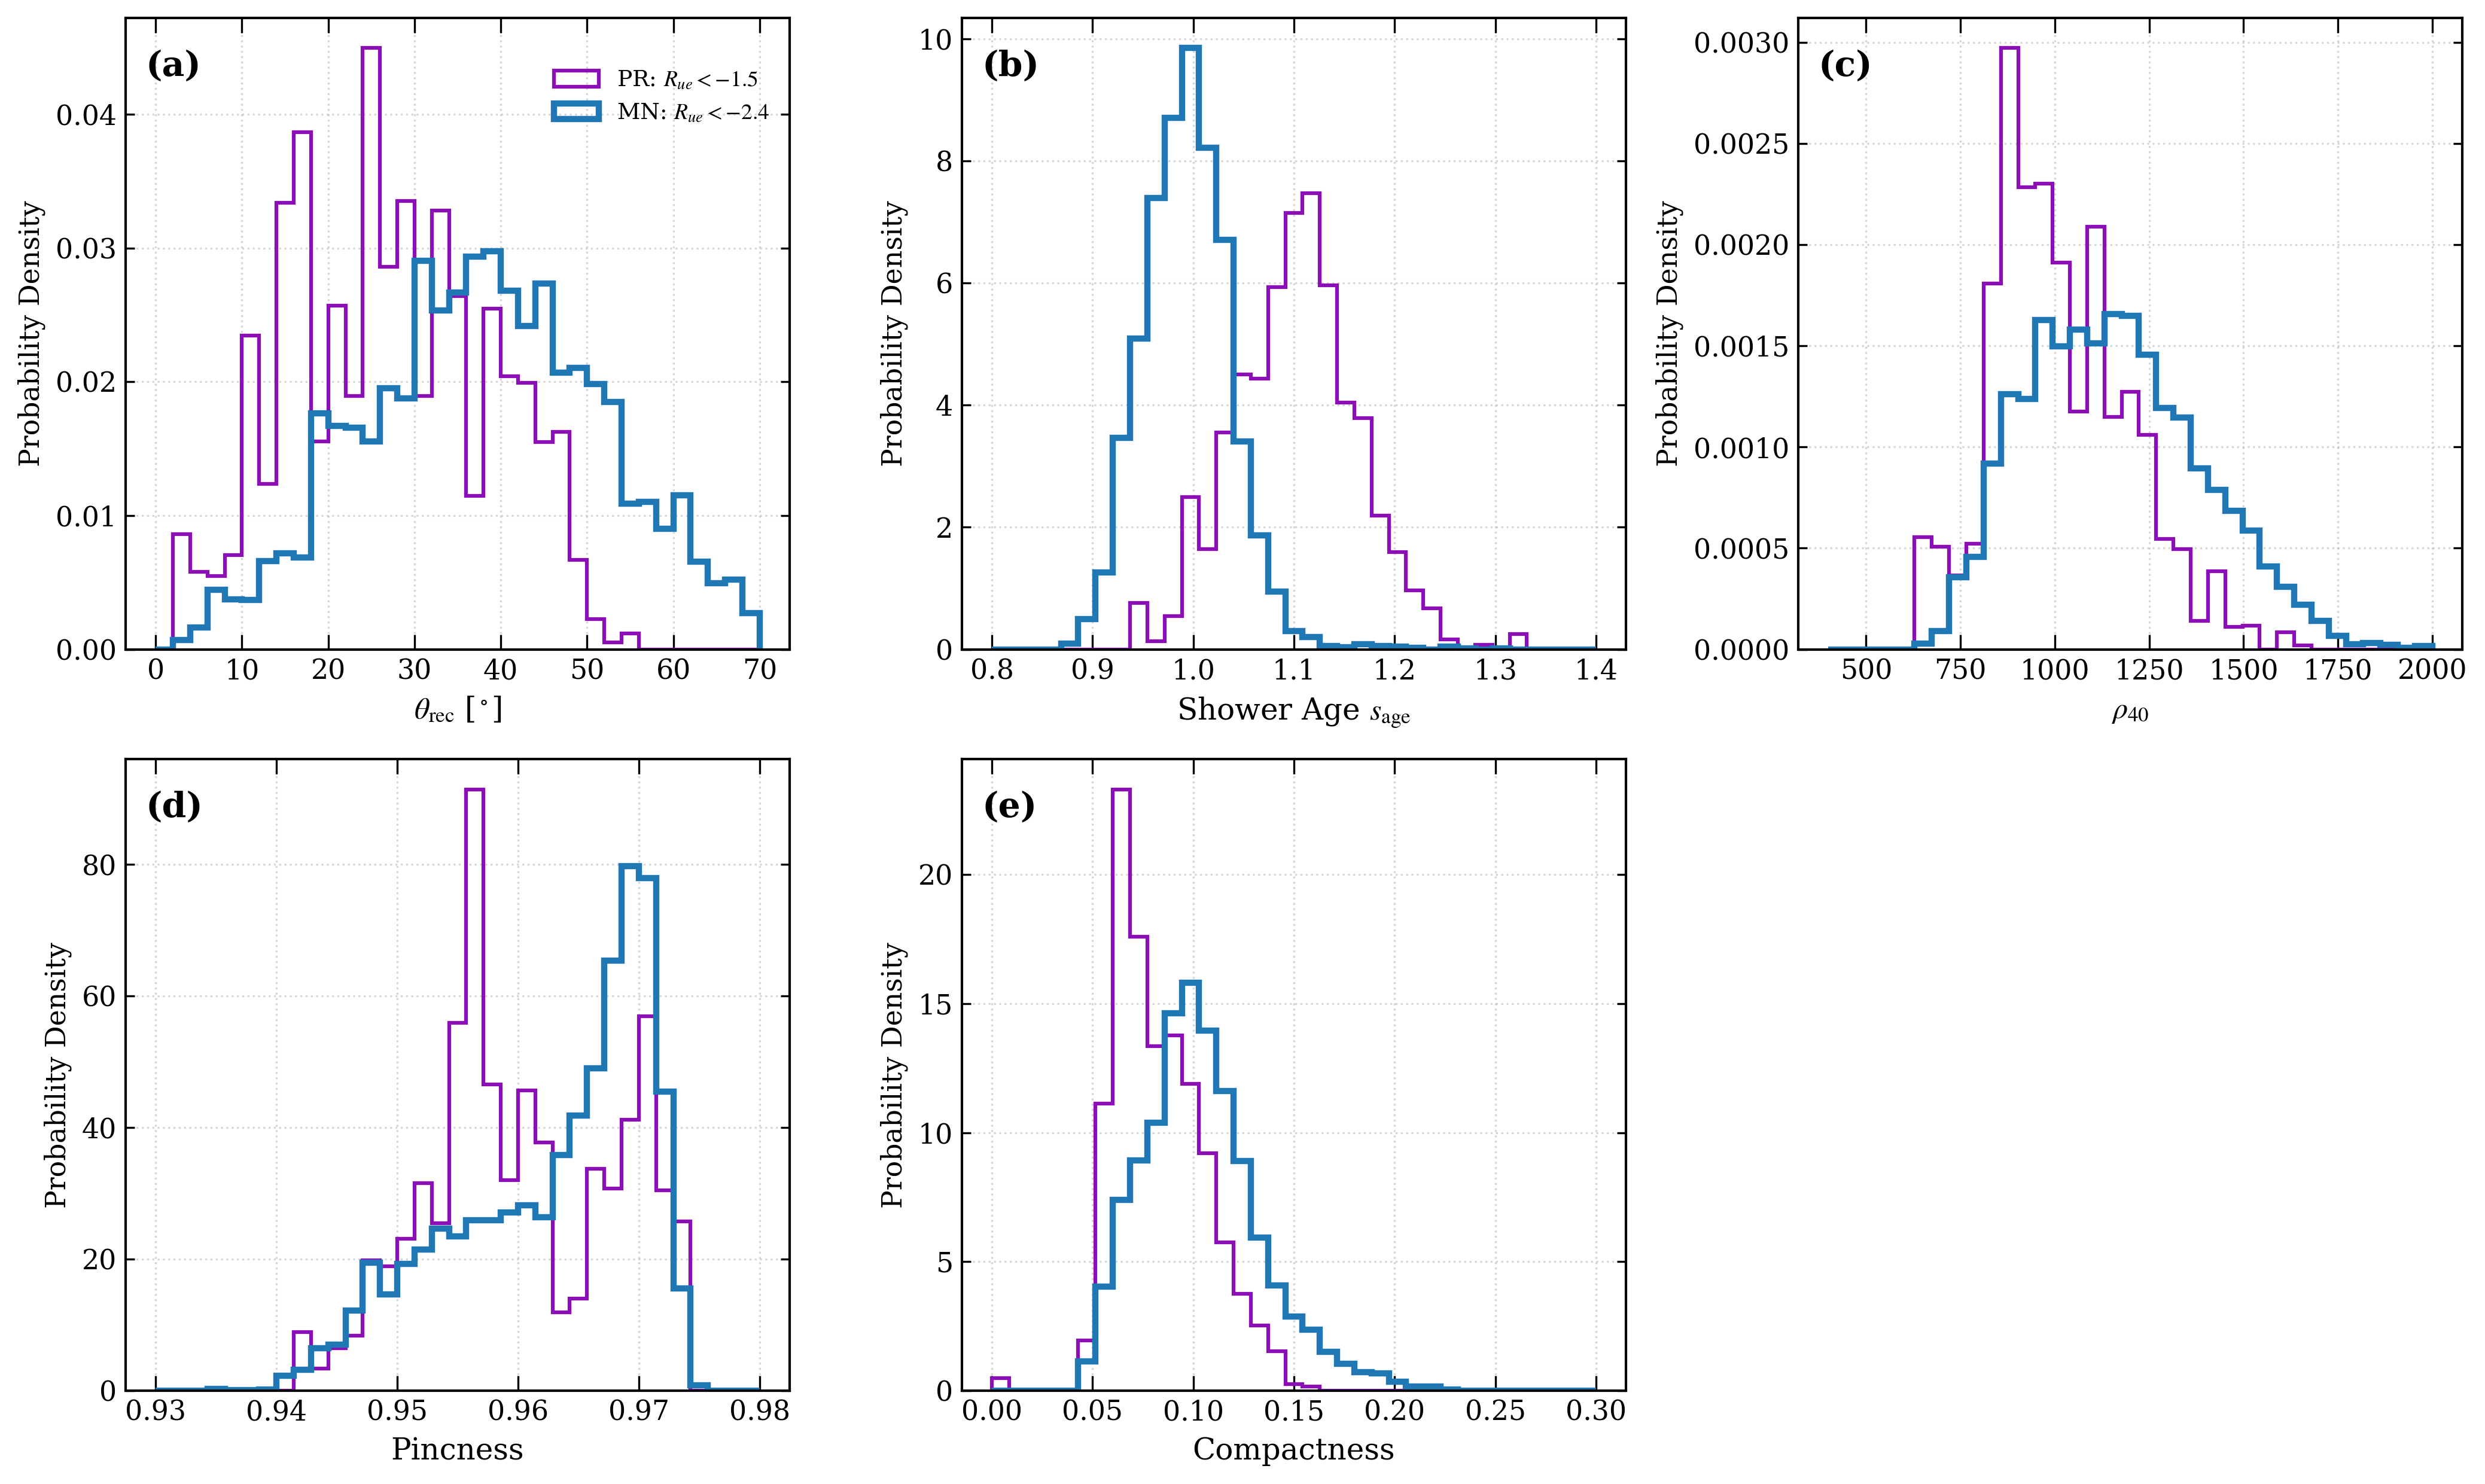

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
def generate_bin_labels(bins):
    """根据 bins 列表自动生成数学表达式标签"""
    labels = []
    for i in range(len(bins) - 1):
        low, high = bins[i], bins[i+1]
        if low == -np.inf and high == np.inf:
            labels.append("All")
        elif low == -np.inf:
            labels.append(f'$R_{{ue}} < {high}$')
        elif high == np.inf:
            labels.append(f'$R_{{ue}} > {low}$')
        else:
            labels.append(f'${low} < R_{{ue}} < {high}$')
    return labels


SR_Emin = 3.9
SR_Emax = 4.15
SR_Ruelimit = -2.4

def report_sr_counts(df, label):
    df = df[(df['recE'] > SR_Emin) & (df['recE'] < SR_Emax) & (df['R_ue'] < SR_Ruelimit)]
    if "gaisser_weight" in df.columns:
        weight_sr = df['gaisser_weight'].sum()
    elif "weight" in df.columns:
        weight_sr = df['weight'].sum()
    if label =="EXP":    
        print(f"{label} in SR: Total weight: {weight_sr:.2f}, One year: {weight_sr/3:.2f}")
    else:
        weight_sr = weight_sr * 365 * 86400 *3
        print(f"{label} in SR: Total weight: {weight_sr:.2f}")   

report_sr_counts(exp_muon_Rue_df_large, "EXP")     
report_sr_counts(pr_df_large, "PR")
report_sr_counts(mn_df_large, "MN")


    




def plot_rue_slices(df_pr, df_exp, df_mn=None):
    # 1. 设置正式发表的学术风格
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "serif"],
        "mathtext.fontset": "stix",
        "font.size": 11,
        "axes.linewidth": 1.0,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True
    })

    # 物理参数配置
    param_configs = {
        'rec_theta': {'range': (0, 70),    'label': r'$\theta_{\mathrm{rec}}$ [$^\circ$]'},
        'Eage':      {'range': (0.8, 1.4), 'label': r'Shower Age $s_{\mathrm{age}}$'},
        'rho40':     {'range': (400, 2000),  'label': r'$\rho_{40}$'},
        'pincness':  {'range': (0.93, 0.98), 'label': 'Pincness'},
        'compactness':{'range': (0.0, 0.3), 'label': 'Compactness'},
    }

    # 2. 预处理数据 (包含 recE 筛选)
    def preprocess_df(df):
        if df is None: return None
        # 确保数据为数值型
        df['recE'] = pd.to_numeric(df['recE'], errors='coerce')
        mask_e = (df['recE'] > SR_Emin) & (df['recE'] < SR_Emax)
        # print(len(df), "->", mask_e.sum(), "after recE cut (2.7 < recE < 3.3)")
        # time=86400*365
        # if 'gaisser_weight' in df.columns:
        #     print(f"Before cut: {np.sum(df['gaisser_weight']*time)}, After cut: {np.sum(df.loc[mask_e, 'gaisser_weight']*time)} (Gaisser), ")
        # elif 'weight' in df.columns:
        #     print(f"Before cut: {np.sum(df['weight']*time)}, After cut: {np.sum(df.loc[mask_e, 'weight']*time)} (Exp or SIG), ")
        return df[mask_e].copy()

    # 核心配置 
    raw_configs = {
        'PR':  {'df': preprocess_df(df_pr), 'bins': [-np.inf, -1.5], 
                'w': 'gaisser_weight', 'style': {'histtype': 'step', 'lw': 1.5}},
        # 'Exp': {'df': preprocess_df(df_exp), 'bins': [-np.inf, SR_Ruelimit], 
        #         'w': 'weight', 'style': {'histtype': 'stepfilled', 'alpha': 0.15}},
        'MN':  {'df': preprocess_df(df_mn), 'bins': [-np.inf, SR_Ruelimit], 
                'w': 'weight', 'style': {'histtype': 'step', 'lw': 2.5}}
    }

    data_sources = {k: v for k, v in raw_configs.items() if v['df'] is not None}
    for k in data_sources:
        data_sources[k]['labels'] = generate_bin_labels(data_sources[k]['bins'])

    # 3. 布局
    n_params = len(param_configs)
    n_cols = 3
    n_rows = (n_params + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.2 * n_rows), dpi=300)
    axes_flat = axes.flatten()

    # 4. 绘图循环
    for i, (p_name, p_cfg) in enumerate(param_configs.items()):
        ax = axes_flat[i]
        
        for src_name, s in data_sources.items():
            df_slice = s['df']
            # 使用 pd.cut 确保筛选逻辑正确
            categories = pd.cut(df_slice['R_ue'], bins=s['bins'], labels=False)
            
            for j, bin_label in enumerate(s['labels']):
                mask = (categories == j)
                if not np.any(mask): continue
                
                # 配色逻辑
                if src_name == 'MN': 
                    c = '#1f77b4'  # 信号蓝
                elif src_name == 'Exp': 
                    c = '#d62728'  # 实验红（根据您代码中Exp的颜色）
                else: 
                    pr_colors = ["#8C0EB6", '#FF7F0E'] # 背景颜色
                    c = pr_colors[j % len(pr_colors)]

                # 计算绘图值
                plot_vals = pd.to_numeric(df_slice.loc[mask, p_name], errors='coerce').values
                # print(f"{src_name} - {bin_label}: Plotting {len(plot_vals)} entries for {p_name}")
                if p_name == 'rec_theta' and np.nanmax(plot_vals) < 7:
                    plot_vals = plot_vals * (180/np.pi)

                ax.hist(plot_vals, bins=35, density=True, range=p_cfg['range'],
                        weights=df_slice.loc[mask, s['w']].values, color=c,
                        label=f"{src_name}: {bin_label}", **s['style'])
        
        # --- 核心修改：添加 (a), (b), (c)... 标签 ---
        # transform=ax.transAxes 表示使用子图相对坐标 (0,0)左下, (1,1)右上
        ax.text(0.03, 0.95, f'({string.ascii_lowercase[i]})', 
                transform=ax.transAxes, fontsize=14, fontweight='bold', va='top')

        if i == 0: 
            ax.legend(fontsize=9, frameon=False, loc='upper right', bbox_to_anchor=(1.0, 0.95))
        
        # 子图美化
        ax.set_xlabel(p_cfg['label'], fontsize=12)
        ax.set_ylabel("Probability Density", fontsize=11)
        ax.grid(True, ls=':', alpha=0.5)

    # 5. 隐藏多余子图
    for j in range(i + 1, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e12_Variables_For_Classification_compare.pdf", 
                bbox_inches='tight', dpi=300)
    plt.show()

# 执行绘图
plot_rue_slices(pr_df_large, exp_muon_Rue_df_large,  mn_df_large)


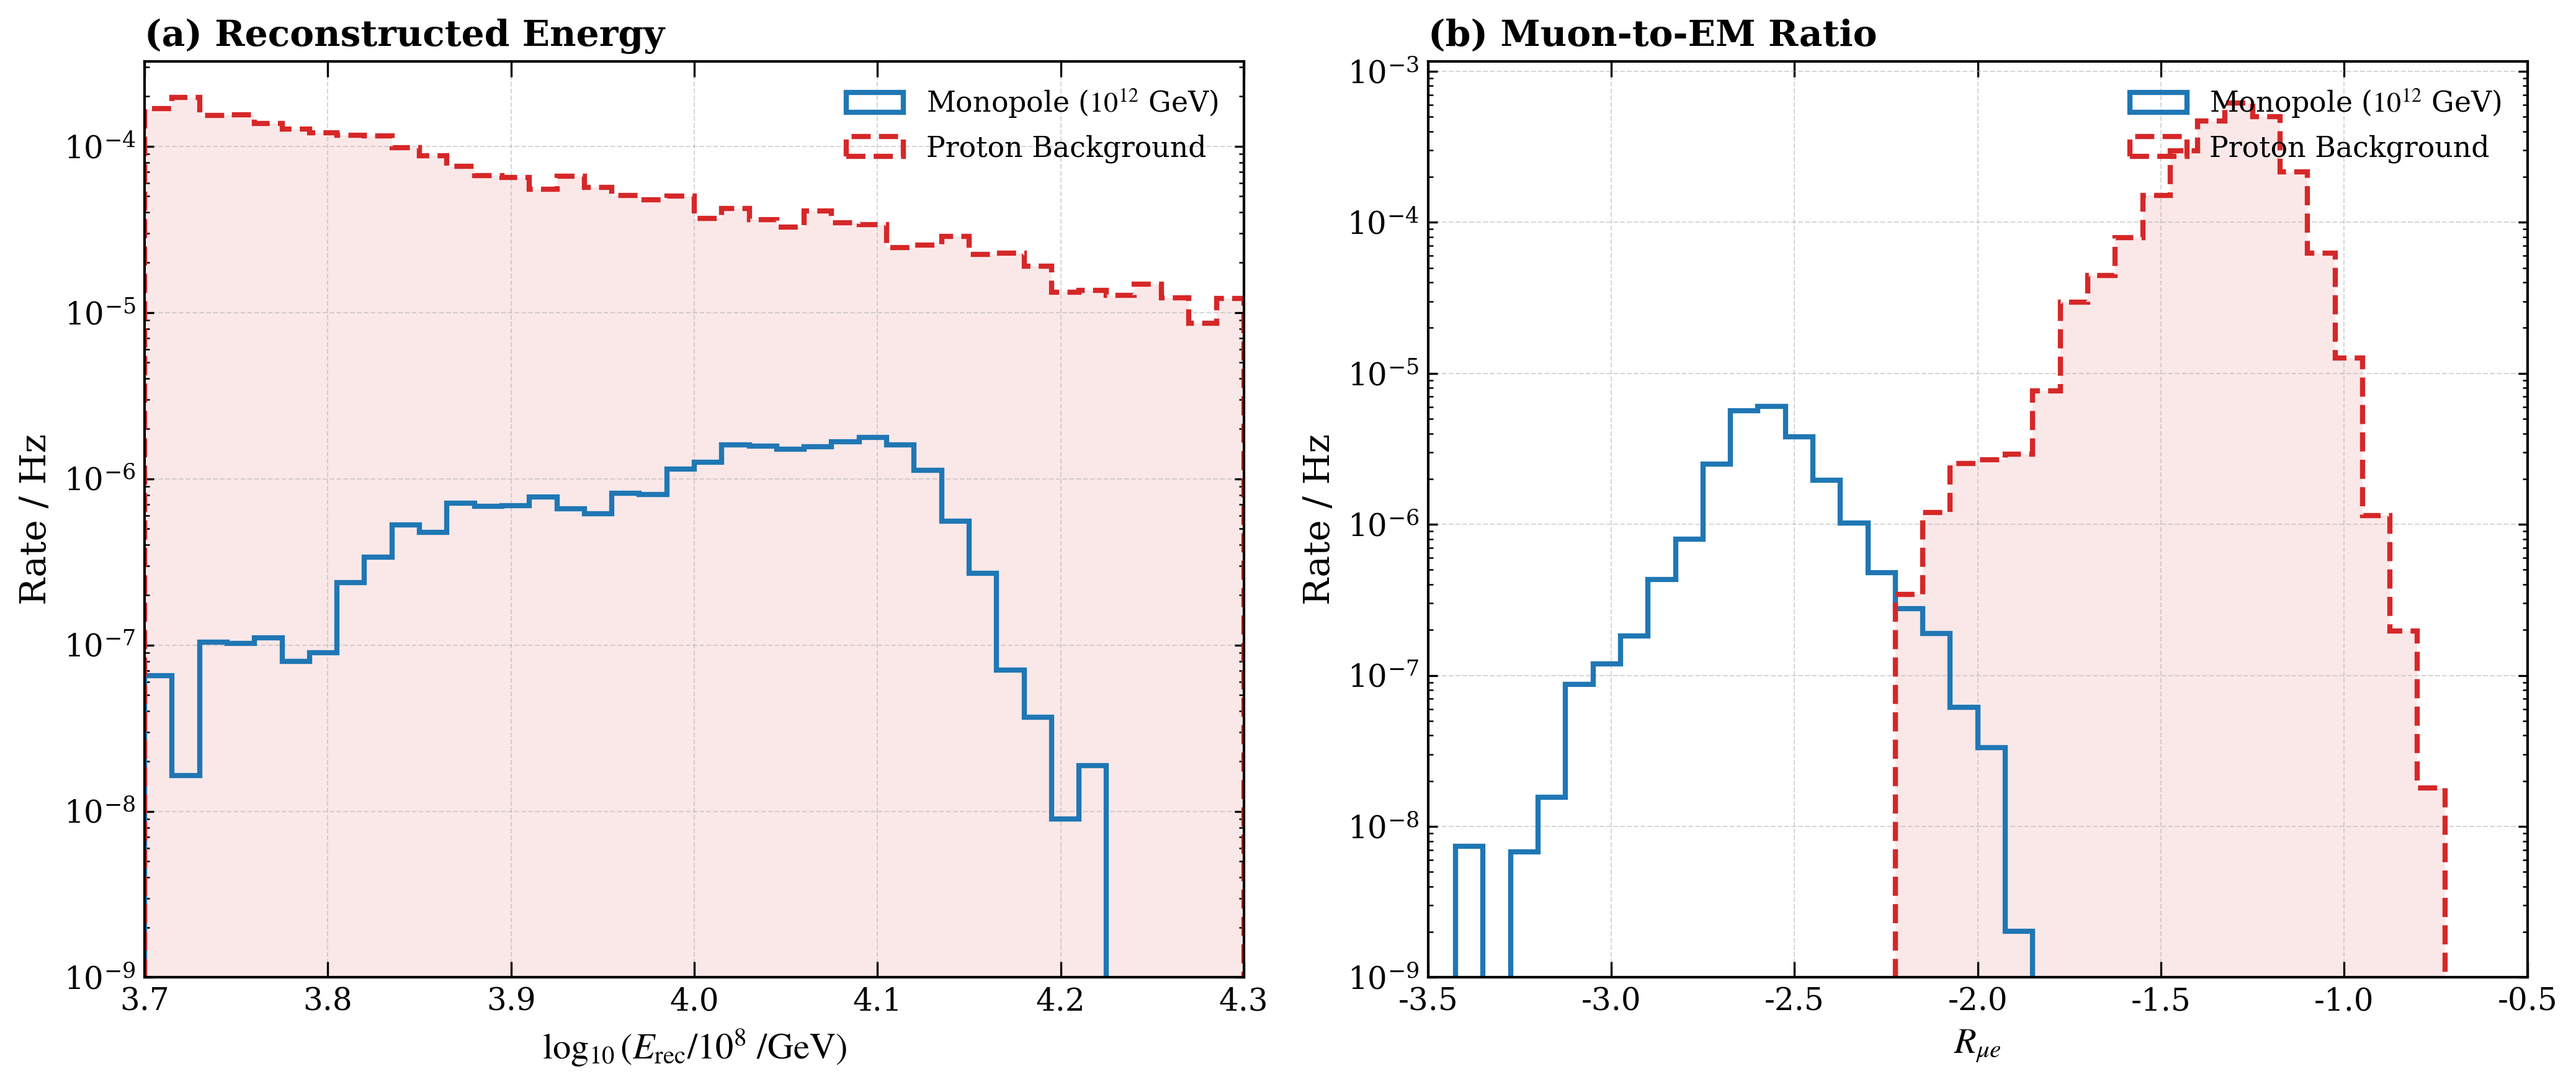

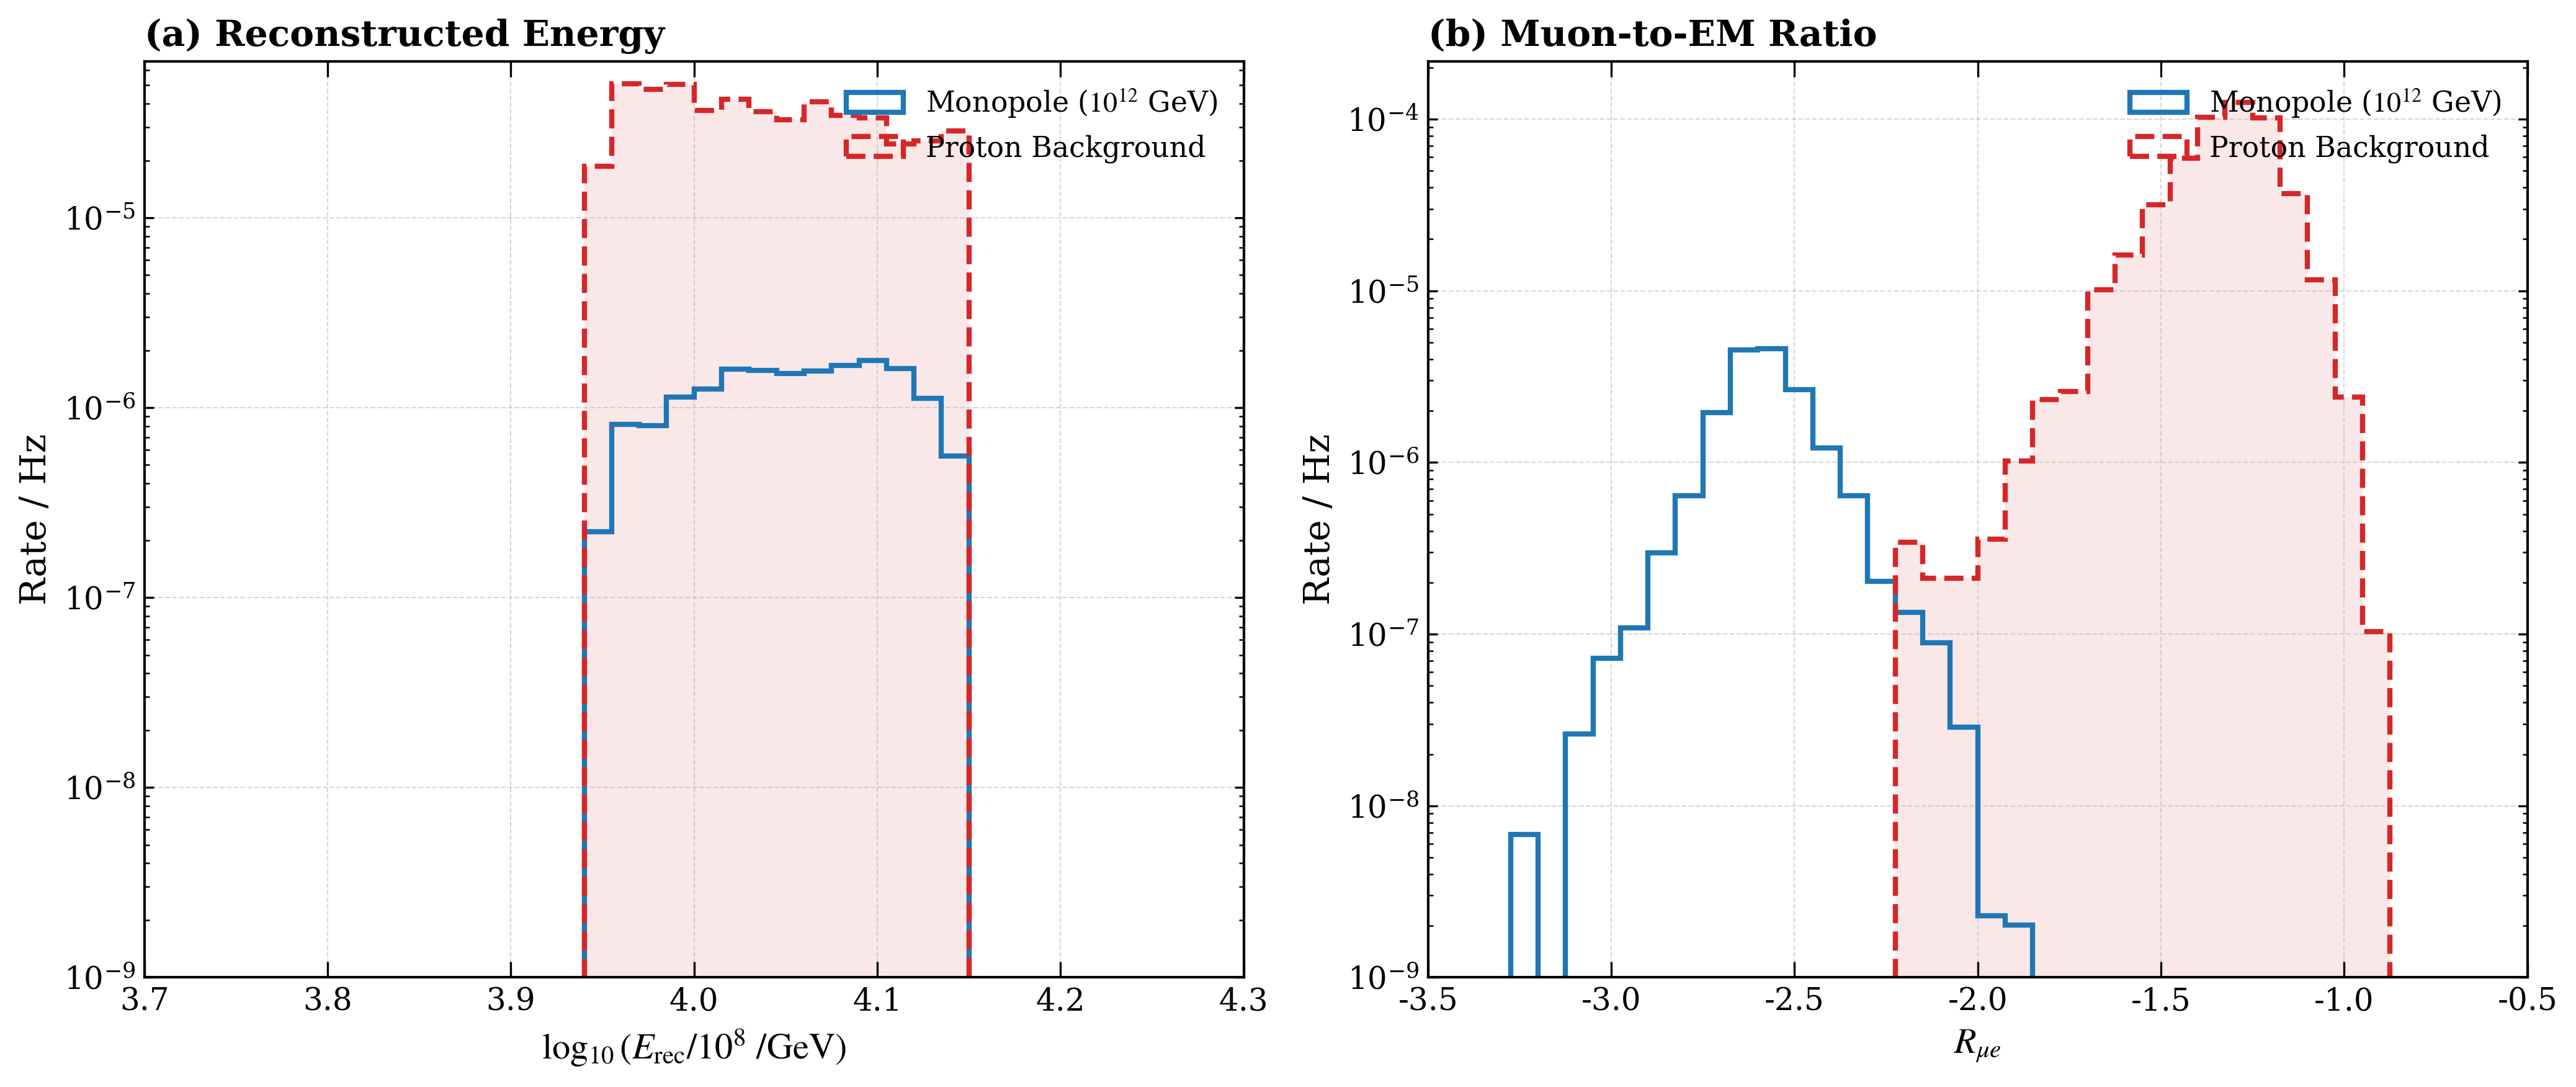

EXP in SR: Total weight: 1.00, One year: 0.33
MN in SR: Total weight: 1408.38

=== Using weight column: gaisser_weight ===
Learned shift for EF in R_ue: 0.009 (Other mean: -1.269, Base mean: -1.278)
Learned shift for QF in R_ue: -0.012 (Other mean: -1.290, Base mean: -1.278)
Using weight column: gaisser_weight, Num =[0.54585596 1.02291501 2.01311699]
Mean Rate: 1.1940;
Max Rate: mean * (1+ 0.6861);
Min Rate: mean * (1- 0.5428);

=== Using weight column: horandel_weight ===
Learned shift for EF in R_ue: 0.006 (Other mean: -1.279, Base mean: -1.285)
Learned shift for QF in R_ue: -0.018 (Other mean: -1.303, Base mean: -1.285)
Using weight column: horandel_weight, Num =[0.11337439 0.26351864 0.55075427]
Mean Rate: 0.3092;
Max Rate: mean * (1+ 0.7811);
Min Rate: mean * (1- 0.6333);

Mean Spec: 0.7516; Max Spec: mean * (1 + 0.5886); Max Spec: mean * (1 - 0.5886;
[1.98993776 0.51535962], Mean5eyar=1.2526


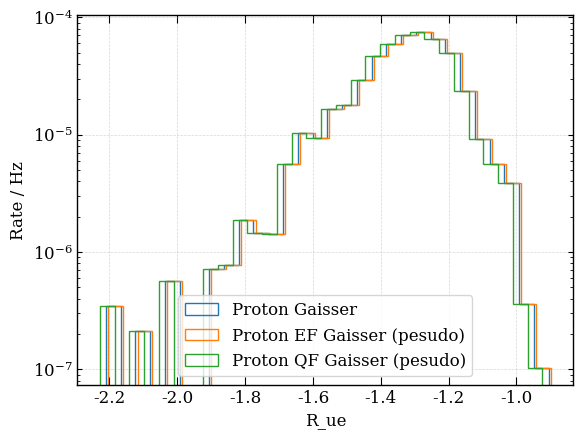

In [99]:

proton_df_QF['gaisser_weight'] = proton_df_QF['weightGaisser']
proton_df_QF['horandel_weight'] = proton_df_QF['weightHorandol']
proton_QF_shift = learn_shift(pr_df, proton_df_QF, 'R_ue',  label="QF")


# plt.hist(proton_df_QF['R_ue'], )

Learned shift for QF in R_ue: -0.002 (Other mean: -1.280, Base mean: -1.278)


Plotting Data Evolution...
Saving figure to /data/home/zzh/Filt_Event/Note_Writing/figures/1e12_data_Rue_Stability_Eage.pdf ...


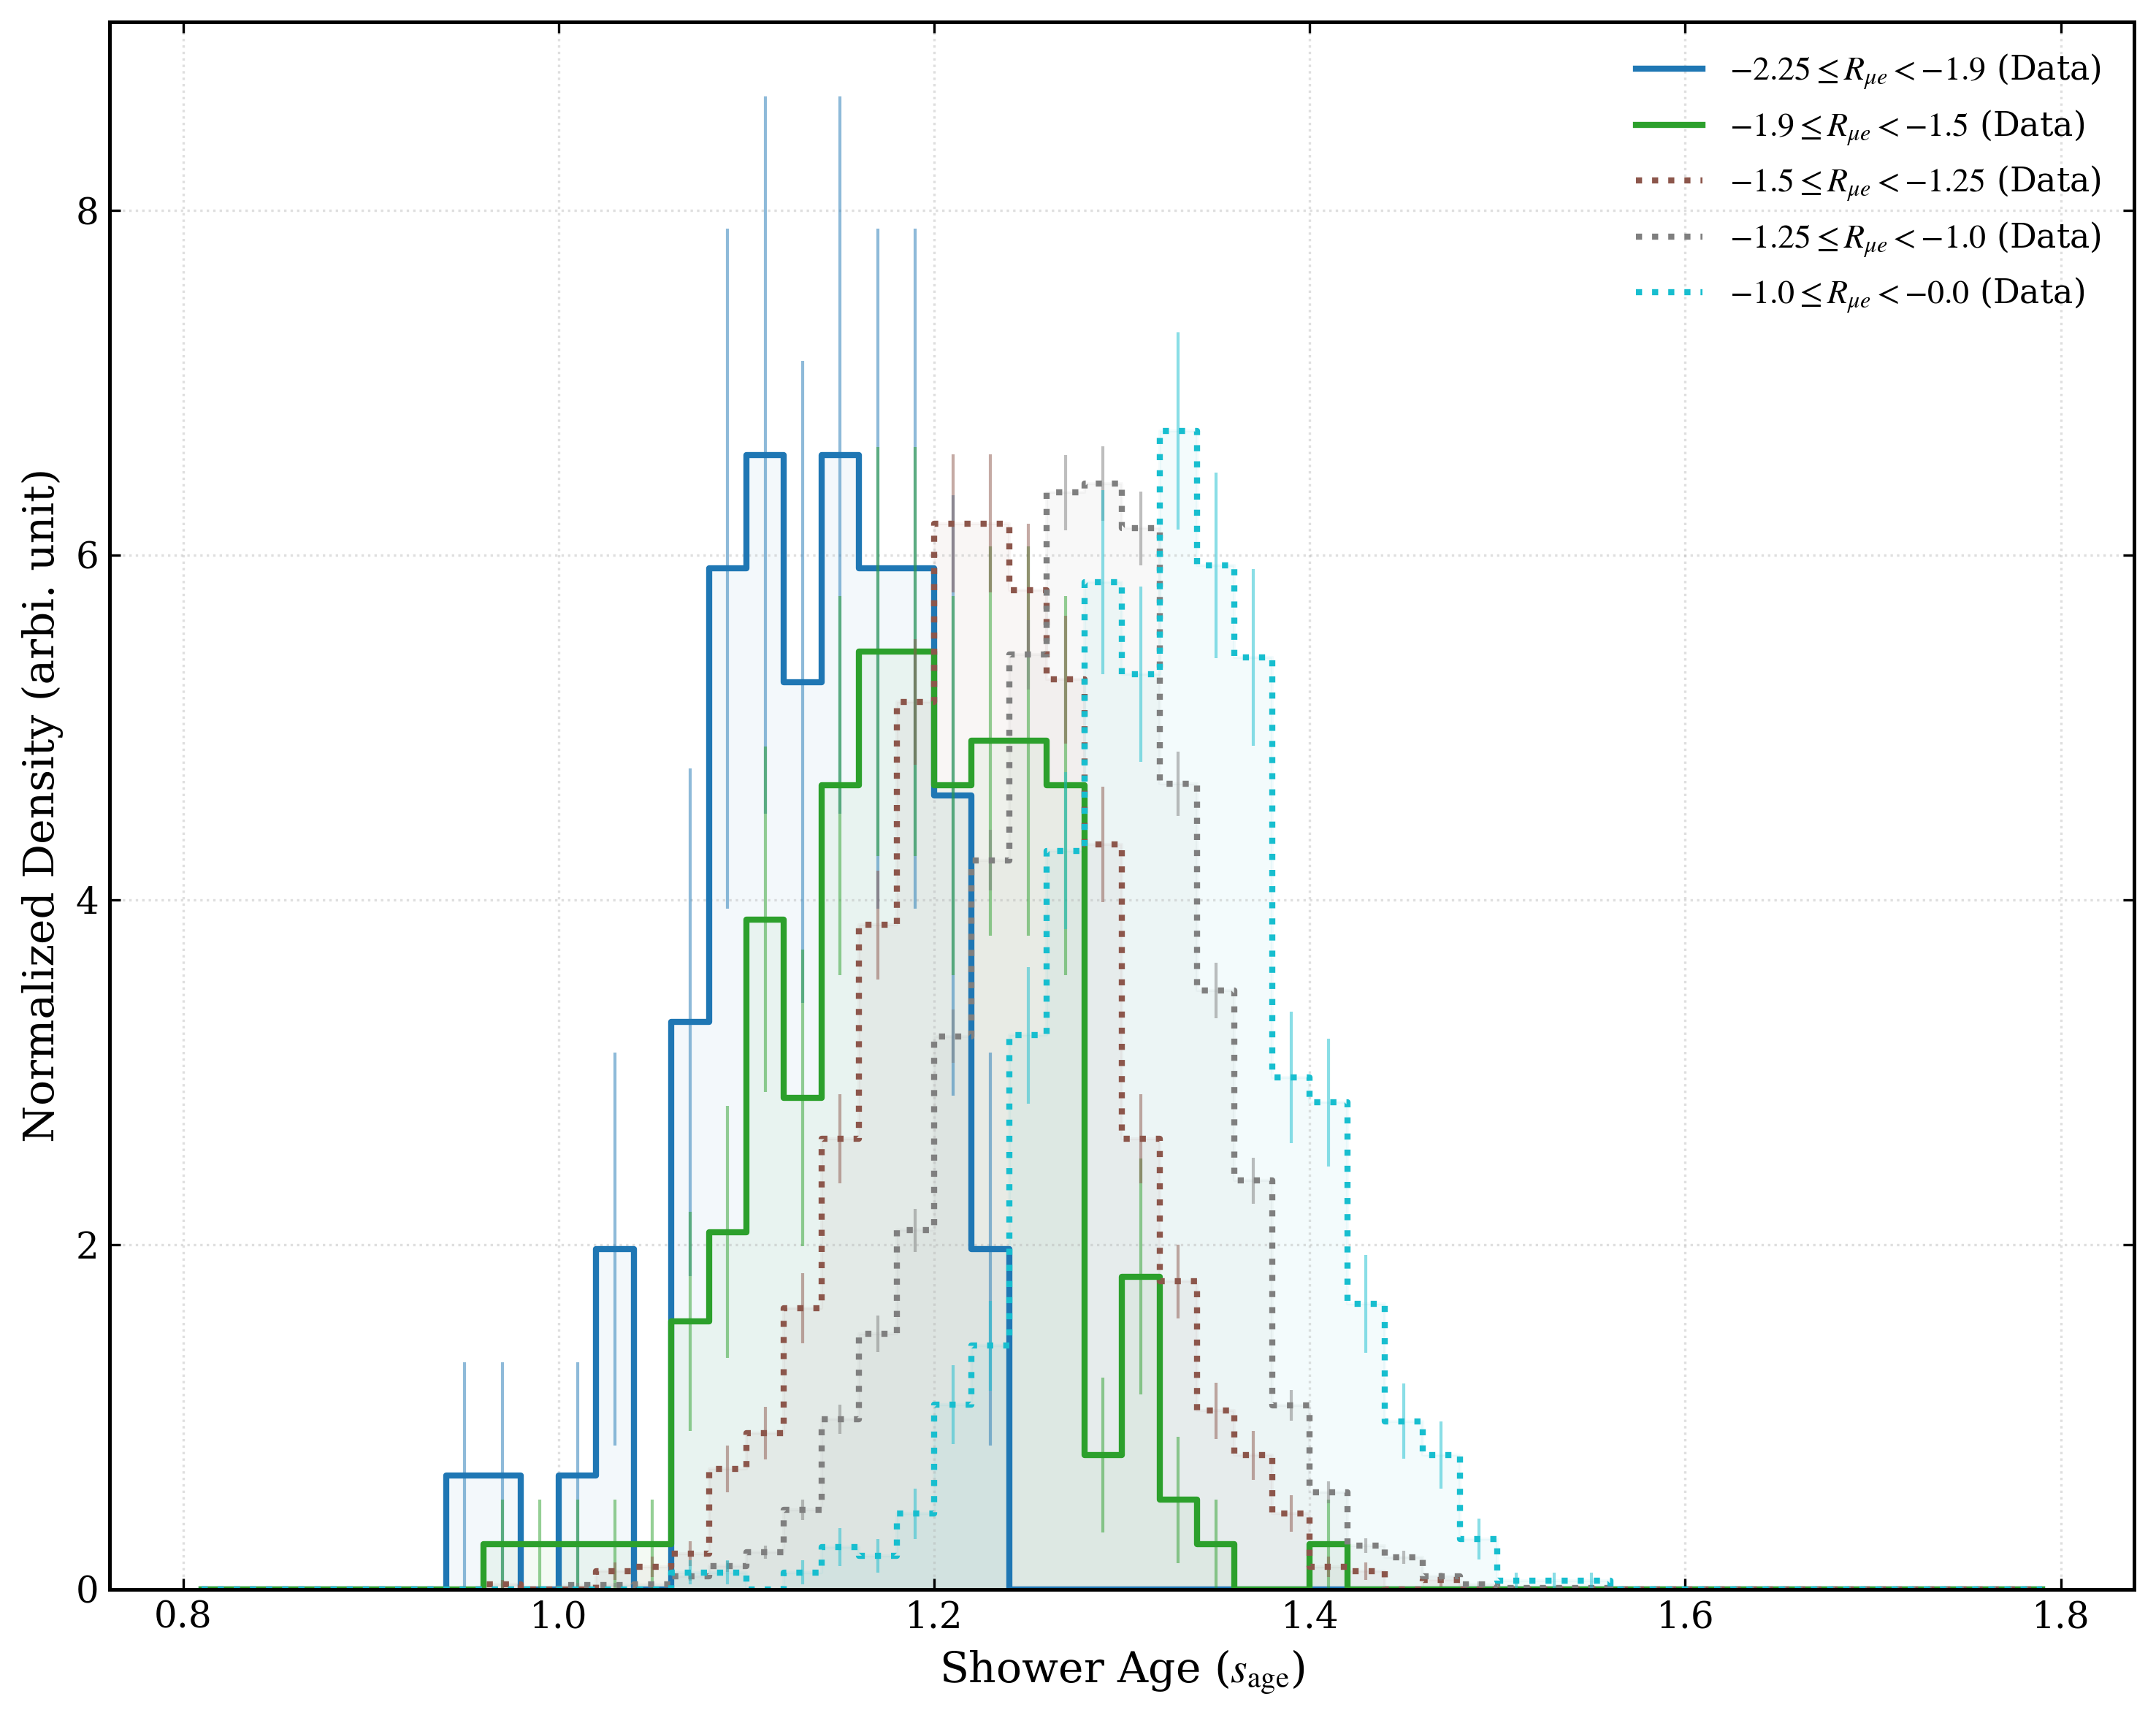

In [155]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


one_day_file = "/data/home/zzh/data/Dataset_Filted/Experiment/1e12_V04/Exp_1e12_V04_muon_dataset_fastcode.npz"
one_day_data = np.load(one_day_file, allow_pickle=True)
one_day_df = pd.DataFrame(one_day_data['params'], columns=one_day_data['param_names'][:32])
for col in one_day_df.columns:
    one_day_df[col] = pd.to_numeric(one_day_df[col], errors='coerce')
one_day_df['log_NuW3'] = np.log10(pd.to_numeric(one_day_df['NuW3'], errors='coerce'))
one_day_df['recE'] = agent.predict(one_day_df[['log_NuW3', 'rec_theta']].values)
one_day_df = one_day_df[(one_day_df['recE'] > 3.7) & (one_day_df['recE'] < 4.3) & (one_day_df['rec_theta'] > 0) & (one_day_df['rec_theta'] <= 70/180*np.pi)
                        & (one_day_df['dr'] > 0) & (one_day_df['Eage'] > 0.8) & (one_day_df['Eage'] < 2.4)]
one_day_df['R_ue2'] =np.log10((one_day_df['NuM1']+1e4)/one_day_df['NpE2'])

def plot_data_evolution_density(df_year, df_day, bins_config, var='Eage', figsize=(10, 8), filepath=None):
    # --- 1. 学术风格设置 (保持不变) ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 12,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "axes.linewidth": 1.2,
        "xtick.top": True,
        "ytick.right": True
    })

    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    # colors = plt.cm.magma(np.linspace(0, 0.9, len(bins_config)))
    colors = plt.cm.tab10(np.linspace(0, 1, len(bins_config)))
    # r'$\rho_{40}$ [m$^{-2}$]'
    var_info = {
        'Eage':  {'label': r'Shower Age ($s_{\mathrm{age}}$)', 'range': (0.8, 1.8), 'bins': 50},
        'pincness': {'label': 'Pincness', 'range': (0.92, 0.98), 'bins': 50},
        'rho40': {'label': r'$\rho_{40}$ [m$^{-2}$]', 'range': (600, 2000), 'bins': 50},
        'rec_theta': {'label': r'$\theta_{\mathrm{rec}}$ [rad]', 'range': np.deg2rad((0, 70)), 'bins': 50},
    }
    cfg = var_info.get(var, {'label': var, 'range': None, 'bins': 50})

    for i, (r_low, r_high) in enumerate(bins_config):
        # --- 数据源选择 ---
        if r_high <= -1.9:
            source_label, df_source, linestyle = "Data", df_year, '-'
        elif r_high > -1.9 and r_high <= -1.5:
            source_label, df_source, linestyle = "Data", df_day, '-'
        else:
            source_label, df_source, linestyle = "Data", df_day, ':'
            
        # --- 2. 关键修复：强制转换数据类型 ---
        mask = (df_source['R_ue'] >= r_low) & (df_source['R_ue'] < r_high)
        
        # 使用 pd.to_numeric 过滤掉潜在的非数字并强制转为 float64
        selected_series = pd.to_numeric(df_source.loc[mask, var], errors='coerce').dropna()
        slice_data = selected_series.values.astype(float)
        
     
        
        N_events = len(slice_data)
        if N_events == 0: continue

        # --- 3. 计算直方图 ---
        hist, bin_edges = np.histogram(slice_data, bins=cfg['bins'], range=cfg['range'], density=True)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        
        # --- 4. 再次强制转换绘图数组类型 (防御性编程) ---
        hist = hist.astype(float)
        bin_centers = bin_centers.astype(float)

        raw_counts, _ = np.histogram(slice_data, bins=cfg['bins'], range=cfg['range'])
        valid_mask = raw_counts > 0
        yerr = np.zeros_like(hist)
        yerr[valid_mask] = hist[valid_mask] * (1.0 / np.sqrt(raw_counts[valid_mask]))

        # --- 5. 绘图 ---$N={N_events}$
        label_text = rf"${r_low} \leq R_{{\mu e}} < {r_high}$ ({source_label}) "
        
        ax.step(bin_centers, hist, where='mid', color=colors[i], linestyle=linestyle, linewidth=2, label=label_text)
        ax.errorbar(bin_centers[valid_mask], hist[valid_mask], yerr=yerr[valid_mask], 
                    fmt='none', ecolor=colors[i], elinewidth=1, capsize=0, alpha=0.5)
        
        # 这里之前报错，现在 hist 和 bin_centers 已经是纯粹的 float64 数组了
        ax.fill_between(bin_centers, hist, step='mid', color=colors[i], alpha=0.05)

    # --- 装饰 ---
    ax.set_xlabel(cfg['label'], fontsize=14)
    ax.set_ylabel("Normalized Density (arbi. unit)", fontsize=14)
    ax.legend(loc='best', frameon=False, fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    if filepath is not None:
        print(f"Saving figure to {filepath} ...")
        plt.savefig(filepath, bbox_inches='tight', pad_inches=0.1)
    plt.show()
print("Plotting Data Evolution...")
bins_to_compare = [
    # (-3.0, -2.75),  # 极低 Muon 区 (Signal-like / Light), 使用 Year Data
    # (-2.75, -2.5),  # 极低 Muon 区 (Signal-like / Light), 使用 Year Data
    # (-2.5, -2.25),  # 过渡区/背景区, 使用 Day Data
    (-2.25, -1.9),  # 过渡区/背景区, 使用 Day Data
    (-1.9, -1.5), 
    (-1.5, -1.25),  # 如果需要，可以加更重的背景区
    (-1.25, -1.0),  # 如果需要，可以加更重的背景区
    (-1.0, -0.),
    # (-0.75, -0.5),
    # (-0.5, -0),  # 如果需要，可以加更重的背景区
]
plot_data_evolution_density(exp_muon_Rue_df, one_day_df, bins_to_compare, var='Eage', filepath="/data/home/zzh/Filt_Event/Note_Writing/figures/1e12_data_Rue_Stability_Eage.pdf")
# plot_data_evolution_density(exp_muon_Rue_df, one_day_df, bins_to_compare, var='pincness')
# plot_data_evolution_density(exp_muon_Rue_df, one_day_df, bins_to_compare, var='compactness')
# plot_data_evolution_density(exp_muon_Rue_df, one_day_df, bins_to_compare, var='rho40')
# plot_data_evolution_density(exp_muon_Rue_df, one_day_df, bins_to_compare, var='rec_theta')


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

def event_plot_npz(index, hitsE_all, hitsM_all, df_params, flag=7, figpath=None):
    
    
    # 配置学术字体
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["mathtext.fontset"] = "stix"
    
        
        
    def load_pos(flag:int):
        ED_pos_file = None
        MD_pos_file = None
        script_dir = "/data/home/zzh/Filt_Event"
        if flag==7:
            ED_pos_file=f'{script_dir}/config/ED_pos_all.txt'
            MD_pos_file=f'{script_dir}/config/MD_pos_all.txt'
        else:
            MD_pos_file=f'{script_dir}/config/MD_pos_1188.txt'
            if 20191224 < flag < 20201201:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_half.txt'
            elif 20201130 < flag < 20210720:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_3978.txt'
            elif 20210719 < flag < 20210807:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5216up_20210720.txt'
            elif 20210806 < flag < 20220526:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5216up_20210807.txt'
            elif 20220525 < flag < 20220601:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5216up_20220520.txt'
            elif 20220531 < flag < 20220705:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5216up_20220601.txt'
            elif 20220704 < flag < 20221118:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5216up_20220705.txt'
            elif 20221117 < flag < 20230504:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5217up_20221118.txt'
            elif 20230503 < flag < 20230619:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5217up_20230504.txt'
            elif 20230618 < flag < 20230913:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5217up_20230619.txt'
            elif 20230912 < flag < 20231008:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5217up_20230913.txt'
            elif 20231007 < flag < 20241021:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5217up_20231008.txt'
            elif 20241020 < flag < 20250617:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5218up_20241021.txt'
            elif flag > 20250616:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5218up_20250617.txt'
            else:
                # 增加一个容错处理，防止传入的 flag 刚好落在边界或非法范围外导致 ED_pos_file 未定义
                raise ValueError(f"输入的 flag ({flag}) 不在任何已知的坐标配置时间段内，请检查！")
        
        if ED_pos_file is not None:
            if os.path.exists(ED_pos_file) and os.path.exists(MD_pos_file):
                ED_pos=pd.read_csv(ED_pos_file,  sep=r'\s+',   skiprows=1,header=None, names=["id","x","y","z"])
                MD_pos=pd.read_csv(MD_pos_file,  sep=r'\s+',   skiprows=1,header=None, names=["id","x","y","z"])
                for col in ['x', 'y', 'z']:
                    ED_pos[col] = pd.to_numeric(ED_pos[col], errors='coerce')
                    MD_pos[col] = pd.to_numeric(MD_pos[col], errors='coerce')

                return ED_pos,MD_pos
        else:

            raise ValueError("wrong flag")
    
    
    
    # 1. 加载阵列位置
    ED_pos, MD_pos = load_pos(flag)

    # 2. 提取数据
    hE = hitsE_all[index]
    hM = hitsM_all[index]
    row = df_params.iloc[index]
    core = [row['rec_x'], row['rec_y']]
    theta, phi = row['rec_theta'], row['rec_phi']

    # 3. 计算指向箭头 (转换坐标系或方向)
    # 这里的 dx, dy 逻辑保持原样，但增加 arrow_width 的美化
    arrow_len = 220
    dx = -np.sin(theta) * np.sin(phi) * arrow_len
    dy = np.sin(theta) * np.cos(phi) * arrow_len

    # 4. 开始绘图
    # 使用 constrained_layout 替代 tight_layout，能更好地处理 colorbar 间距
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True, dpi=300)
    
    # 公用的绘图参数
    scatter_kwargs = {
        'cmap': 'magma', # 更有科研质感的渐变色
        'vmin': 0, 
        'vmax': 4,       # 固定 log10(PE) 范围，方便左右对比
        'edgecolors': 'none'
    }

    # --- 左图：ED Hits ---
    ax1.scatter(ED_pos['x'], ED_pos['y'], c='#E0E0E0', s=3, alpha=0.5, label='Array', zorder=1)
    sc1 = ax1.scatter(hE[:, 0], hE[:, 1], c=np.log10(hE[:, 3] + 1), 
                      s=3, zorder=3, **scatter_kwargs)
    
    # 核心位置与箭头
    ax1.scatter(core[0], core[1], c='#00FF00', s=40, marker='x', label='Reconstructed Core', zorder=10, alpha=0.5)
    ax1.arrow(core[0], core[1], dx, dy, color='#00FF00', width=5, head_width=15, alpha=0.5 ,
              length_includes_head=True, zorder=11)
    
    ax1.set_title('(a) ED Array Response', fontsize=14, loc='left', fontweight='bold')

    # --- 右图：MD Hits ---
    ax2.scatter(MD_pos['x'], MD_pos['y'], c='#E0E0E0', s=10, alpha=0.5, zorder=1)
    sc2 = ax2.scatter(hM[:, 0], hM[:, 1], c=np.log10(hM[:, 3] + 1), 
                      s=10, zorder=3, **scatter_kwargs)
    
    ax2.scatter(core[0], core[1], c='#00FF00', s=80, marker='x', zorder=10)
    
    ax2.set_title('(b) MD Array Response', fontsize=14, loc='left', fontweight='bold')

    # 设置统一的 Colorbar
    cbar = fig.colorbar(sc2, ax=[ax1, ax2], location='right', aspect=30, shrink=0.8)
    cbar.set_label(r'$\log_{10}(\text{PE} + 1)$', fontsize=12)

    # 坐标轴细节优化
    for i, ax in enumerate([ax1, ax2]):
        ax.set_aspect('equal')
        ax.set_xlabel('$x$ [m]', fontsize=12)
        ax.set_ylabel('$y$ [m]', fontsize=12)
        ax.set_xlim(-650, 650)
        ax.set_ylim(-650, 650)
        ax.tick_params(direction='in', top=True, right=True)
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
        if i == 0: ax.legend(loc='lower left', fontsize=9, framealpha=0.8)
    for ax in [ax1, ax2]:
        ax.set_xticks([]) # 取消 x 轴刻度和数字
        ax.set_yticks([])
    # 如果需要保存
    if figpath:
        plt.savefig(figpath, bbox_inches='tight', dpi=300)
    plt.show()

# 调用
# event_plot_npz_formal(0, hitsE, hitsM, mn_df, flag=7, figpath="event_display.pdf")
mn_file="/data/home/zzh/data/Dataset_Filted/CosmicRay/1e12_V04/filted_QF_Proton_2.5e15_5.0e17_dataset_fastcode.npz"
mn_data = np.load(mn_file, allow_pickle=True)
hitsE = mn_data['hitsE']; hitsM = mn_data['hitsM']; mn_df = pd.DataFrame(mn_data['params'], columns=mn_data['param_names'][:32])





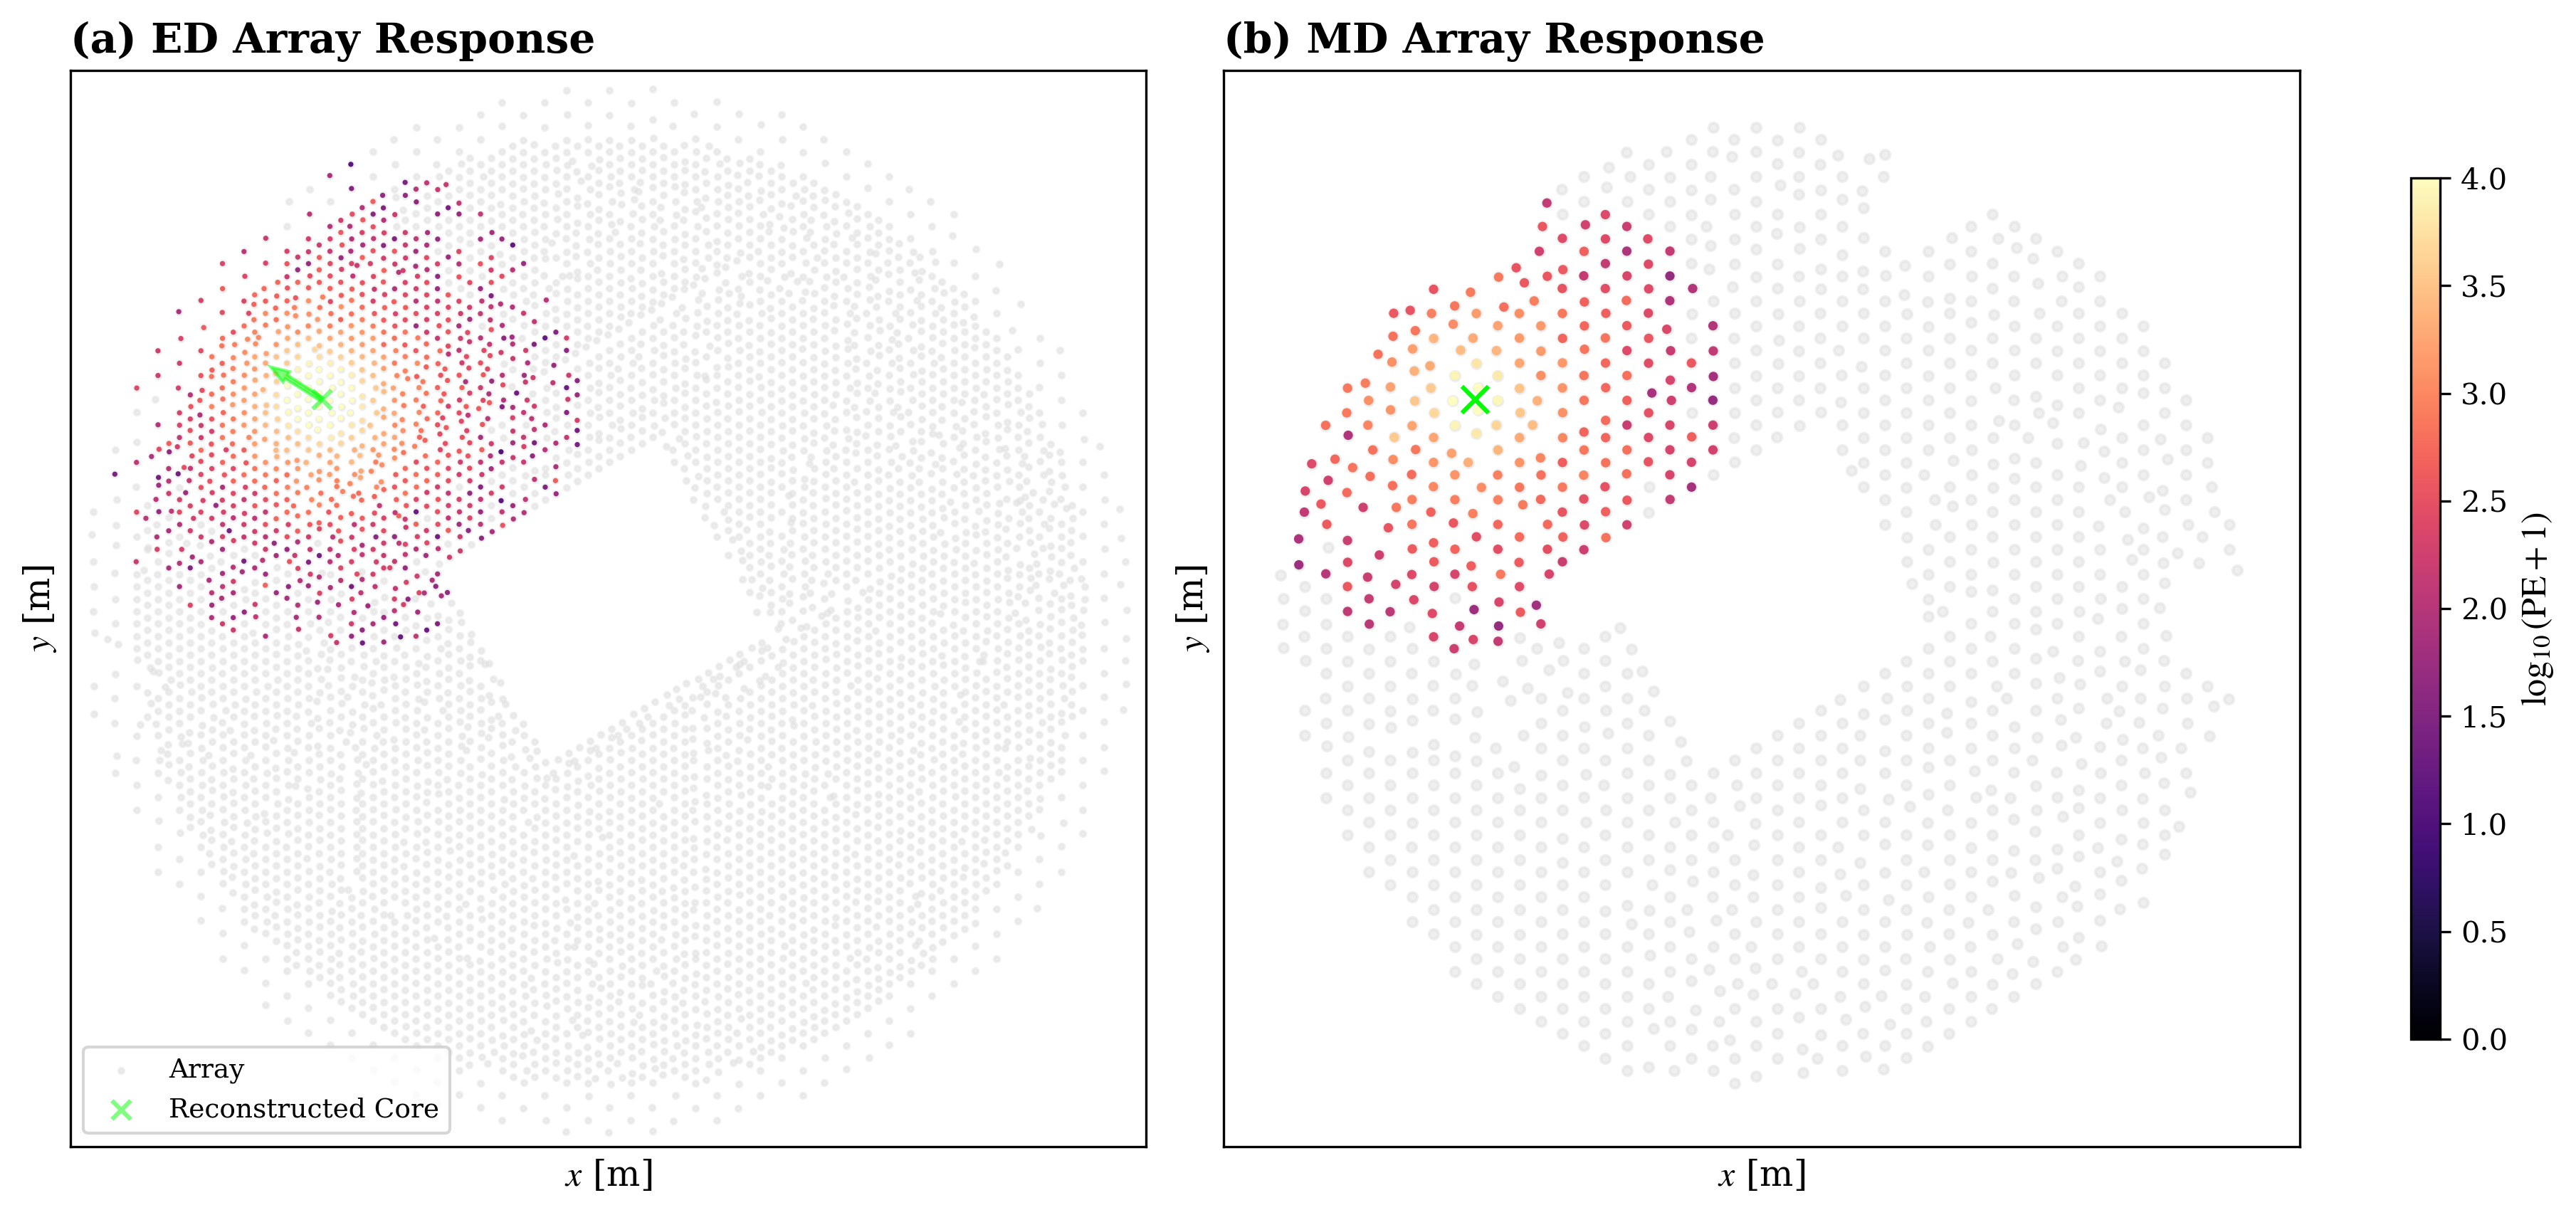

In [20]:
event_plot_npz(1, hitsE, hitsM, mn_df, flag=20210818)


Number of events with theta > 66°: 0
Number of events with core radius > 650 m: 0


6259